In [1]:
%load_ext autoreload
%autoreload 2

# import packages
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from datetime import datetime as dt
from glob import glob
from tqdm import tqdm
import matplotlib.patches as mpatches
import os

# import partial packages
from sklearn.cluster import KMeans, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy.stats import gaussian_kde

# from hdbscan import HDBSCAN
from functools import reduce
# from hdbscan.validity import validity_index

import pickle


directory = '/scratch/6256481/'
hDirectory = '/home/6256481/River_Morphology/'
import sys
sys.path.insert(0, directory + f'python/py_code/')

from clustering_confinement import open_dataset_confinement_clustering
# from clustering import KmeansTune, GMM_tune, print_pca_loadings,\
#                         data_prep_clustering, applyGMM, applyKmeans

from clustering import print_pca_loadings,\
                        data_prep_clustering, applyGMM, applyKmeans
from calc_functions import scale




# Goal
- Kmeans
- DBSCAN
- HBBSCAN
- OPTICS

# Plot settings

In [2]:
labelSize = 20
tickSize  = 15
legendTitleSize = 12
legendEntrySize = 12

# colors
colorOut = '#d62728'
colorInn = '#1F60B4'


# Check Tuning results

In [3]:
KmeanScoreFiles = glob(directory + 'results/KmeanScores_c*merged*')
KmeanScoreFiles = glob(directory + 'results/KmeanScores_c*_0*')
for i,f in enumerate(KmeanScoreFiles):
    dfT = pd.read_csv(f, index_col=0)
    chScore = f[-6:-4]
    dfT = dfT.rename(columns = {'Silhouette':f'Silhouette_{chScore}',
                      'DaviesB'   :f'DaviesB_{chScore}'}   )
    if i == 0:
        dfKS = dfT

    else:
        dfKS = dfKS.merge(dfT, how = 'left', on = 'clusters')

In [7]:
GMMScoreFiles   = glob(directory + 'results/GMMSCORES_conf*merg*')

GMMScoreFiles   = np.sort(glob(directory + 'results/GMMSCORES_conf*_0*'))
GMMScoreFiles

array(['/scratch/6256481/results/GMMSCORES_confinement_02.csv',
       '/scratch/6256481/results/GMMSCORES_confinement_03.csv',
       '/scratch/6256481/results/GMMSCORES_confinement_04.csv'],
      dtype='<U53')

In [8]:
GMMScoreFiles   = np.sort(glob(directory + 'results/GMMSCORES_conf*_0*'))
# GMMScoreFiles   = glob(directory + 'results/GMMSCORES_conf*merg*')
for i,f in enumerate(GMMScoreFiles[0:1]):
    dfT = pd.read_csv(f, index_col=0)
    chScore = f[-6:-4]
    dfT = dfT.rename(columns = {'BIC':f'BIC_{chScore}',
                                'AIC':f'AIC_{chScore}',
                                'Silhouette':f'Silhouette_{chScore}',
                                'DaviesB':f'DaviesB_{chScore}' }  )
    if i == 0:
        # 
        dfGS = dfT

    else:

        dfT = dfT.drop(['max_iter', 'init'], axis = 1)
        dfGS = dfGS.merge(dfT, how = 'inner', on = ['cov_type','clusters'])
dfGS.head(2)

,max_iter,cov_type,init,init_p,clusters,BIC_02,AIC_02,Silhouette_02,DaviesB_02
0,200,tied,5,k-means++,3,1.539995e+07,1.539974e+07,0.487408,1.208641
1,200,tied,5,k-means++,4,1.540001e+07,1.539975e+07,0.545140,1.079445


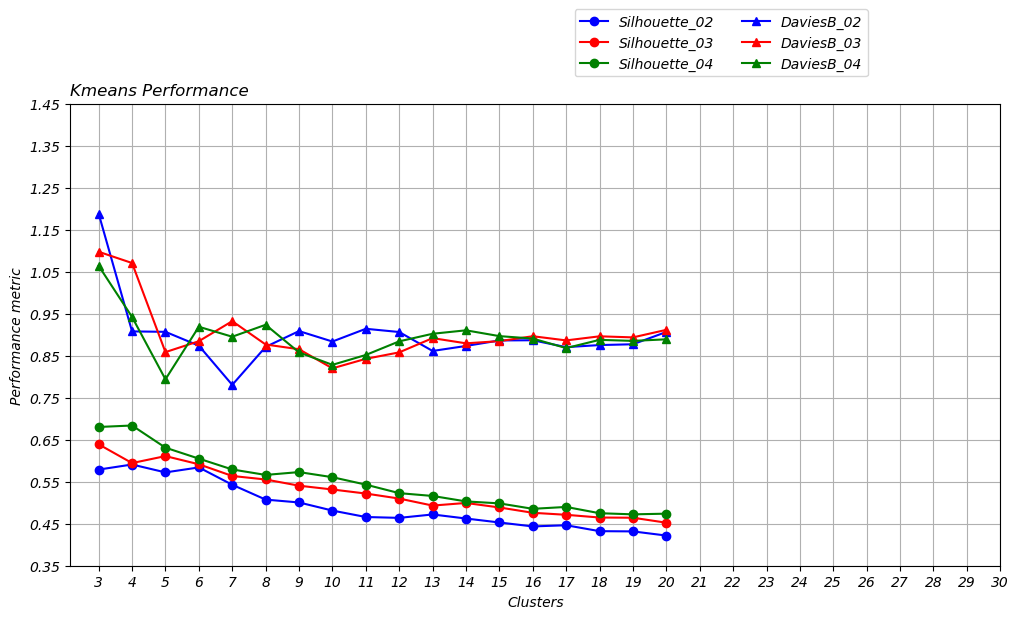

In [208]:
colors = ['blue', 'red', 'green']
marker = ['o', '^']
plt.figure(figsize = [12,6])
for i, s in enumerate(['Silhouette', 'DaviesB']):
    for j, ch in enumerate([2,3,4]):
        plt.plot(dfKS['clusters'], dfKS[f'{s}_0{ch}'], marker = marker[i], label = f'{s}_0{ch}', color = colors[j])
    # plt.plot(dfKS['clusters'], dfKS[f'{s}'], marker = marker[i], label = f'{s}', color = colors[0])
plt.xticks(np.arange(3,31))
plt.ylim([0.4,1.2])
plt.yticks(np.arange(0.35,1.5, 0.1))
plt.grid()
plt.title('Kmeans Performance', loc = 'left')
plt.legend(bbox_to_anchor = [0.7,1.22], ncols = 2, loc = 'upper center')
plt.xlabel('Clusters')
plt.ylabel('Performance metric')
plt.show()

In [37]:
dfGS['init'].unique()

array([ 5, 15, 25, 50])

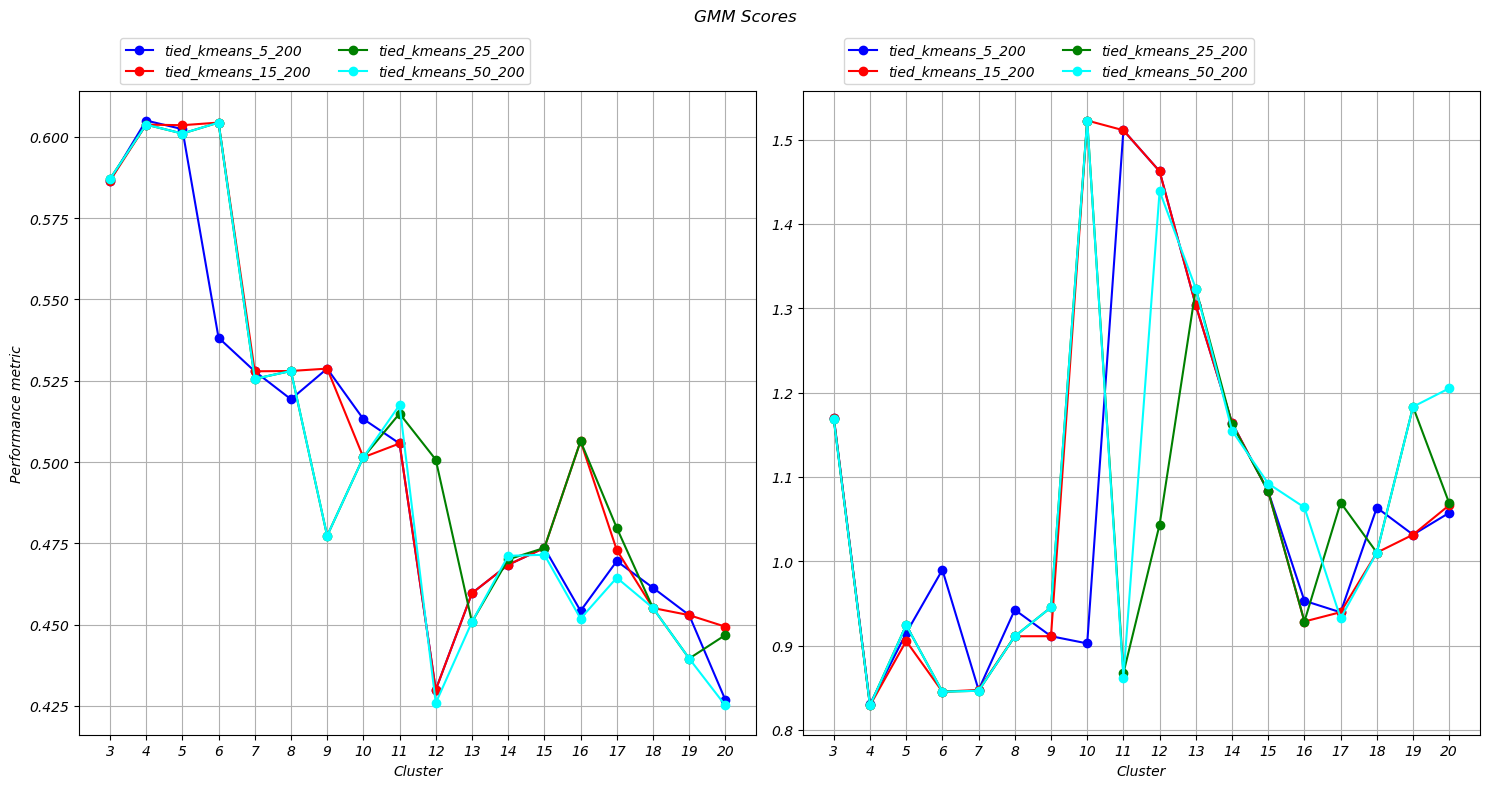

In [43]:
colors = ['blue', 'red', 'green', 'cyan']
marker = ['o', '^']
line = ['-', '--']
col = 0
f, ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,8])
for scoreI, score in enumerate(['Silhouette', 'DaviesB']):
    for algI, alg in enumerate(['tied']):
        for initI, init in enumerate(['kmeans']):
            for maxiI, maxi in enumerate([200]):
                for I, i in enumerate(dfGS['init'].unique()):
                    for chI, ch in enumerate([2]):
                        dfA = dfGS[(dfGS['cov_type'] == alg) & (dfGS['init_p'] == init) & (dfGS['init'] == i) & (dfGS['max_iter'] == maxi)]

                        ax[scoreI].plot(dfA['clusters'], dfA[f'{score}_0{ch}'], 
                                    marker = marker[maxiI], 
                                    label = f'{alg}_{init}_{i}_{maxi}',
                                    color = colors[I], 
                                    linestyle = line[initI]
                                    )
            # dfA = dfGS[dfGS['cov_type'] == alg]
            # ax[stI].plot(dfA['clusters'], dfA[f'{s}'], marker = marker[i], label = f'{s}', color = colors[0], linestyle = line[ai])
    ax[scoreI].grid()
    ax[scoreI].set_xticks(np.arange(3,21))

    ax[scoreI].set_xlabel('Cluster')
    ax[scoreI].legend(bbox_to_anchor = [0.05,1], ncols = 2, loc = 'lower left')
ax[0].set_ylabel('Performance metric')
# ax[0].set_ylim([0.4,1.8])
# ax[0].set_yticks(np.arange(0.4,1.8, 0.1))
f.suptitle('GMM Scores')
plt.tight_layout()
plt.show()

# Open and transform data

In [3]:
CH = 2
# df = open_dataset_confinement_clustering(CH)
f = "/Volumes/PhD/confinement/results/single_values/global_50_02_smoothed.nc"
ds = xr.open_dataset(f)
df = ds.to_dataframe().reset_index()

In [4]:
df['slope_max'] = (df['cm_height'] - df['cp_height']) / (df['bendWidths']*0.5)
df['slope_out_normalized']   = df['slope_out']   / df['slope_max']
df['slope_inn_normalized']   = df['slope_inn']   / df['slope_max']
df['slope_left_normalized']  = df['slope_left']  / df['slope_max']
df['slope_right_normalized'] = df['slope_right'] / df['slope_max']

In [5]:
slopeCols   = ['slope_out_normalized', 'slope_right_normalized', 'slope_left_normalized', 'slope_inn_normalized']
slopeSCols  = ['slope_out_normalized_smooth', 'slope_right_normalized_smooth', 'slope_left_normalized_smooth', 'slope_inn_normalized_smooth']
slopeECols  = ['ER_out', 'ER_left', 'ER_inn', 'ER_right']


In [6]:
dfCluster, pca, Xpca = data_prep_clustering(df, slopeCols+slopeSCols,True, 3, False)
# dfCluster, pca, Xpca = data_prep_clustering(df, slopeCols,True, 3, False)

In [7]:
dfCluster['ER_inn'].mean(),\
dfCluster['ER_out'].mean(),\
dfCluster['slope_inn_normalized'].mean(),\
dfCluster['slope_out_normalized'].mean(),\
dfCluster['ER_inn'].std(),\
dfCluster['ER_out'].std(),\
dfCluster['slope_inn_normalized'].std(),\
dfCluster['slope_out_normalized'].std()

(np.float64(9.583052929968265),
 np.float64(7.617419285436344),
 np.float64(0.20546201512161325),
 np.float64(0.27771562634513225),
 np.float64(11.240435554416985),
 np.float64(10.661180727163984),
 np.float64(0.2933576387448999),
 np.float64(0.3254780685604089))

In [7]:
# F = ['slope_out_normalized', 'slope_inn_normalized','slope_left_normalized', 'slope_right_normalized']
# cols = []
# for ch in [2,3,4]:
#     cols.extend([f + f'_0{ch}' for f in F])
#     cols.extend([f + f'_smooth_0{ch}' for f in F])
# X_merged = scale(merged_df, ['slope_out_normalized_02', 'slope_inn_normalized_02',
#        'slope_left_normalized_02', 'slope_right_normalized_02',
#        'slope_out_normalized_smooth_02', 'slope_inn_normalized_smooth_02',
#        'slope_left_normalized_smooth_02', 'slope_right_normalized_smooth_02',
#        'slope_out_normalized_03', 'slope_inn_normalized_03',
#        'slope_left_normalized_03', 'slope_right_normalized_03',
#        'slope_out_normalized_smooth_03', 'slope_inn_normalized_smooth_03',
#        'slope_left_normalized_smooth_03', 'slope_right_normalized_smooth_03',
#        'slope_out_normalized_04', 'slope_inn_normalized_04',
#        'slope_left_normalized_04', 'slope_right_normalized_04',
#        'slope_out_normalized_smooth_04', 'slope_inn_normalized_smooth_04',
#        'slope_left_normalized_smooth_04', 'slope_right_normalized_smooth_04'])

# PCA

In [12]:
# CH 2: [0.72575038 0.13608546 0.12450421 0.00698942 0.00346737]
# CH 3: [0.72893431 0.13547315 0.12275418 0.00621153 0.00338705]
# CH 4: [0.73533824 0.13296371 0.11946631 0.00576449 0.00333431]

In [7]:
dfClusterPCAVis, pcaVis, XpcaVis = data_prep_clustering(df, slopeCols+slopeSCols,True, 8, False)

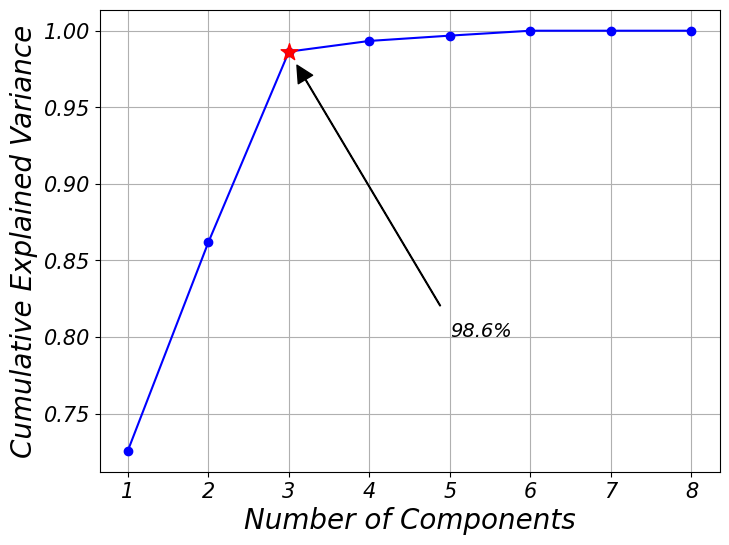

In [34]:
f, ax = plt.subplots(figsize = [8,6])
ax.plot(range(1, len(pcaVis.explained_variance_ratio_) + 1), 
         pcaVis.explained_variance_ratio_.cumsum(), marker='o', color = 'blue')
ax.tick_params(axis='both', which='major', labelsize=tickSize)
plt.xlabel('Number of Components', fontsize = labelSize)
plt.ylabel('Cumulative Explained Variance', fontsize = labelSize)
vals = 3
T = pcaVis.explained_variance_ratio_.cumsum()[vals -1]
plt.annotate(f'{np.round(T*100,1)}%', [3, T], [5,0.8], arrowprops={'width':0.5, 'color':'black', 'shrink':0.05}, fontsize = 14)
plt.scatter(3, T, c = 'red', zorder = 100, marker = '*', s = 160)
plt.grid(True)
plt.savefig('/home/6256481/River_Morphology/results/figures/' + 'PCA_confinement_clustering.png', dpi = 1000)
plt.show()

In [35]:
print_pca_loadings(pcaVis, slopeCols+slopeSCols)


                                 PC1    PC2    PC3    PC4    PC5    PC6  \
slope_out_normalized           0.349  0.135 -0.508 -0.425  0.361  0.127   
slope_right_normalized         0.345 -0.500 -0.158 -0.363 -0.214  0.419   
slope_left_normalized          0.345  0.509  0.119 -0.348  0.124 -0.469   
slope_inn_normalized           0.346 -0.142  0.523 -0.284 -0.497 -0.192   
slope_out_normalized_smooth    0.368  0.119 -0.428  0.446 -0.424 -0.152   
slope_right_normalized_smooth  0.358 -0.458 -0.124  0.351  0.229 -0.466   
slope_left_normalized_smooth   0.357  0.460  0.124  0.327 -0.139  0.514   
slope_inn_normalized_smooth    0.360 -0.127  0.465  0.237  0.556  0.217   

                                 PC7    PC8  
slope_out_normalized           0.522 -0.034  
slope_right_normalized        -0.501  0.033  
slope_left_normalized         -0.500  0.033  
slope_inn_normalized           0.471 -0.031  
slope_out_normalized_smooth    0.034  0.515  
slope_right_normalized_smooth -0.033 -0.503  
sl

# Confinement vs width & elevation

In [ ]:
def slope_vs_X_boxplots(X, XLab):
    f, ax = plt.subplots(ncols = 1, nrows = 2, figsize = [17, 11], sharex = True)
    side = ['out', 'inn']
    colors = [colorOut, colorInn]
    for i in range(2):
        sns.boxplot(data = df, x = X, y = f'slope_{side[i]}_normalized', ax = ax[i],color = colors[i])
        ax[i].set_yticks([-1,-0.5,-0.25,0,0.25,0.5,1])
        ax[i].grid(axis = 'y', linestyle=(0, (5,10)), linewidth=1, alpha = 0.5)
        ax[i].set_xlabel(f'Bend {XLab} (m)', fontsize = labelSize)
        ax[i].set_ylabel(f'Normalized slope', fontsize = labelSize)
        ax[i].tick_params(axis='both', which='major', labelsize=tickSize)
        ax[i].set_ylim([-1.1,1.1])


    # Custom legend
    handles = [
        mpatches.Patch(facecolor=colorOut,edgecolor='black', linewidth=1, label='Outer bend'),
        mpatches.Patch(facecolor=colorInn,edgecolor='black', linewidth=1, label='Inner bend')
    ]
    # ax[0].legend(handles=handles, loc='lower right', fontsize=tickSize, title='Bend side')

    f.legend(handles=handles, loc='upper center', title='Bend side', ncol=2, bbox_to_anchor = [0.5,1.05], fontsize = legendEntrySize, title_fontsize = legendTitleSize)


    plt.tight_layout()
    # plt.savefig(directory + f'results/figures/slope_vs_{XLab}_box_0{CH}.png')
    plt.show()

## Width

### Boxplots

In [13]:
def binWE(df, bin_var, med_var, num_bin = 30, set_max = True, max_bin = 350):    
    df = df.copy()
    df['bin'] = pd.qcut(df[bin_var], q=num_bin, labels=False)
    # print(df.groupby('bin').size())
    binLabel, medianvar = [], []
    for b in df['bin'].sort_values().unique():
        rows       = df.loc[df['bin'] == b]
        valueRange = rows[bin_var].max() - rows[bin_var].min()

        binLabel.append(int(rows[bin_var].min() + valueRange))
        medianvar.append(rows[med_var].quantile(0.5))
    if set_max == True:
        binLabel[-1] = max_bin
    return binLabel, medianvar
binWH, medianWH = binWE(df, 'bendWidths', 'bendHeight', 40)
binHW, medianHW = binWE(df, 'bendHeight', 'bendWidths', 50, max_bin = 2500)

In [14]:
def bootstrap_se_median(x, n_boot=2000, random_state=None):
    rng = np.random.default_rng(random_state)
    n = len(x)

    boot_medians = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(x, size=n, replace=True)
        boot_medians[i] = np.nanmedian(sample)

    return boot_medians.std(ddof=1)

def get_binned_medians(df, num_bin, bin_var, set_max = False, max_bin = 0,
                       varOut = 'slope_out_normalized', varInn = 'slope_inn_normalized'):
    df = df.copy()
    df['bin'] = pd.qcut(df[bin_var], q=num_bin, labels=False)
    # print(df.groupby('bin').size())
    binLabel, medianOut, medianInn,quant1Out, quant3Out,quant1Inn, quant3Inn, stdO, stdI = [], [], [],[],[],[],[], [],[]
    for b in df['bin'].sort_values().unique():
        rows       = df.loc[df['bin'] == b]
        valueRange = rows[bin_var].max() - rows[bin_var].min()

        binLabel.append(int(rows[bin_var].min() + valueRange))
        medianOut.append(rows[varOut].quantile(0.5))
        medianInn.append(rows[varInn].quantile(0.5))
        quant1Out.append(rows[varOut].quantile(0.25))
        quant3Out.append(rows[varOut].quantile(0.75))
        quant1Inn.append(rows[varInn].quantile(0.25))
        quant3Inn.append(rows[varInn].quantile(0.75))
        # stdO.append(rows['slope_out_normalized'].std() / np.sqrt(rows.shape[0]))
        # stdI.append(rows['slope_inn_normalized'].std() / np.sqrt(rows.shape[0]))

        stdO.append(bootstrap_se_median(rows[varOut]))
        stdI.append(bootstrap_se_median(rows[varInn]))
    if set_max == True:
        binLabel[-1] = max_bin
    return binLabel, medianOut, medianInn,quant1Out, quant3Out,quant1Inn, quant3Inn, stdO, stdI


In [15]:
df = df.copy()
df['bin'] = pd.qcut(df['slope_out_normalized'], q=30, labels=False)
# print(df.groupby('bin').size())
binLabel, medianOut, medianInn,quant1Out, quant3Out,quant1Inn, quant3Inn, stdO, stdI = [], [], [],[],[],[],[], [],[]
for b in df['bin'].sort_values().unique():
    if np.isnan(b):
        continue
    rows       = df.loc[df['bin'] == b]
    valueRange = rows['bendWidths'].max() - rows['bendWidths'].min()

    # stdO.append(rows['slope_out_normalized'].std() / np.sqrt(rows.shape[0]))
    # stdI.append(rows['slope_inn_normalized'].std() / np.sqrt(rows.shape[0]))
    binLabel.append(int(rows['slope_out_normalized'].min() + valueRange))
    stdO.append(bootstrap_se_median(rows['bendWidths']))
    stdI.append(bootstrap_se_median(rows['bendWidths']))

In [16]:

binW, medianOutWidth,medianInnWidth, quant1OutWidth, quant3OutWidth,quant1InnWidth, quant3InnWidth, stdOW, stdIW = get_binned_medians(df, 30, 'bendWidths', True, 350)
binE, medianOutElev,medianInnElev,quant1OutElev, quant3OutElev,quant1InnElev, quant3InnElev, stdOE, stdIE   = get_binned_medians(df, 30, 'bendHeight', True, 2500)

In [17]:
binWR, medianOutWidthER,medianInnWidthER,quant1OutWidthER, quant3OutWidthER,quant1InnWidthER, quant3InnWidthER, stdOWER, stdIWER   = get_binned_medians(df, 30, 'bendWidths', True, 350,
                                                                                                                                          'ER_out', 'ER_inn')
binER, medianOutElevER,medianInnElevER,quant1OutElevER, quant3OutElevER,quant1InnElevER, quant3InnElevER, stdOEER, stdIEER   = get_binned_medians(df, 30, 'bendHeight', True, 2500, 
                                                                                                                                                  'ER_out', 'ER_inn')


In [ ]:
bin

Text(0, 0.5, 'Width (m)')

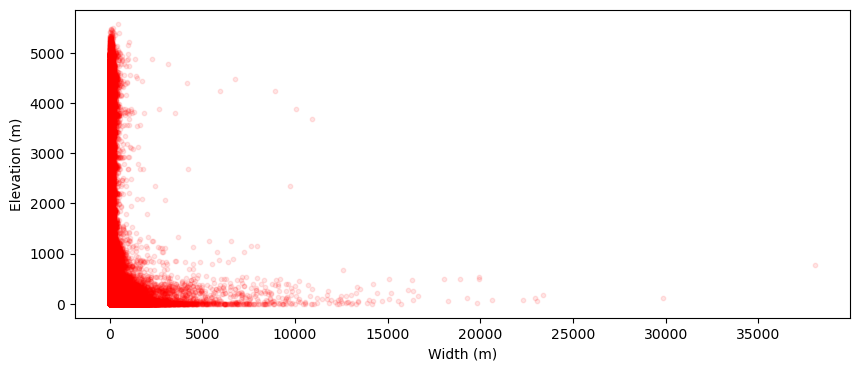

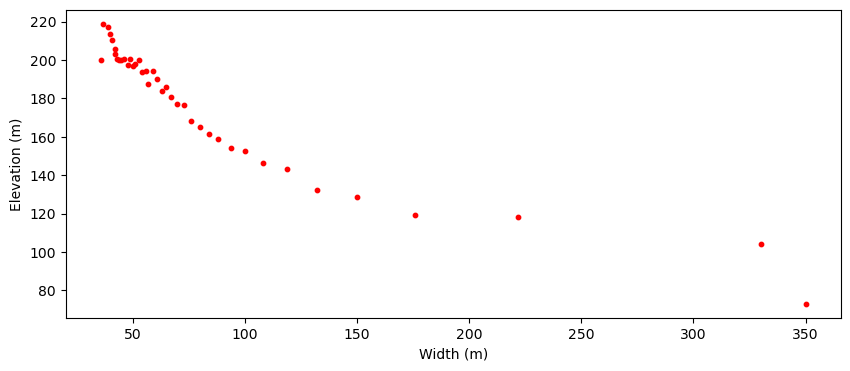

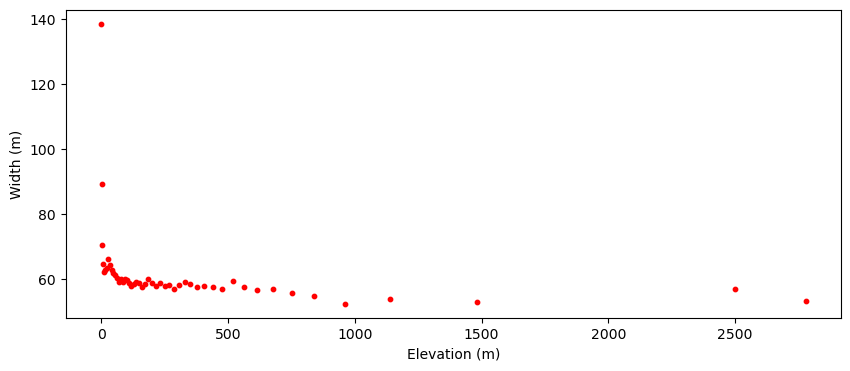

In [55]:
dfP = df.copy()
dfP.loc[dfP['bendHeight']<0, 'bendHeight'] = 0
plt.figure(figsize = [10,4])
plt.scatter(dfP['bendWidths'], dfP['bendHeight'], color = 'red' , label = 'Outer', s = 10, alpha = 0.1)
plt.xlabel('Width (m)')
plt.ylabel('Elevation (m)')

plt.figure(figsize = [10,4])
plt.scatter(binWH, medianWH, color = 'red' , label = 'Outer', s = 10)
plt.xlabel('Width (m)')
plt.ylabel('Elevation (m)')

plt.figure(figsize = [10,4])
plt.scatter(binHW, medianHW, color = 'red' , label = 'Outer', s = 10)
plt.xlabel('Elevation (m)')
plt.ylabel('Width (m)')



UnboundLocalError: cannot access local variable 'medianOutElevER' where it is not associated with a value

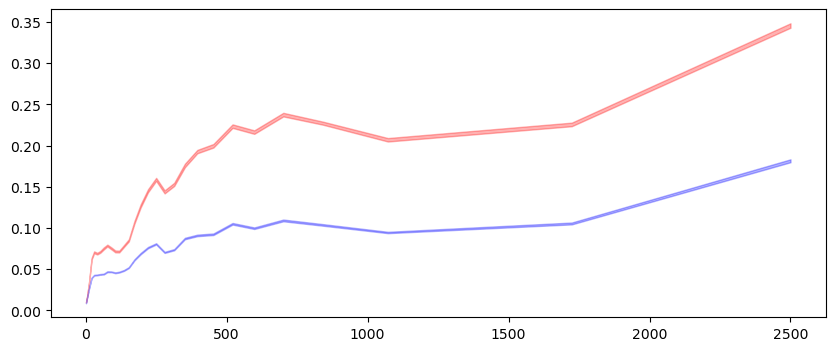

In [18]:
def plot_medians(X, Y1, Y2,q1O,q3O,q1I,q3I,stdO,stdI, xlab, xticks, yticks, xlim, textOut, textInn, saveT):


    stdO,stdI = np.array(stdO),np.array(stdI)
    Y1,Y2 = np.array(Y1),np.array(Y2)

    fig, ax1 = plt.subplots(figsize = [10,4])
# plt.figure()

    # plt.plot(X, Y1, color = 'red' , label = 'Outer')
    # plt.plot(X, Y2, color = 'blue', label = 'Inner')
    ax1.fill_between(X, Y1-stdO, Y1+stdO, color = 'red', alpha = 0.3)
    ax1.fill_between(X, Y2-stdI, Y2+stdI, color = 'blue', alpha = 0.3)
    medianOutElevER = np.array(medianOutElevER)
    medianInnElevER = np.array(medianInnElevER)
    stdOEER, stdIEER = np.array(stdOEER), np.array(stdIEER)
    ax2 = ax1.twinx()
    ax2.fill_between(X, medianOutElevER-stdOEER, medianOutElevER+stdOEER, color = 'red', alpha = 0.3)
    ax2.fill_between(X, medianInnElevER-stdIEER, medianInnElevER+stdIEER, color = 'blue', alpha = 0.3)

    # plt.yticks(yticks)
    
    # xtick_labels = [str(x) for x in xticks[:-1]] + [f"{xticks[-1]}+"]

    plt.xscale('log')
    # plt.xticks(xticks, xtick_labels)
    # plt.minorticks_off()

    # plt.tick_params(axis='both', which='major', labelsize=tickSize)
    # plt.grid(axis="y",color ='gray', linestyle = '--',alpha = 0.5)
    # plt.xlim(xlim)
    plt.text(textOut[0], textOut[1],'Outer', color = 'red', fontsize = labelSize)
    plt.text(textInn[0], textInn[1],'Inner', color = 'blue', fontsize = labelSize)
    plt.xlabel(xlab, fontsize = labelSize, )
    plt.ylabel('Normalized slope', fontsize = labelSize)
    plt.tight_layout()
    
    # plt.savefig('/home/6256481/River_Morphology/results/figures/' + f'normalizedSlope_{saveT}.png', dpi = 1000)
    # plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/' + f'normalizedSlope_{saveT}.png', dpi = 1000)
    plt.ylim(bottom=0)

    plt.show()

# plot_medians(binW, medianOutWidth, medianInnWidth, quant1OutWidth, quant3OutWidth, 
#              quant1InnWidth, quant3InnWidth,stdOW, stdIW, 'Width (m)'    , [35,50,100,200,350] , [0.0,0.05,0.1,0.15,0.2], [35, 350], [125, 0.21], [125,0.115], 'width')
plot_medians(binE, medianOutElev , medianInnElev,quant1OutElev, quant3OutElev, 
             quant1InnElev, quant3InnElev, stdOE, stdIE , 'Elevation (m)', [1,10, 100,1000,2500], [0.0, 0.1,0.2,0.3]  , [1, 2500],[800, 0.230], [900,0.11], 'elevation')

# plot_medians(binER, medianOutElevER , medianInnElevER,quant1OutElevER, quant3OutElevER, 
#              quant1InnElevER, quant3InnElevER, stdOEER, stdIEER , 'Elevation (m)', [1,10, 100,1000,2500], [0.0, 0.1,0.2,0.3]  , [1, 2500],[800, 0.230], [900,0.11], 'elevation')

-13.92025972199653 4.372322119551023


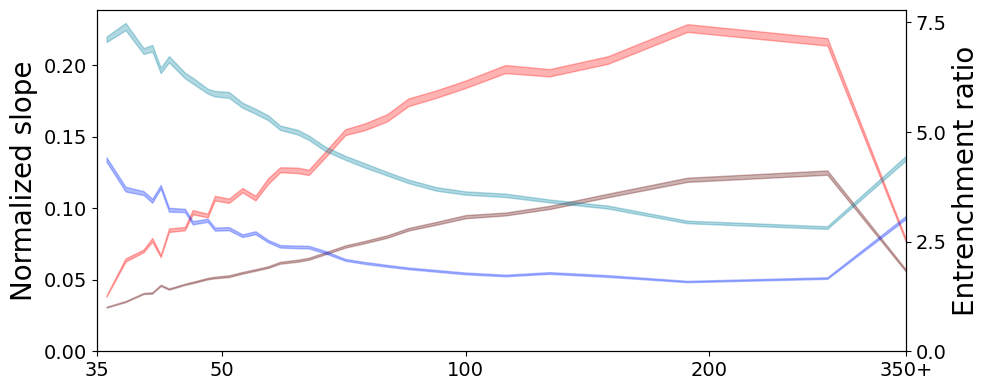

-12.888306838199695 4.621000460155666


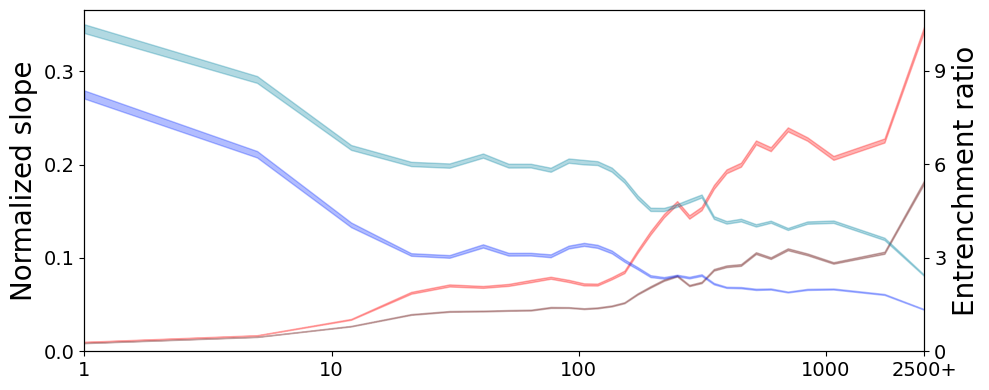

In [23]:
def plot_medians(X, Y1, Y2,stdO1,stdI1,
                    Y11, Y22,stdO2,stdI2,
                 xlab, xticks, yticks1, yticks2, xlim, textOut, textInn, saveT, quant = False):


    stdO1,stdI1 = np.array(stdO1),np.array(stdI1)
    Y1,Y2 = np.array(Y1),np.array(Y2)

    stdO2,stdI2 = np.array(stdO2),np.array(stdI2)
    Y11,Y22 = np.array(Y11),np.array(Y22)

    A = np.vstack([Y1, np.ones_like(Y1)]).T
    a, b = np.linalg.lstsq(A, Y11, rcond=None)[0]
    print(a, b)


    fig, ax1 = plt.subplots(figsize = [10,4])
    if quant == True:
        ax1.fill_between(X, stdO1, stdO1, color = '#ff0000', alpha = 0.3)
        ax1.fill_between(X, stdI1, stdI1, color = "#5C0000", alpha = 0.3)

        ax2 = ax1.twinx()
        ax2.fill_between(X, stdO2, stdO2, color = '#0026ff', alpha = 0.3)
        ax2.fill_between(X, stdI2, stdI2, color = "#0083a1", alpha = 0.3)
    else:
        ax1.fill_between(X, Y1-stdO1, Y1+stdO1, color = '#ff0000', alpha = 0.3)
        ax1.fill_between(X, Y2-stdI1, Y2+stdI1, color = "#5C0000", alpha = 0.3)

        ax2 = ax1.twinx()
        ax2.fill_between(X, Y11-stdO2, Y11+stdO2, color = '#0026ff', alpha = 0.3)
        ax2.fill_between(X, Y22-stdI2, Y22+stdI2, color = "#0083a1", alpha = 0.3)

    # ax1.grid(axis="y",color ='gray', linestyle = '--',alpha = 0.5)
    ax1.set_yticks(yticks1)
    ax2.set_yticks(yticks2)
    
    xtick_labels = [str(x) for x in xticks[:-1]] + [f"{xticks[-1]}+"]
    plt.xscale('log')
    plt.xticks(xticks, xtick_labels)
    plt.minorticks_off()

    
    plt.xlim(xlim)

    ax1.tick_params(axis='both', which='major', labelsize=tickSize)
    ax2.tick_params(axis='both', which='major', labelsize=tickSize)
    # plt.text(textOut[0], textOut[1],'Outer', color = 'red', fontsize = labelSize)
    # plt.text(textInn[0], textInn[1],'Inner', color = 'blue', fontsize = labelSize)
    plt.xlabel(xlab, fontsize = labelSize, )
    ax1.set_ylabel('Normalized slope', fontsize = labelSize)
    ax2.set_ylabel('Entrenchment ratio', fontsize = labelSize)
    plt.tight_layout()
    ax1.set_ylim(bottom=0)

    # plt.savefig('/home/6256481/River_Morphology/results/figures/' + f'normalizedSlope_{saveT}.png', dpi = 1000)
    # plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/' + f'normalizedSlope_{saveT}.png', dpi = 1000)
    plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/' + f'slope_ER_{saveT}.png', dpi = 1000)

    plt.show()
tickSize = 14

plot_medians(binW, medianOutWidth , medianInnWidth, stdOW, stdIW,
                   medianOutWidthER , medianInnWidthER, stdOWER, stdIWER , 
                   'Width (m)',  [35,50,100,200,350] , [0.0,0.05,0.1,0.15,0.2],[0,2.5,5,7.5], [35, 350], [125, 0.21], [125,0.115], 'width')
plot_medians(binE, medianOutElev , medianInnElev, stdOE, stdIE,
                   medianOutElevER , medianInnElevER, stdOEER, stdIEER , 
                   'Elevation (m)', [1,10, 100,1000,2500], [0.0, 0.1,0.2,0.3],[0,3,6,9]  , [1, 2500],[800, 0.230], [900,0.11], 'elevation')


# plot_medians(binW, medianOutWidth , medianInnWidth, quant1OutWidth, quant1InnWidth,
#                    medianOutWidthER , medianInnWidthER, quant1OutWidthER, quant1InnWidthER , 
#                    'Width (m)',  [35,50,100,200,350] , [0.0,0.05,0.1,0.15,0.2],[0,2.5,5,7.5], [35, 350], [125, 0.21], [125,0.115], 'width_quant', quant = True)
# plot_medians(binE, medianOutElev , medianInnElev, quant1OutElev, quant1InnElev,
#                    medianOutElevER , medianInnElevER, quant1OutElevER, quant3InnElev , 
#                    'Elevation (m)', [1,10, 100,1000,2500], [0.0, 0.1,0.2,0.3],[0,3,6,9]  , [1, 2500],[800, 0.230], [900,0.11], 'elevation_quant', quant = True)



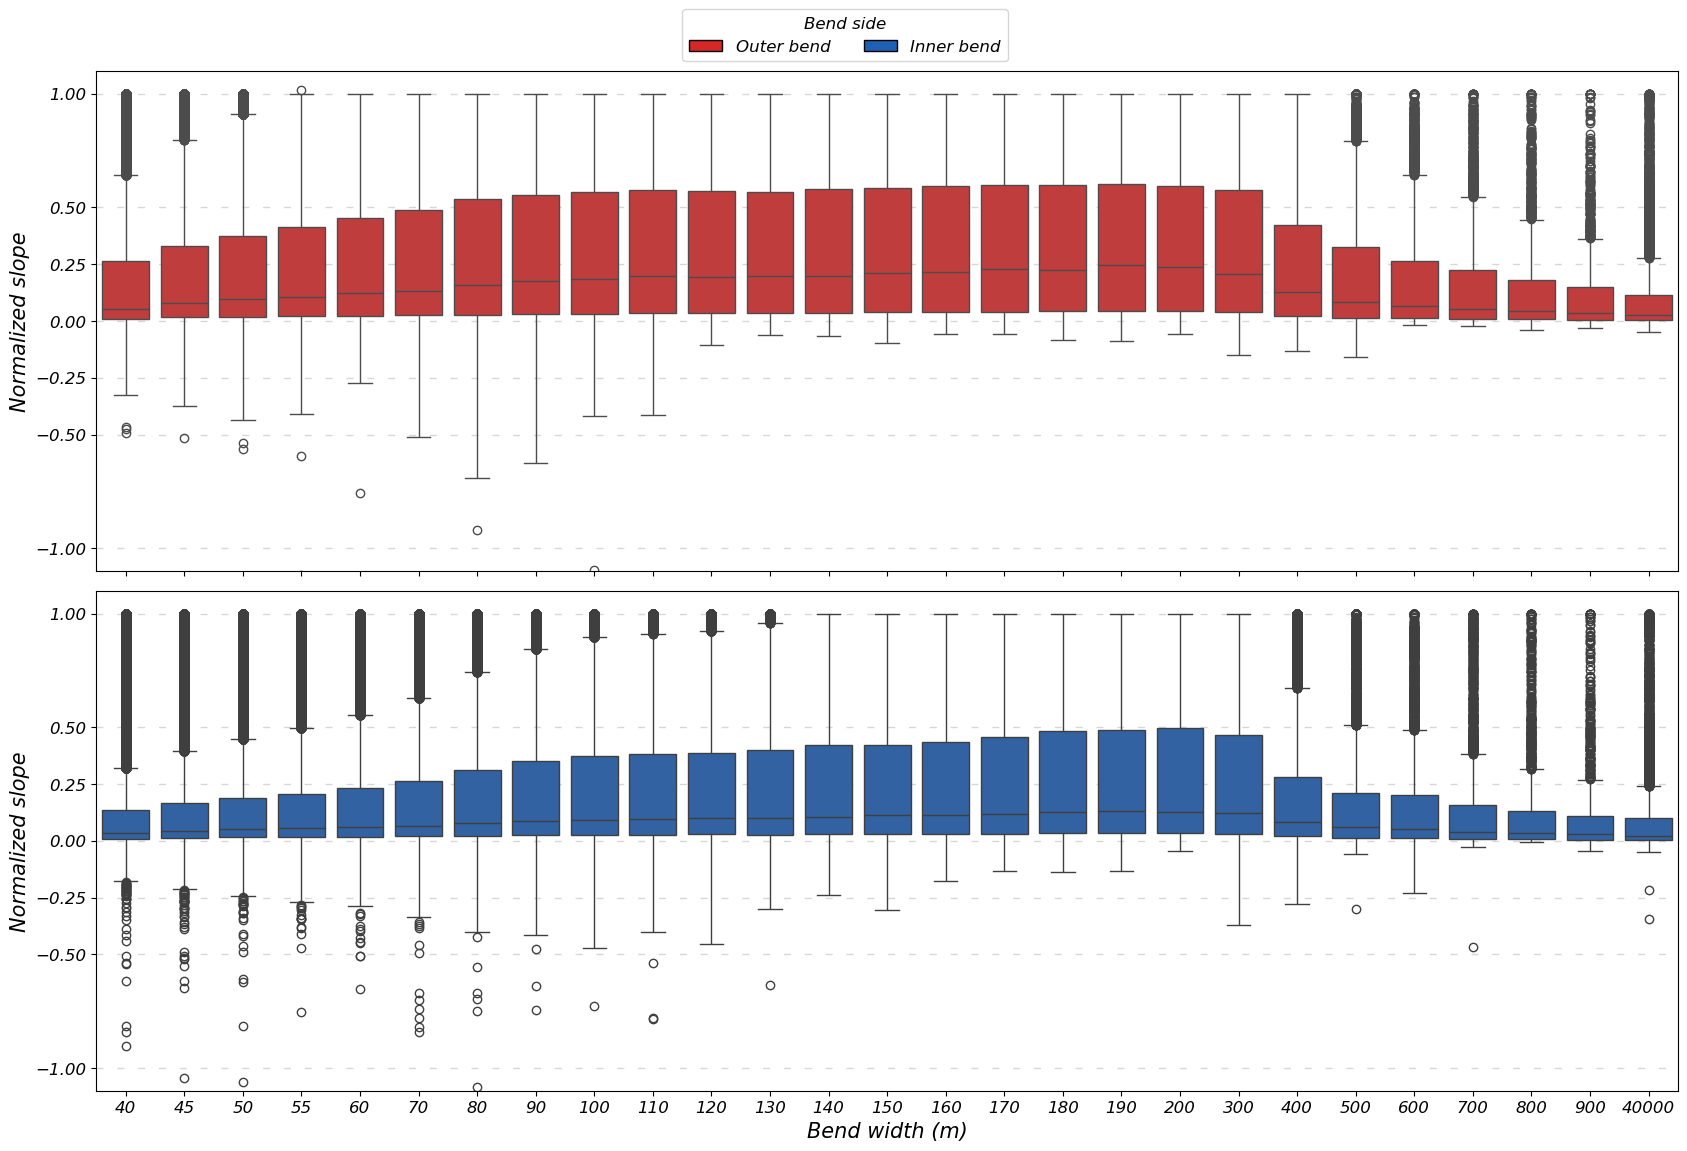

In [24]:
slope_vs_X_boxplots('bendWidthBins', 'width')

## WIDTH / ELEVATION CONTOUR PLOTS

In [84]:
dfP['slope_inn_normalized'].min(), dfP['slope_inn_normalized'].max(),\
dfP['slope_out_normalized'].min(), dfP['slope_out_normalized'].max()

(np.float64(-1.9572487284926532),
 np.float64(1.0),
 np.float64(-1.1159211770193598),
 np.float64(1.0147487831765716))

In [18]:
s = 0.0108
(1/s)/2

46.29629629629629

In [12]:
wsmall = dfCluster[dfCluster['bendWidths']<40]
wsmall['slope_out_normalized'].quantile(0.25), wsmall['slope_out_normalized'].quantile(0.75)
# wsmall['ER_out'].quantile(0.25), wsmall['ER_out'].quantile(0.75)

(np.float64(0.010802840276328496), np.float64(0.2633888641085))

Shared contour/colorbar levels:
[ 1.38337688  1.93973431  2.71984393  3.81369291  5.34745889  7.4980648
 10.51358728 14.7418728 ]


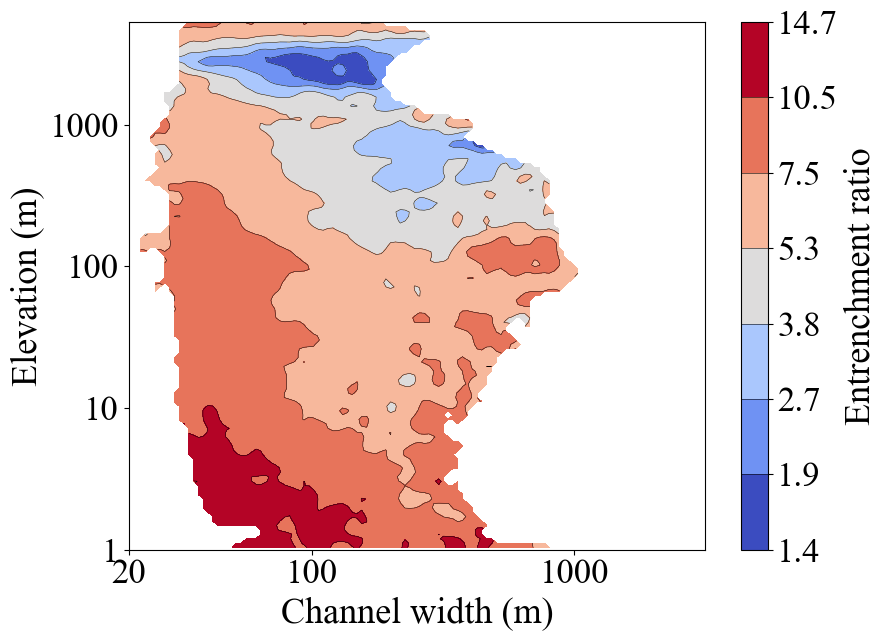


Variable: ER_diff_abs

Option 1: geometric centers
Level  0 [1.38, 1.94] | log center = (2.069, 3.387) | original center = (116.21, 2437.52)
Level  1 [1.94, 2.72] | log center = (2.023, 3.378) | original center = (104.52, 2387.98)
Level  2 [2.72, 3.81] | log center = (2.247, 3.008) | original center = (175.81, 1016.64)
Level  3 [3.81, 5.35] | log center = (2.239, 2.691) | original center = (172.35, 490.27)
Level  4 [5.35, 7.50] | log center = (2.138, 1.988) | original center = (136.49, 96.28)
Level  5 [7.50, 10.51] | log center = (1.997, 1.240) | original center = (98.25, 16.38)
Level  6 [10.51, 14.74] | log center = (1.838, 0.364) | original center = (67.94, 1.31)

Option 3: density-peak centers
Level  0 [1.38, 1.94] | log peak = (1.823, 3.475) | original peak = (65.45, 2987.42)
Level  1 [1.94, 2.72] | log peak = (1.658, 3.475) | original peak = (44.45, 2987.42)
Level  2 [2.72, 3.81] | log peak = (1.676, 3.538) | original peak = (46.41, 3448.70)
Level  3 [3.81, 5.35] | log peak = (1.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.ndimage import gaussian_filter

# =========================================================
# SETTINGS
# =========================================================
dfP = dfCluster.copy()
save_dir = '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'
# vars_to_plot = ['slope_out_normalized', 'slope_inn_normalized']
# cbar_label = "Normalized slope"
# level_step = 0.1
# saveN = 'S'
# use_log_levels = False
# base_cmap = plt.cm.coolwarm
# save_names = [save_dir + f'contour_WE{saveN}_out.png', save_dir + f'contour_WE{saveN}_inn.png']   # change if needed


# dfP['slope_diff_normalized'] = dfP['slope_out_normalized'] - dfP['slope_inn_normalized']
# dfP['slope_diff_abs_normalized'] = abs(dfP['slope_out_normalized'] - dfP['slope_inn_normalized'])
# vars_to_plot = ['slope_diff_abs_normalized']
# cbar_label = "Normalized slope"
# level_step = 0.1
# saveN = 'S'
# use_log_levels = False
# base_cmap = plt.cm.coolwarm
# titles = ['diff']
# save_names = [save_dir + f'contour_WE{saveN}_diff.png']   # change if needed


dfP['ER_diff'] = dfP['ER_out'] - dfP['ER_inn']
dfP['ER_diff_abs'] = abs(dfP['ER_out'] - dfP['ER_inn'])
vars_to_plot = ['ER_diff_abs']
cbar_label = "Entrenchment ratio"
level_step = 0.1
saveN = 'E'
use_log_levels = True
n_levels = 8
base_cmap = plt.cm.coolwarm
titles = ['diff']
save_names = [save_dir + f'contour_WE{saveN}_diff.png']   # change if needed



# vars_to_plot = ['ER_out', 'ER_inn']
# cbar_label = "Entrenchment ratio"
# level_step = 0.1
# saveN = 'E'
# use_log_levels = True
# n_levels = 8
# base_cmap = plt.cm.coolwarm
# titles = ['diff']
# save_names = [save_dir + f'contour_WE{saveN}_out.png', save_dir + f'contour_WE{saveN}_inn.png']   # change if needed



# vars_to_plot = ['ER_out', 'ER_inn']
# cbar_label = "Entrenchment ratio"
# level_step = 1.5
# saveN = 'E'
# base_cmap = plt.cm.coolwarm_r
# n_levels = 10
# use_log_levels = True

# titles = ['Out', 'Inn']




nx, ny = 120, 120
sigma = 1.2
min_support = 5

xmin_log = 1.3   # ~ 20 m
xmax_log = 3.5   # ~ 3161 m


dpi_save = 300

# -------------------------
# FONT SETTINGS
# -------------------------
font_family = 'Times New Roman'
title_size = 18
label_size = 26
tick_size = 25
cbar_label_size = 26
cbar_tick_size = 25

plt.rcParams['font.family'] = font_family
plt.rcParams['axes.titlesize'] = title_size
plt.rcParams['axes.labelsize'] = label_size
plt.rcParams['xtick.labelsize'] = tick_size
plt.rcParams['ytick.labelsize'] = tick_size

# =========================================================
# FIRST PASS: COMPUTE BOTH SMOOTHED FIELDS
# =========================================================
plot_data = {}

for c in vars_to_plot:
    x = dfP["bendWidths"].to_numpy()
    y = dfP["bendHeight"].to_numpy()
    z = dfP[c].to_numpy()

    mask = (
        np.isfinite(x) &
        np.isfinite(y) &
        np.isfinite(z) &
        (x >= 0) &
        (y >= 0)
    )

    x = x[mask]
    y = y[mask]
    z = z[mask]

    x_plot = np.log10(x + 1)
    y_plot = np.log10(y + 1)

    mask_xy = (x_plot >= xmin_log) & (x_plot <= xmax_log)
    x_plot = x_plot[mask_xy]
    y_plot = y_plot[mask_xy]
    z = z[mask_xy]

    xedges = np.linspace(xmin_log, xmax_log, nx + 1)
    yedges = np.linspace(np.nanmin(y_plot), np.nanmax(y_plot), ny + 1)

    sum_z, _, _ = np.histogram2d(x_plot, y_plot, bins=[xedges, yedges], weights=z)
    count, _, _ = np.histogram2d(x_plot, y_plot, bins=[xedges, yedges])

    sum_z_s = gaussian_filter(sum_z, sigma=sigma)
    count_s = gaussian_filter(count.astype(float), sigma=sigma)

    Zsmooth = np.divide(
        sum_z_s,
        count_s,
        out=np.full_like(sum_z_s, np.nan),
        where=count_s > 0
    )

    Zsmooth[count_s < min_support] = np.nan

    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")

    plot_data[c] = {
        "X": X,
        "Y": Y,
        "Zsmooth": Zsmooth,
        "count_s": count_s
    }

# =========================================================
# SHARED OBSERVED LEVELS ACROSS BOTH FIELDS
# =========================================================
all_z = np.concatenate([
    plot_data[c]["Zsmooth"][np.isfinite(plot_data[c]["Zsmooth"])]
    for c in vars_to_plot
])


shared_min = np.nanmin(all_z)
shared_max = np.nanmax(all_z)

if use_log_levels:
    # geomspace requires strictly positive values
    shared_min = max(shared_min, 1e-3)
    levels = np.geomspace(shared_min, shared_max, n_levels)
else:
    shared_min = np.floor(shared_min / level_step) * level_step
    shared_max = np.ceil(shared_max / level_step) * level_step

    if shared_min == shared_max:
        shared_min -= level_step
        shared_max += level_step

    levels = np.arange(shared_min, shared_max + level_step / 2, level_step)

print("Shared contour/colorbar levels:")
print(levels)

# =========================================================
# DISCRETE COLORMAP
# =========================================================
colors = base_cmap(np.linspace(0, 1, len(levels) - 1))
cmap = ListedColormap(colors)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# =========================================================
# PLOTTING: TWO SEPARATE FIGURES
# =========================================================
all_centers = {}

for i, c in enumerate(vars_to_plot):
    X = plot_data[c]["X"]
    Y = plot_data[c]["Y"]
    Zsmooth = plot_data[c]["Zsmooth"]
    count_s = plot_data[c]["count_s"]

    fig, ax = plt.subplots(figsize=(9, 6.5))

    # filled contours
    cf = ax.contourf(
        X, Y, Zsmooth,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend='neither'
    )

    # contour lines
    ax.contour(
        X, Y, Zsmooth,
        levels=levels,
        colors='k',
        linewidths=0.35
    )

    # -------------------------
    # compute centers
    # -------------------------
    option1_centers = []
    option3_centers = []

    for j in range(len(levels) - 1):
        low = levels[j]
        high = levels[j + 1]

        if j == len(levels) - 2:
            band_mask = (
                np.isfinite(Zsmooth) &
                (Zsmooth >= low) &
                (Zsmooth <= high)
            )
        else:
            band_mask = (
                np.isfinite(Zsmooth) &
                (Zsmooth >= low) &
                (Zsmooth < high)
            )

        if not np.any(band_mask):
            continue

        # Option 1: geometric center
        x_center_log = np.nanmean(X[band_mask])
        y_center_log = np.nanmean(Y[band_mask])

        x_center_orig = 10**x_center_log - 1
        y_center_orig = 10**y_center_log - 1

        option1_centers.append({
            "level_index": j,
            "level_low": low,
            "level_high": high,
            "x_log": x_center_log,
            "y_log": y_center_log,
            "x_orig": x_center_orig,
            "y_orig": y_center_orig
        })

        # ax.scatter(
        #     x_center_log, y_center_log,
        #     s=45, c='black', marker='o',
        #     edgecolor='white', linewidth=0.6, zorder=10
        # )

        # Option 3: highest density cell inside the level band
        density_in_band = np.where(band_mask, count_s, np.nan)

        if not np.all(np.isnan(density_in_band)):
            peak_idx = np.nanargmax(density_in_band)
            ix, iy = np.unravel_index(peak_idx, density_in_band.shape)

            x_peak_log = X[ix, iy]
            y_peak_log = Y[ix, iy]

            x_peak_orig = 10**x_peak_log - 1
            y_peak_orig = 10**y_peak_log - 1

            option3_centers.append({
                "level_index": j,
                "level_low": low,
                "level_high": high,
                "x_log": x_peak_log,
                "y_log": y_peak_log,
                "x_orig": x_peak_orig,
                "y_orig": y_peak_orig
            })

            # ax.scatter(
            #     x_peak_log, y_peak_log,
            #     s=55, c='yellow', marker='X',
            #     edgecolor='black', linewidth=0.6, zorder=11
            # )

    all_centers[c] = {
        "option1_geometric_center": option1_centers,
        "option3_density_peak": option3_centers
    }

    # -------------------------
    # colorbar
    # -------------------------
    cbar = fig.colorbar(
        cf,
        ax=ax,
        boundaries=levels,
        ticks=levels,
        spacing='uniform',
        drawedges=True
    )
    cbar.set_ticklabels([f"{lv:.1f}" for lv in levels])
    cbar.set_label(cbar_label, fontsize=cbar_label_size, fontname=font_family)
    cbar.ax.tick_params(labelsize=cbar_tick_size)

    # force Times New Roman on colorbar tick labels
    for ticklab in cbar.ax.get_yticklabels():
        ticklab.set_fontname(font_family)

    # -------------------------
    # axis formatting
    # -------------------------
    ax.set_xlim(xmin_log, xmax_log)

    xticks_log = np.array([1.3, 2, 3])
    xtick_labels = ['20', '100', '1000']
    ax.set_xticks(xticks_log)
    ax.set_xticklabels(xtick_labels, fontname=font_family)

    yticks_log = np.array([0, 1, 2, 3])
    ytick_labels = ['1', '10', '100', '1000']
    ax.set_yticks(yticks_log)
    ax.set_yticklabels(ytick_labels, fontname=font_family)

    ax.set_xlabel("Channel width (m)", fontsize=label_size, fontname=font_family)
    ax.set_ylabel("Elevation (m)", fontsize=label_size, fontname=font_family)
    # ax.set_title(titles[i], fontsize=title_size, fontname=font_family)

    ax.tick_params(axis='both', which='major', labelsize=tick_size)

    plt.tight_layout()
    plt.savefig(save_names[i], dpi=dpi_save, bbox_inches='tight')
    plt.show()

# =========================================================
# PRINT CENTERS
# =========================================================
for var_name, result in all_centers.items():
    print(f"\n{'='*80}")
    print(f"Variable: {var_name}")
    print(f"{'='*80}")

    print("\nOption 1: geometric centers")
    for item in result["option1_geometric_center"]:
        print(
            f"Level {item['level_index']:2d} "
            f"[{item['level_low']:.2f}, {item['level_high']:.2f}] | "
            f"log center = ({item['x_log']:.3f}, {item['y_log']:.3f}) | "
            f"original center = ({item['x_orig']:.2f}, {item['y_orig']:.2f})"
        )

    print("\nOption 3: density-peak centers")
    for item in result["option3_density_peak"]:
        print(
            f"Level {item['level_index']:2d} "
            f"[{item['level_low']:.2f}, {item['level_high']:.2f}] | "
            f"log peak = ({item['x_log']:.3f}, {item['y_log']:.3f}) | "
            f"original peak = ({item['x_orig']:.2f}, {item['y_orig']:.2f})"
        )

np.float64(1.7417383414404863)

## Elevation

### Boxplots

In [8]:
bins1 = np.array([-9999])

bins2 = np.arange(50,550, 50)
bins3 = np.arange(600,1100, 100)
bins4 = np.arange(1200,2200, 200)
bins5 = np.arange(2500,4000, 500)
bins6 = np.array([5500])
bins = np.concatenate([bins1, bins2, bins3, bins4, bins5, bins6])
labels = bins[1:]
bins

array([-9999,    50,   100,   150,   200,   250,   300,   350,   400,
         450,   500,   600,   700,   800,   900,  1000,  1200,  1400,
        1600,  1800,  2000,  2500,  3000,  3500,  5500])

In [9]:
df['bendHeightBins'] = pd.cut(df['bendHeight'], bins = bins, labels = labels, right = False)
df['bendHeightBins'] = df['bendHeightBins'].astype(int)

In [10]:
df.groupby('bendHeightBins').count()['index']

bendHeightBins
50      336953
100     191421
150     156954
200     118198
250      89361
300      80478
350      67439
400      55229
450      43884
500      37552
600      65607
700      47868
800      37635
900      29023
1000     20542
1200     30189
1400     17567
1600     10862
1800      6370
2000      4895
2500      8655
3000      6653
3500      6763
5500     20398
Name: index, dtype: int64

In [14]:
df['bendHeightBins'].unique()

array([ 350,  300,  250,  200,  150,  100,   50,  800,  700,  600,  500,
        450,  400, 1400, 1200, 1000,  900, 1600, 2000, 1800, 2500, 3500,
       3000, 5500])

array([  50,  100,  150,  200,  250,  300,  350,  400,  450,  500,  600,
        700,  800,  900, 1000, 1200, 1400, 1600, 1800, 2000, 2500, 3000,
       3500, 5500])

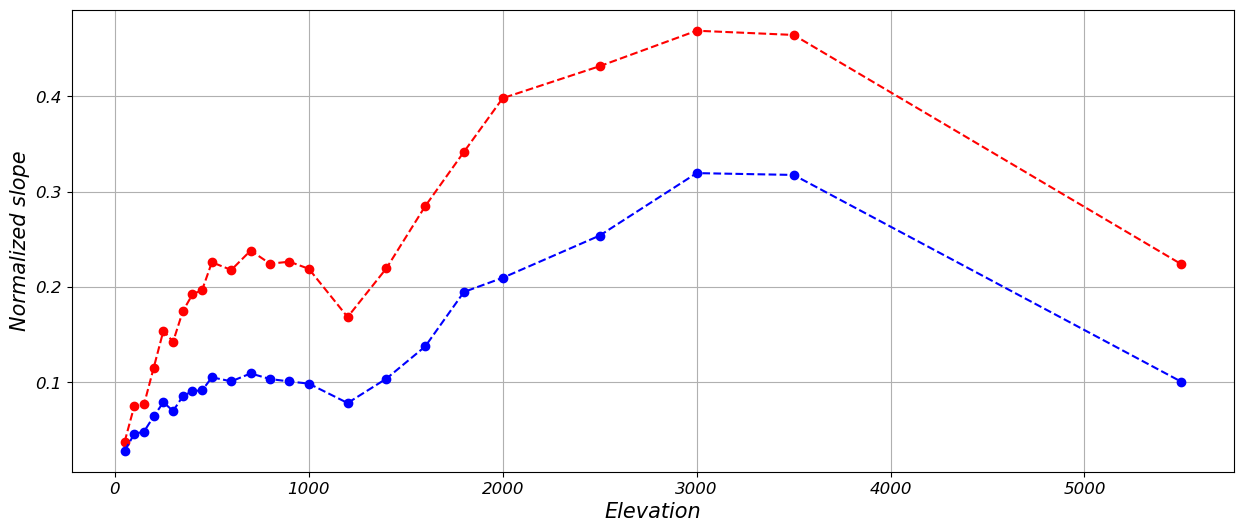

In [32]:

valsO, valsI = [], []
for E in df['bendHeightBins'].sort_values().unique():
    valO = df.loc[(df['bendHeightBins'] == E), 'slope_out_normalized'].quantile(0.5)
    valsO.append(valO)

    valI = df.loc[(df['bendHeightBins'] == E), 'slope_inn_normalized'].quantile(0.5)
    valsI.append(valI)
plt.figure(figsize = [15,6])
plt.plot(df['bendHeightBins'].sort_values().unique(), valsO, linestyle = '--', marker = 'o', color = 'red')
plt.plot(df['bendHeightBins'].sort_values().unique(), valsI, linestyle = '--', marker = 'o', color = 'blue')
plt.xlabel('Elevation', fontsize = labelSize)
plt.ylabel('Normalized slope', fontsize = labelSize)
plt.tick_params(axis='both', which='major', labelsize=tickSize)
plt.grid()

plt.show()

50 0.037679424892870385
100 0.07533160919285037
150 0.07688444332232708
200 0.11535103425679749
250 0.1541753808063374
300 0.14271633683958657
350 0.1745782258837823
400 0.19242814355400242
450 0.19709929802322113
500 0.22605098586112413

50 0.028324225285444756
100 0.04592029106355276
150 0.04840057149522637
200 0.0644045289324027
250 0.07913215542571429
300 0.07003364957243916
350 0.08539034357155946
400 0.09102232541499089
450 0.09161262261148187
500 0.10536253659536965


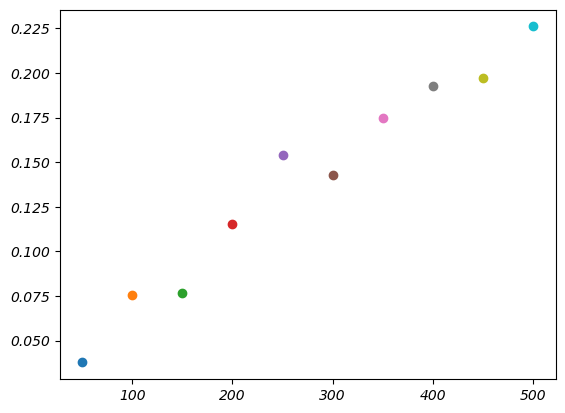

In [13]:
# df['slope_out_normalized'].sort_values().iloc[0:200]
box = 50
Q25 = df.loc[(df['bendHeightBins'] == 50), 'slope_out_normalized'].quantile(0.25)
Q75 = df.loc[(df['bendHeightBins'] == 50), 'slope_out_normalized'].quantile(0.75)
IQR = Q75 - Q25

# df.loc[(df['bendHeightBins'] == 50) & (df['slope_out_normalized'] > (Q75+(IQR*1.5)) ), 'bendHeight']
for E in [50, 100, 150,200,250,300, 350,400,450,500]:
    print(E, df.loc[(df['bendHeightBins'] == E), 'slope_out_normalized'].quantile(0.5))
    plt.plot(E, df.loc[(df['bendHeightBins'] == E), 'slope_out_normalized'].quantile(0.5), marker = 'o')
print()
for E in [50, 100, 150,200,250,300, 350,400,450,500]:
    print(E, df.loc[(df['bendHeightBins'] == E), 'slope_inn_normalized'].quantile(0.5))

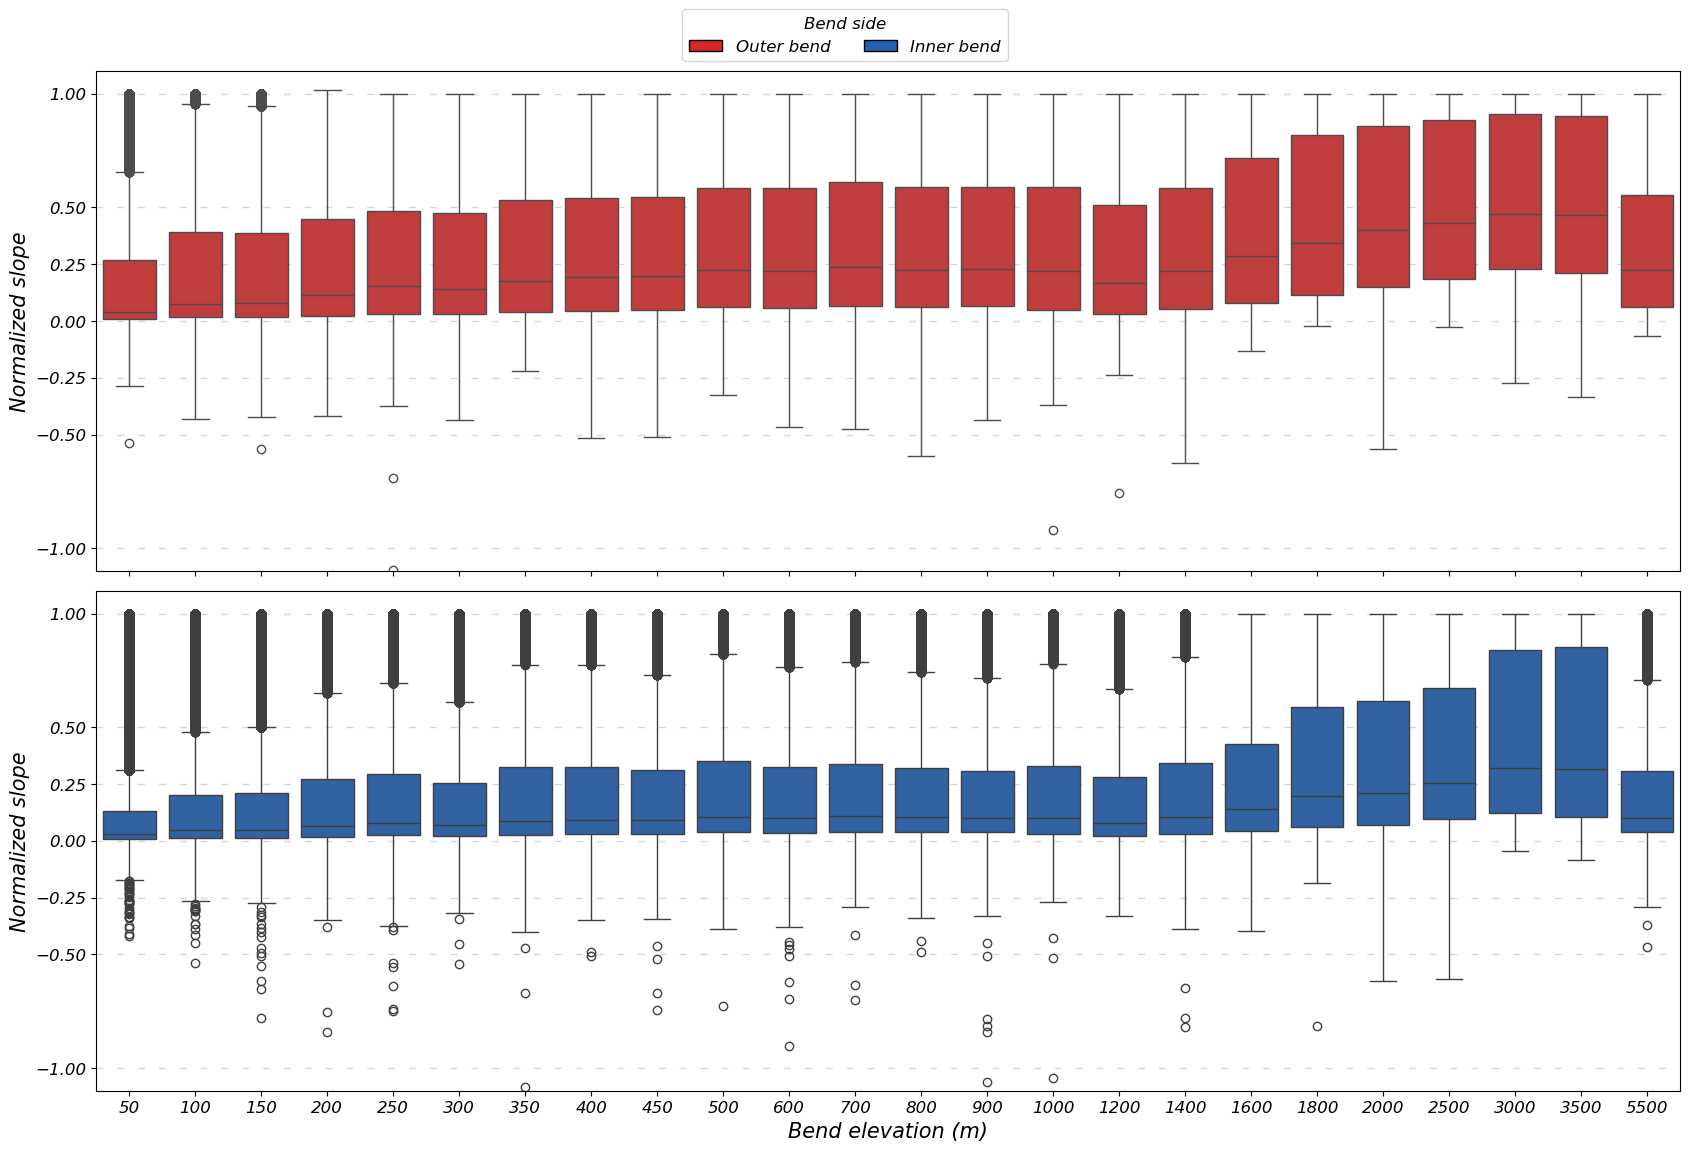

In [28]:
slope_vs_X_boxplots('bendHeightBins', 'elevation')

# ER & slope densities

In [29]:
df['ER_out_log'] = np.log10(df['ER_out'])
df['ER_inn_log'] = np.log10(df['ER_inn'])

df['slope_out_normalized_log'] = np.log10(df['slope_out_normalized'])
df['slope_inn_normalized_log'] = np.log10(df['slope_inn_normalized'])

/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [48]:
dfCluster.loc[dfCluster['ER_out'] == 0.5].shape[0],\
dfCluster.loc[(dfCluster['ER_out'] > 0.5) & (dfCluster['ER_out'] < 0.55)].shape[0]

(83030, 44722)

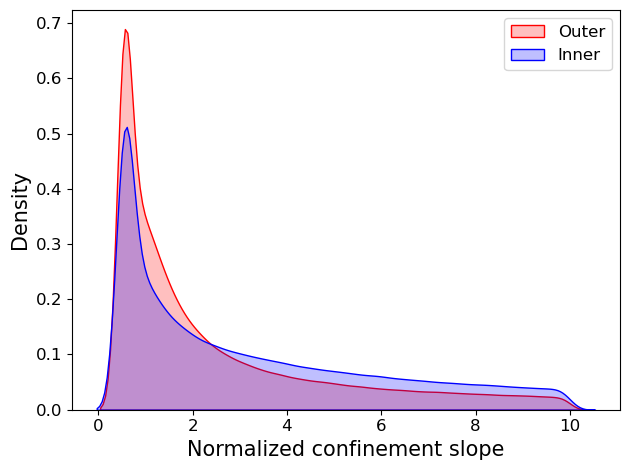

AttributeError: 'NoneType' object has no attribute 'loc'

In [51]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = df[df['ER_out'] < 10],x = 'ER_out', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = df[df['ER_inn'] < 10],x = 'ER_inn', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Normalized confinement slope', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
# plt.axvline(-1.7)
# plt.axvline(-1.5)
# plt.axvline(-1.4)
# plt.axvline(-0.301)
# ax.set_xticks([0.0 ,-2, -1,-0.602, -0.301], [1,0.01, 0.1, 0.25, 0.5])
# plt.xlim([-3.5, 0])
plt.tight_layout()
# plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show().loc[dfCluster['ER_out'] > 0.5,'ER_out'].sort_values()


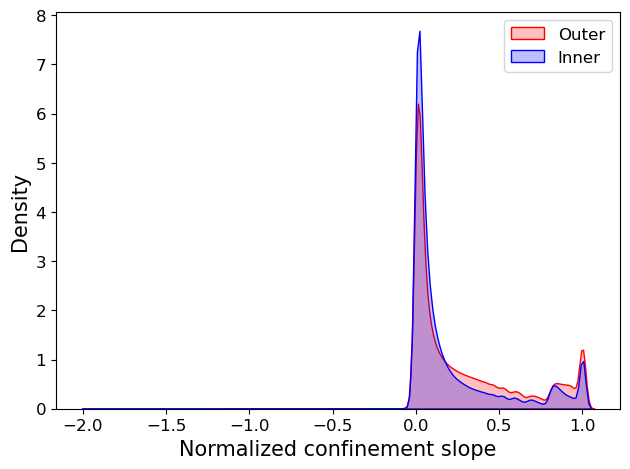

In [46]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = df,x = 'slope_out_normalized', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = df,x = 'slope_inn_normalized', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Normalized confinement slope', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
# plt.axvline(-1.7)
# plt.axvline(-1.5)
# plt.axvline(-1.4)
# plt.axvline(-0.301)
# ax.set_xticks([0.0 ,-2, -1,-0.602, -0.301], [1,0.01, 0.1, 0.25, 0.5])
# plt.xlim([-3.5, 0])
plt.tight_layout()
# plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show()

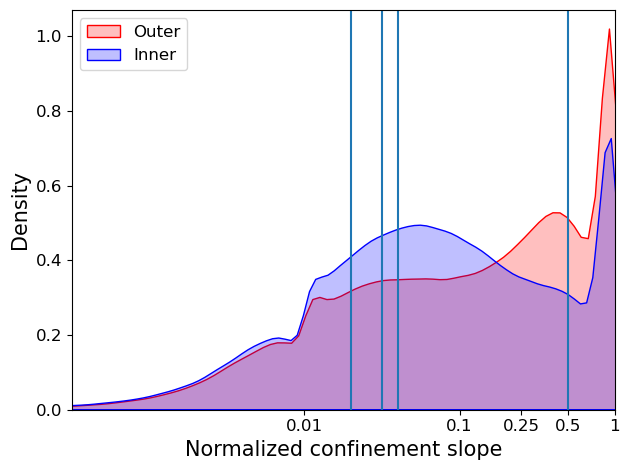

In [39]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = df,x = 'slope_out_normalized_log', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = df,x = 'slope_inn_normalized_log', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Normalized confinement slope', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
plt.axvline(-1.7)
plt.axvline(-1.5)
plt.axvline(-1.4)
plt.axvline(-0.301)
ax.set_xticks([0.0 ,-2, -1,-0.602, -0.301], [1,0.01, 0.1, 0.25, 0.5])
plt.xlim([-3.5, 0])
plt.tight_layout()
# plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show()

In [66]:
10**-2, np.log10(0.1)

(0.01, np.float64(-1.0))

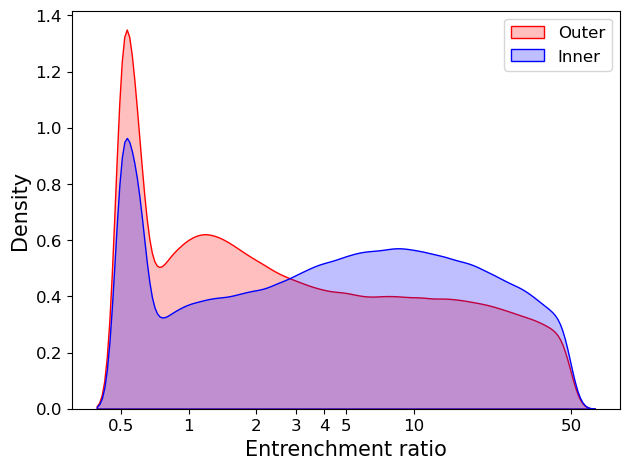

In [79]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = df,x = 'ER_out_log', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = df,x = 'ER_inn_log', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Entrenchment ratio', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)

ax.set_xticks([-0.301 ,0.0 ,0.301 ,0.477 ,0.602 ,0.699 ,1.0, 1.699], [0.5,1,2,3,4,5,10, 50])
plt.tight_layout()
plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/ER_inOut_02_KDE.png', dpi = 1000)
plt.show()

# Compare clusters for different CH

In [3]:
numPCA = 3

In [23]:
slopeCols  = ['slope_out_normalized', 'slope_right_normalized', 'slope_left_normalized', 'slope_inn_normalized']
slopeSCols = ['slope_out_normalized_smooth', 'slope_right_normalized_smooth', 'slope_left_normalized_smooth', 'slope_inn_normalized_smooth']
slopeECols = ['ER_out', 'ER_left', 'ER_inn', 'ER_right']
pcaCols    = [f'PCA{P}' for P in range(1,numPCA+1)]
keepCols   = ['bendID', 'file'] + slopeCols + slopeSCols + slopeECols + pcaCols

In [33]:
CH = 2
L = []
for CH in [2,3,4]:
    df                   = open_dataset_confinement_clustering(CH)
    dfCluster, pca, Xpca = data_prep_clustering(df, slopeCols+slopeSCols,True, 3, False)

    dfT = dfCluster[keepCols]
    changeNameCols = slopeCols + slopeSCols + slopeECols + ['PCA1', 'PCA2', 'PCA3']
    dfT = dfT.rename(columns = {col: col + f'_0{CH}' for col in changeNameCols})
    L.append(dfT)
merged = reduce(lambda left, right: pd.merge(left, right, on=["bendID", "file"]), L)
mergedDS = merged.to_xarray()

ncFile = directory + 'results/single_values/global_50_234_conf.nc'
if os.path.exists(ncFile):
    os.remove(ncFile)
mergedDS.to_netcdf(ncFile)

In [40]:
cluster = 7
for ch in [2]:
    cc     = [c + f'_0{ch}' for c in pcaCols]
    merged = applyGMM(merged, cc, cluster, 'kmeans', 100, 'tied', 10)
    merged = merged.rename(columns={col: col + f'_0{ch}' for col in merged.columns[-cluster:]})

    


# Kmeans clustering

## Cluster distribution

0 3
         index  combined_reach_id     reach_id file      bendLen  \
0            0                0.0  11448000011   af   886.053976   
1            1                0.0  11448000011   af   496.394481   
2            2                0.0  11448000011   af   539.573071   
3            3                0.0  11448000011   af   517.095891   
4            4                0.0  11448000011   af   301.379971   
...        ...                ...          ...  ...          ...   
1490491  17777            15679.0  23281000341   eu  2456.900483   
1490492  17778            15680.0  23281000331   eu  1339.353964   
1490493  17779            15681.0  23281000351   eu  1194.955430   
1490494  17780            15682.0  23285001061   eu  1745.263329   
1490495  17781            15686.0  23286000721   eu  1643.832971   

          up_reach_id  networkGraph  networkGroup river_name  \
0        1.144800e+10             0             0     Ganale   
1        1.144800e+10             0             0  

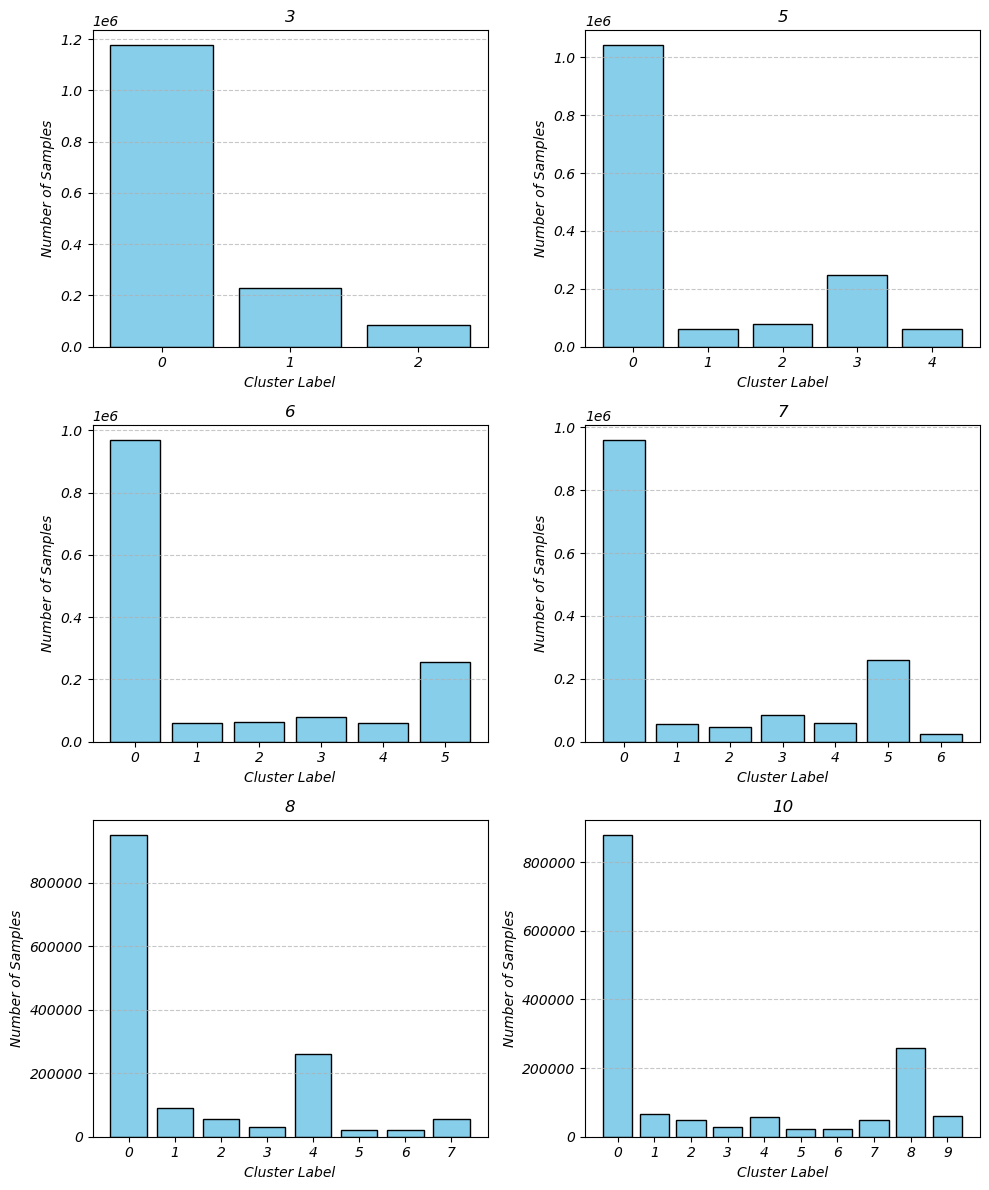

In [59]:
def plot_cluster_histogram(df, clusterCols,C, title="Cluster Distribution"):
    numC = len(C)
    max_cols = 2
    cols = int(min(numC, max_cols))
    rows = int(np.ceil(numC / cols))

    f, ax = plt.subplots(figsize=(5*cols, 4*rows), ncols= cols, nrows = rows, squeeze = False)
    # Ensure axes is a flat iterable array
    if numC == 1:
        ax = np.array([ax])
    else:
        ax = np.array(ax).flatten()
    for i in range(numC):
        print(i, C[i])
        km = applyKmeans(df, clusterCols, C[i])
        unique_labels, counts = np.unique(km[f'kmeans_{C[i]}'], return_counts=True)

        # Optional: sort clusters by label
        sorted_indices = np.argsort(unique_labels)
        unique_labels = unique_labels[sorted_indices]
        counts = counts[sorted_indices]

    
        ax[i].bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
        ax[i].set_xlabel("Cluster Label")
        ax[i].set_ylabel("Number of Samples")
        ax[i].set_title(C[i])
        ax[i].grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.show()

plot_cluster_histogram(dfCluster, pcaCols,[3, 5, 6 ,7, 8, 10])

## Plot and check clusters

### KDE

In [37]:
def apply_kde(df, cols):

    x = df[cols[0]].values
    y = df[cols[1]].values


    kdeT = dfCluster[cols].dropna().to_numpy()
    cov = np.cov(kdeT.T)
    if np.linalg.cond(cov) > 1e10:
        print(f'Linear relationship')
        print(np.linalg.cond(cov))
        lin = True
    else:
        lin = False
    # Compute 2D KDE
    values = np.vstack([x, y])
    kde    = gaussian_kde(values)

    # Evaluate on a grid
    xmin, xmax = x.min()-1, x.max()+1
    ymin, ymax = y.min()-1, y.max()+1
    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200),
                    np.linspace(ymin, ymax, 200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z         = np.reshape(kde(positions), X.shape)

    # Minimum density threshold
    # min_density = 0.0001  # skip contours below this
    # Mask low densities
    # Z_masked = np.where(Z < min_density, np.nan, Z)
    # print(Z_masked)
    return X, Y, Z, lin

In [10]:
dfCluster = applyKmeans(dfCluster, ['PCA1', 'PCA2', 'PCA3'], 7)

In [39]:
vars = ['slope_out_normalized', 'slope_inn_normalized', 'slope_left_normalized', 'slope_right_normalized']

In [46]:
kdeVal = []
cluster = 7
for vars in [[vars[0], vars[2]]]:
    for c in range(cluster):
        val = apply_kde(dfCluster[dfCluster[f'kmeans_{cluster}']== c],
                        vars)
        kdeVal.append(list(val) + vars + [c])
dfKDE = pd.DataFrame(kdeVal, columns = ['X', 'Y', 'Z','lin_rel', 'var1', 'var2', 'cluster', ])

In [101]:
vars[['X', 'Y']]

,X,Y
6,"[[-0.650464584624409, -0.6370700004365211, -0....","[[-0.6461136508091766, -0.6461136508091766, -0..."


In [104]:
vars = dfKDE.loc[(dfKDE['cluster'] == 6) & 
                (dfKDE['var1'] == 'slope_out_normalized') & 
                (dfKDE['var2'] == 'slope_left_normalized'), ['X', 'Y', 'Z']]

kdeT = dfCluster[['slope_out_normalized', 'slope_left_normalized']].dropna().to_numpy()
cov = np.cov(kdeT.T)

if np.linalg.cond(cov) > 1e10:
    print(f'Linear relationship between axis ({xaxis}, {yaxis}): {label}')
    print(np.linalg.cond(cov))
    print()

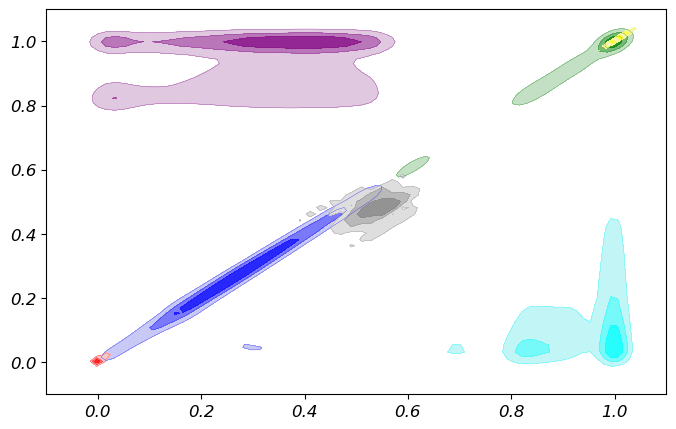

In [82]:
def kdePlot(vars, ax, xlim = False, ylim = False, xlab = '', ylab = ''):
    if isinstance(ax, bool):
        f, ax = plt.subplots(figsize = [8,5])

    X,Y,Z = vars
    Z_min = np.nanmin(Z)
    Z_max = np.nanmax(Z)
    n_levels = 5
    levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
    # if all(levels == 0):
    #     break
    # print(c, levels)
    # Filled contours (shades of one color)
    cmap = sns.light_palette(colors[c], as_cmap=True)
    cf = ax.contourf(X, Y, Z, levels=levels[1:], cmap=cmap)

    # Contour lines (single color, skip lowest)
    cs = ax.contour(X, Y, Z, levels=levels[1:], colors=colors[c], linewidths=0.2)

    if not isinstance(xlim, bool):
        ax.set_xlim(xlim)
    if not isinstance(ylim, bool):
        ax.set_ylim(ylim)
    
    ax.set_xlabel(xlab, fontsize = labelSize)
    ax.set_ylabel(ylab,fontsize = labelSize)
    ax.tick_params(axis='both', which='major', labelsize=tickSize)
    if isinstance(ax, bool):
        plt.tight_layout()
        plt.show()

f,ax = plt.subplots(figsize = [8,5], squeeze = False, nrows = 1)
ax = ax.flatten()
for c in range(7):
    row = dfKDE.loc[(dfKDE['cluster'] == c) & 
                (dfKDE['var1'] == 'slope_out_normalized') & 
                (dfKDE['var2'] == 'slope_left_normalized')].iloc[0]
    kdePlot(row[['X', 'Y', 'Z']], ax[0], [-0.1,1.1], [-0.1,1.1])
plt.show()

In [ ]:
# def kdePlot1D():


def kdePlot2D():
    

In [ ]:
axisRange = {'sin':       [1,2],
             'ang':       [-0.001,0.01],
             'dimApex':   [0,15],
             'widthRatio':[0.2,1.1]}

axisLabels = {'sin':       'Sinuosity',
             'ang':       'Curvature',
             'dimApex':   'Amplitude',
             'widthRatio': 'Braiding index'}

colors = ['blue', 'green', 'red', 'gray', 'purple', 'cyan', 'yellow', 'orange']
f,ax = plt.subplots(ncols = 2, nrows = 3, figsize = [12,12])
ax = ax.flatten()
for i, comb in enumerate(combs):
    print(comb)
    for c in range(clusters):
        X, Y, Z = kde_list[i][c]
        # Define contour levels ABOVE min_density
        Z_min = np.nanmin(Z)
        Z_max = np.nanmax(Z)
        n_levels = 5
        levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
        if all(levels == 0):
            continue
        # print(c, levels)
        # Filled contours (shades of one color)
        cmap = sns.light_palette(colors[c], as_cmap=True)
        cf = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap)

        # Contour lines (single color, skip lowest)
        cs = ax[i].contour(X, Y, Z, levels=levels[1:], colors=colors[c], linewidths=0.2)
        ax[i].set_xlim(axisRange[comb[0]])
        ax[i].set_ylim(axisRange[comb[1]])
        ax[i].set_xlabel(axisLabels[comb[0]], fontsize = labelSize)
        ax[i].set_ylabel(axisLabels[comb[1]],fontsize = labelSize)
        ax[i].tick_params(axis='both', which='major', labelsize=tickSize)
        # Scatter original points
        # ax.scatter(x, y, s=10, facecolor="white", edgecolor="k", alpha=0.6)

        # Axes and grid
        # ax.set_facecolor("white")
        # ax.grid(True, linestyle="--", alpha=0.5)

        # Colorbar
        # fig.colorbar(cf, ax=ax, label="Density")

# Create legend handles manually (to ensure one instance of each label)
handles = [Patch(color=colors[i], label=group) for i, group in enumerate(np.arange(len(colors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=8,
    frameon=False,
    title = 'Clusters',
    title_fontsize = labelSize
)
plt.tight_layout()
plt.savefig(directory + 'results/figures/morphology_clustering_8.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 2000)
plt.show()

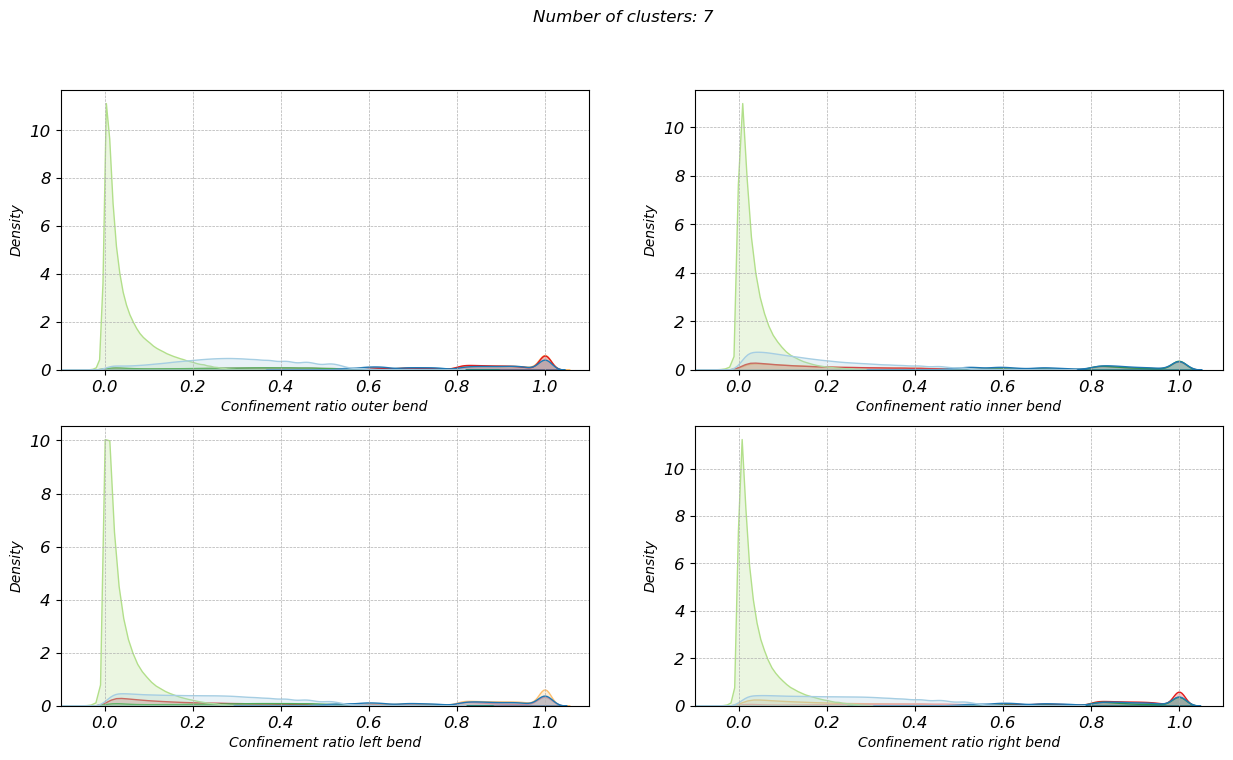

In [ ]:
x = ['slope_out_normalized', 'slope_inn_normalized', 'slope_left_normalized', 'slope_right_normalized']
xl = ['outer', 'inner', 'left', 'right']
count = 0
clusters = [7]
for cluster in clusters:
    count = 0
    f, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [15, 8])

    for i in range(2):
        for j in range(2):
            X = x[count]
            data = dfCluster.copy().dropna(subset =X)
            # Note: We plot KDE of log(data), then convert axes to log-log
            L = sns.kdeplot(data = data, x = X, ax=axs[i,j], fill=True, hue = f'KMeans_pca_{cluster}', palette = sns.color_palette('Paired',cluster), legend = False)
            axs[i,j].set_xlabel(f'Confinement ratio {xl[count]} bend', fontsize = 10)
            axs[i,j].grid(True, which="both", ls="--", lw=0.5)
            axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
            # axs[i,j].set_ylim([0,0.1])
            axs[i,j].set_xlim([-0.1,1.1])
        
            
            count +=1
    f.suptitle(f'Number of clusters: {cluster}')
    plt.savefig(directory + f'results/figures/KDE_{cluster}_{X}_slope.png')
    plt.show()

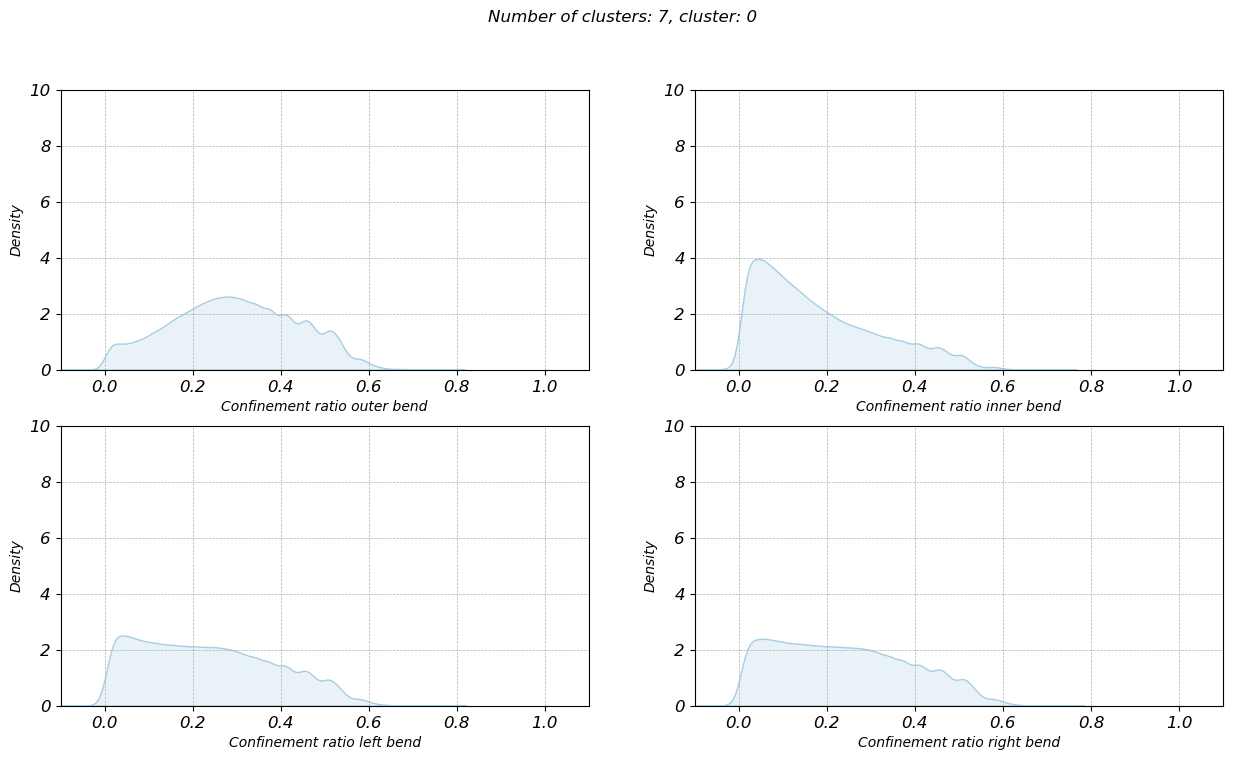

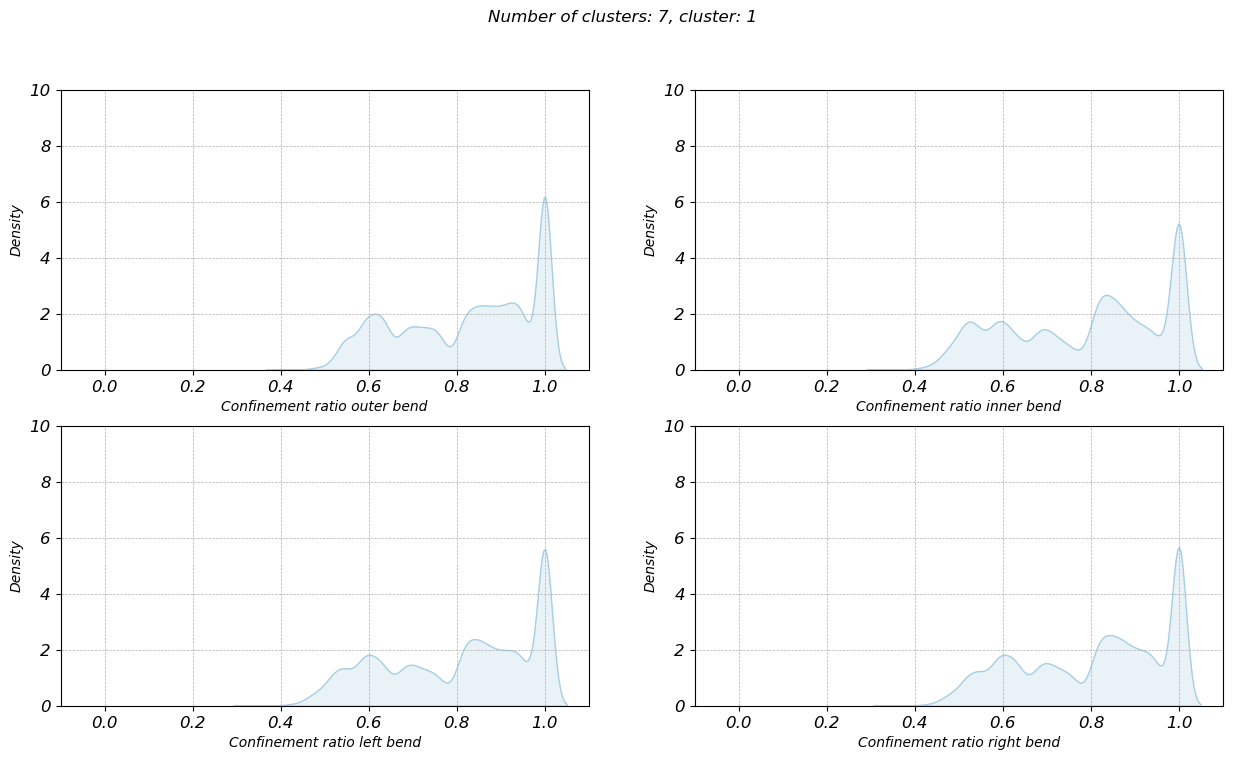

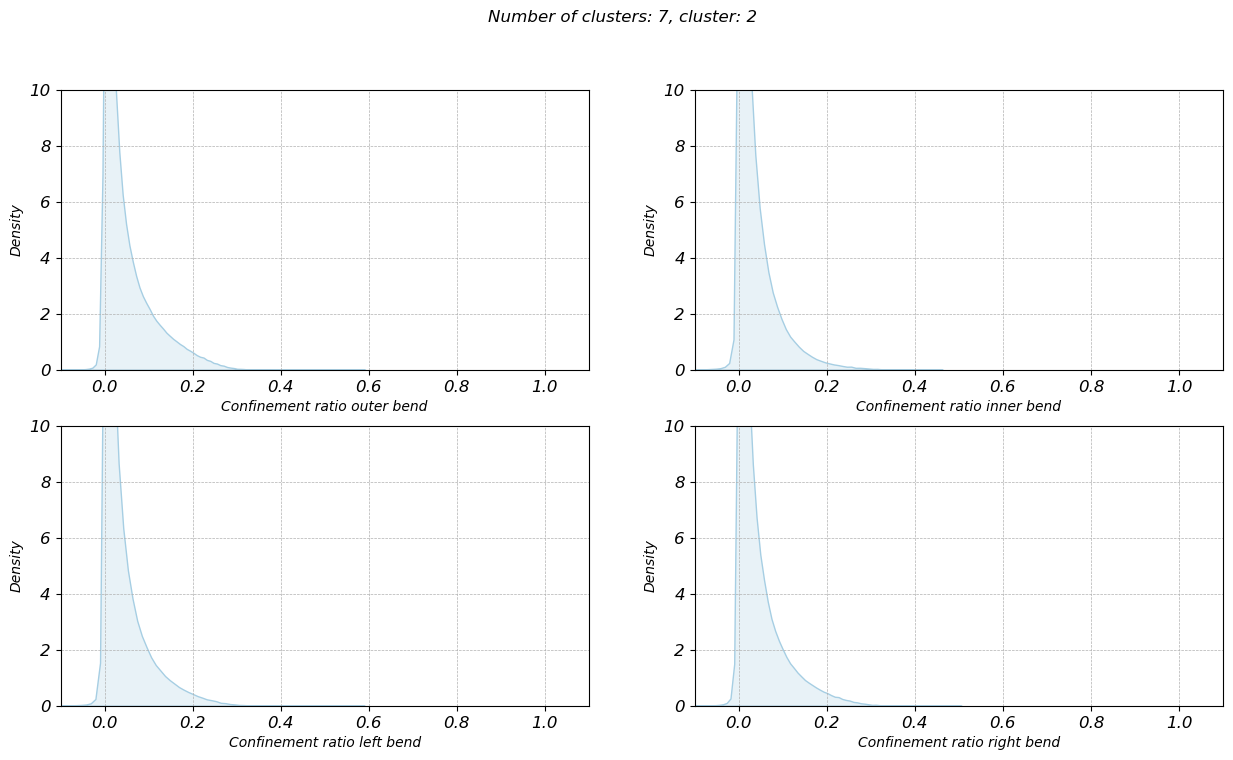

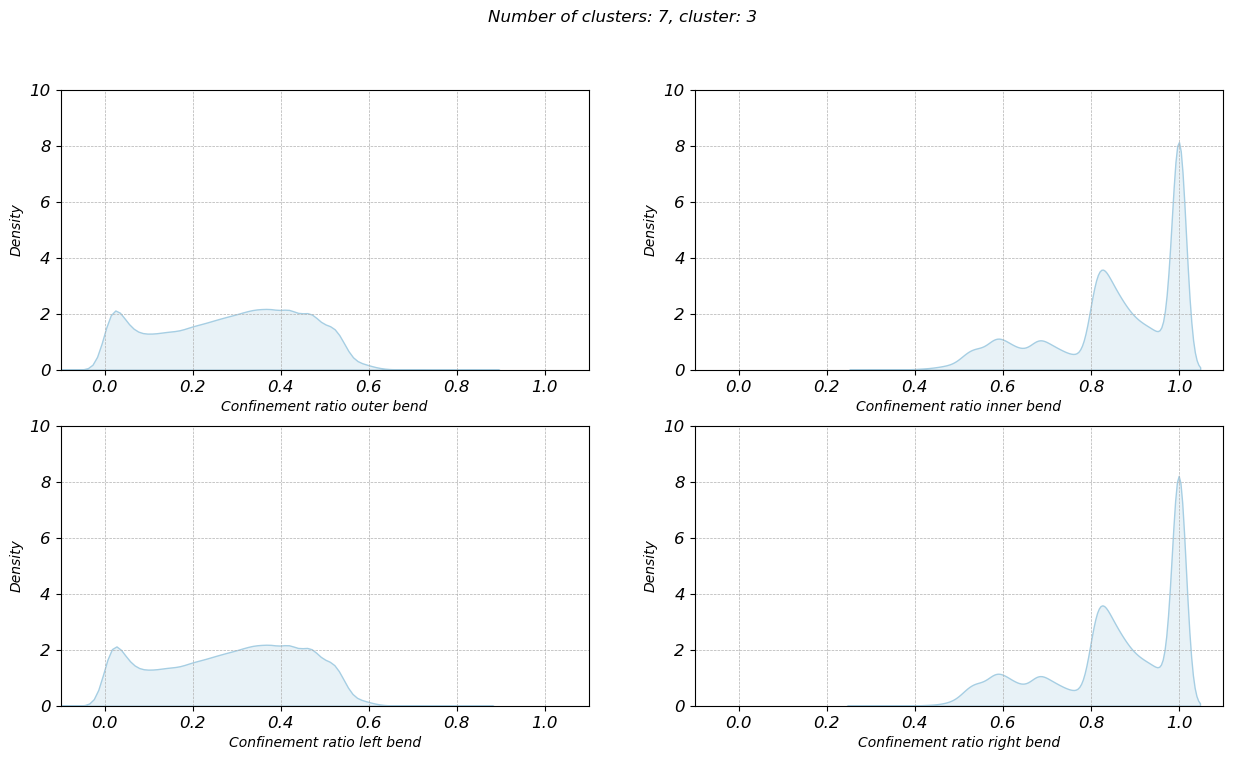

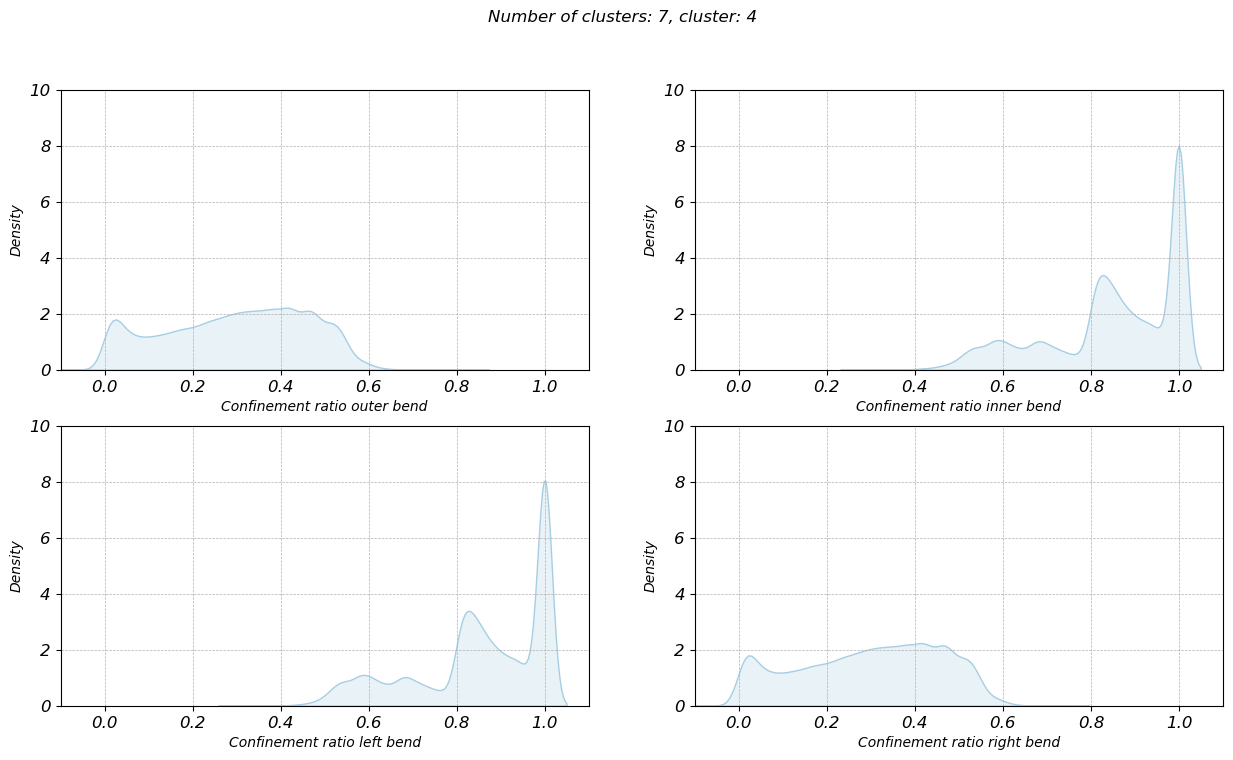

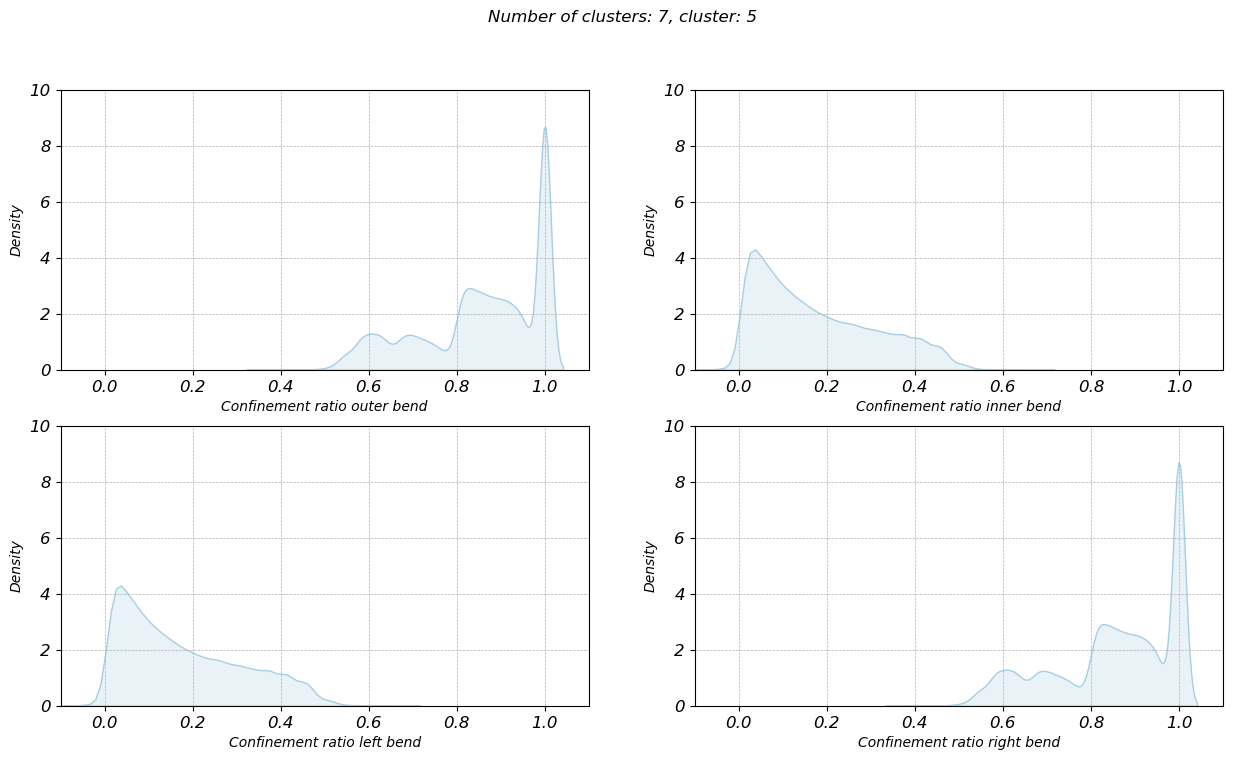

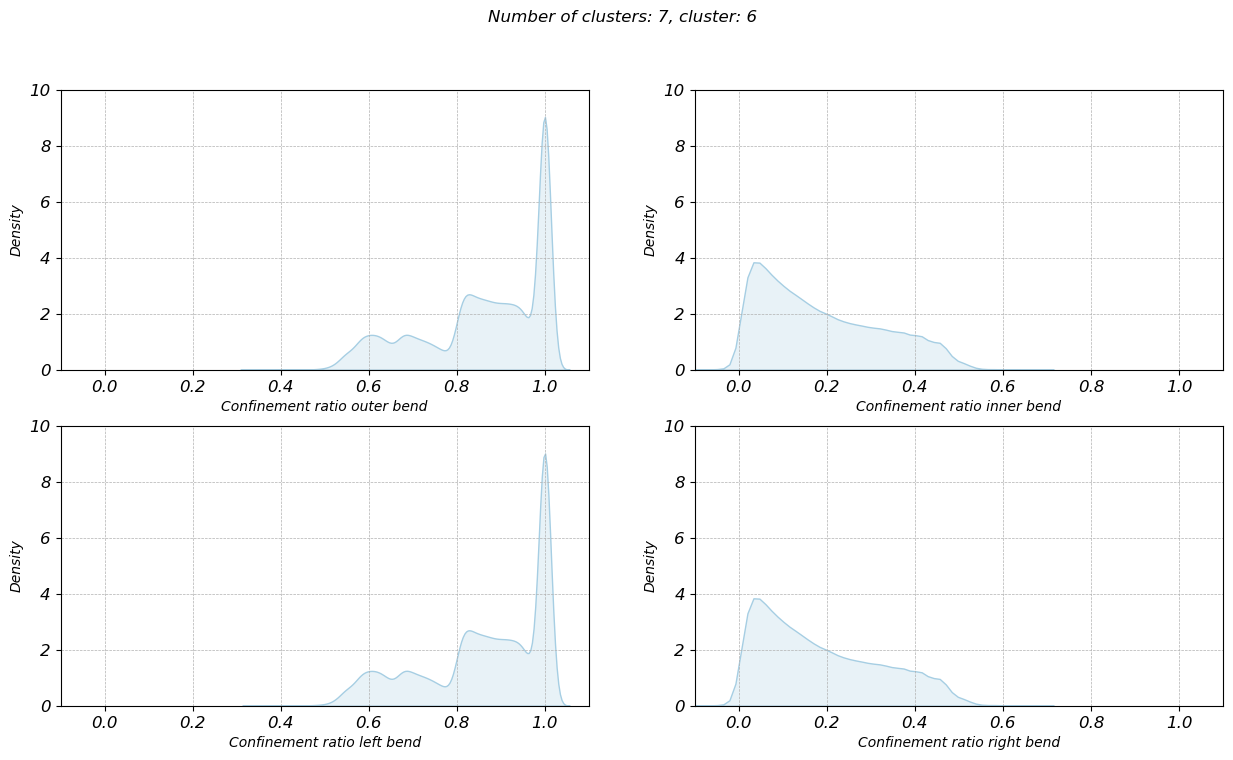

In [ ]:
x = ['slope_out_normalized', 'slope_inn_normalized', 'slope_left_normalized', 'slope_right_normalized']
xl = ['outer', 'inner', 'left', 'right']
count = 0
cluster = 7
for clusterVal in range(cluster):

    f, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [15, 8])
    count =0
    for i in range(2):
        for j in range(2):
            X = x[count]
            data = dfCluster.copy().dropna(subset =X)
            data = data[data[f'KMeans_pca_{cluster}'] == clusterVal]
            # Note: We plot KDE of log(data), then convert axes to log-log
            L = sns.kdeplot(data = data, x = X, ax=axs[i,j], fill=True, hue = f'KMeans_pca_{cluster}', palette = sns.color_palette('Paired',1), legend = False)
            axs[i,j].set_xlabel(f'Confinement ratio {xl[count]} bend', fontsize = 10)
            axs[i,j].grid(True, which="both", ls="--", lw=0.5)
            axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
            axs[i,j].set_ylim([0,10])
            axs[i,j].set_xlim([-0.1,1.1])
        
            
            count +=1
    f.suptitle(f'Number of clusters: {cluster}, cluster: {clusterVal}')
    plt.savefig(directory + f'results/figures/KDE_{cluster}_{X}_{clusterVal}.png')
    plt.show()

# GMM

In [8]:
clusters = 7

In [9]:
dfCluster = applyGMM(dfCluster, ['PCA1', 'PCA2', 'PCA3'], clusters, 'kmeans', 100, 'tied', 5)

In [10]:
cols_of_interest = [col for col in dfCluster.columns if col.startswith(f"GMM_{clusters}_") and col.endswith("_soft")]
for thres in [0.9,0.95,0.99]:
    dfCluster.loc[dfCluster[cols_of_interest].max(axis=1) >= thres, f'GMM_{clusters}_{int(thres*100)}'] = dfCluster[f'GMM_{clusters}_hard']


In [11]:
c = [[0], [1,3,4,6], [2], [5]]
names = ['Unconfined', 'Asymmetrical', 'Confined', 'Symmetrical']
for i in range(len(c)):
    dfCluster.loc[dfCluster['GMM_7_hard'].isin(c[i]), 'clusters'] = names[i]
# unc = dfCluster[dfCluster['GMM_7_hard'] == 0]
# asym = dfCluster[dfCluster['GMM_7_hard'].isin([1,3,4,6])]
# conf = dfCluster[dfCluster['GMM_7_hard'] == 2]
# sym = dfCluster[dfCluster['GMM_7_hard'] == 5]

In [18]:
dfC = pd.read_csv('/Volumes/PhD/confinement/results/dfClusterSlope.csv')

In [16]:
names = ['Unconfined', 'Asymmetrical', 'Confined', 'Symmetrical']
dfP = dfCluster[(dfCluster['slope'] > 0.00000001) & (dfCluster['slope']< 2)]


In [ ]:
dfC = pd.read_csv('/Volumes/PhD/confinement/results/dfClusterSlope.csv')

Unconfined 1.99999490922001
Asymmetrical 1.99999490922001
Confined 1.9996691438256065
Symmetrical 1.99999490922001


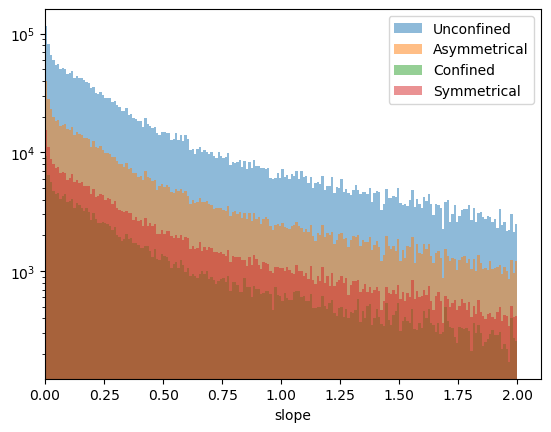

In [19]:

for n in names:
    D = dfP.loc[dfP['clusters'] == n, 'slope']
    print(n, D.max())
    plt.hist(D, bins = 200, alpha = 0.5, label = n)
plt.yscale('log')
plt.xlim(left = 0)
plt.xlabel('slope')
plt.legend()
plt.show()

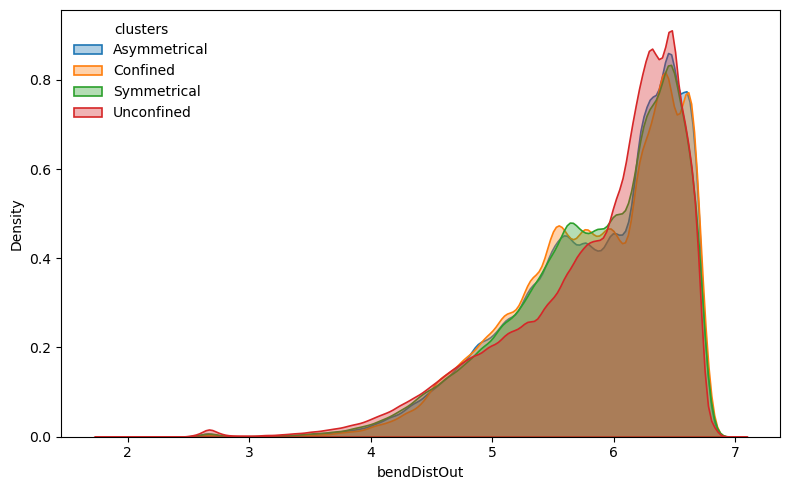

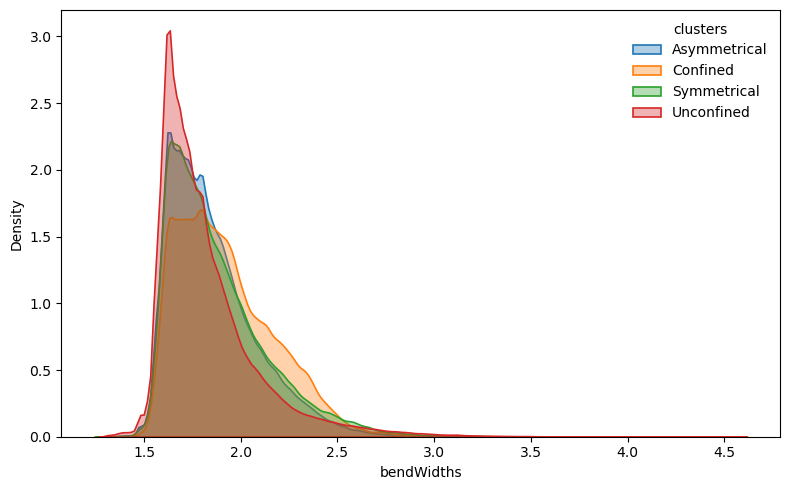

/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/pyth

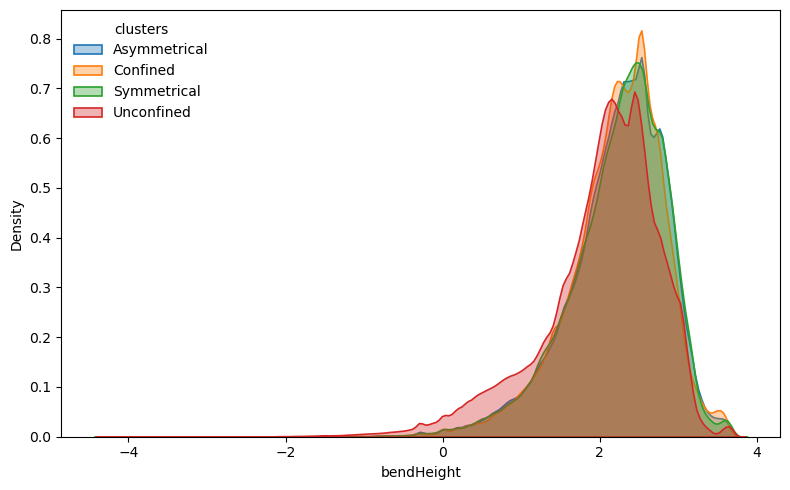

/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/RivAlg11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


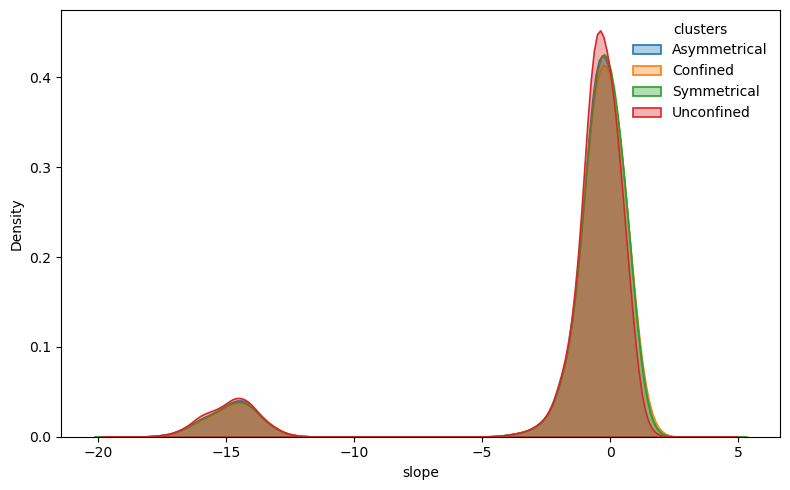

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_kde_4groups(df, cluster_col="clusters", xcol="bendWidths"):
    # keep only 4 groups (assumes exactly 4 unique values)
    groups = sorted(df[cluster_col].dropna().unique())[:4]

    plt.figure(figsize=(8, 5))
    for g in groups:
        d = df[df[cluster_col] == g].copy()
        d[xcol] = np.log10(d[xcol])
        sns.kdeplot(
            data=d,
            x=xcol,
            fill=True,
            alpha=0.35,
            linewidth=1.2,
            label=str(g)
        )
    # plt.xlim('')
    plt.xlabel(xcol)
    plt.ylabel("Density")
    plt.legend(title=cluster_col, frameon=False)
    plt.tight_layout()
    plt.show()

# usage
plot_kde_4groups(dfC, cluster_col="clusters", xcol="bendDistOut")
plot_kde_4groups(dfC, cluster_col="clusters", xcol="bendWidths")
plot_kde_4groups(dfC, cluster_col="clusters", xcol="bendHeight")
plot_kde_4groups(dfC, cluster_col="clusters", xcol="slope")


Unconfined 38034.46621622
Asymmetrical 16367.51388889
Confined 7162.48465704
Symmetrical 9744.15789474


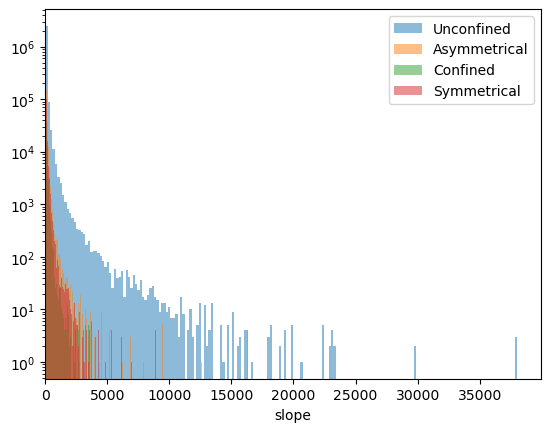

In [20]:

for n in names:
    D = dfP.loc[dfP['clusters'] == n, 'bendWidths']
    print(n, D.max())
    plt.hist(D, bins = 200, alpha = 0.5, label = n)
plt.yscale('log')
plt.xlim(left = 0)
plt.xlabel('slope')
plt.legend()
plt.show()

Unconfined 5042.00732422
Asymmetrical 5021.30273438
Confined 4688.58789062
Symmetrical 4944.69580078


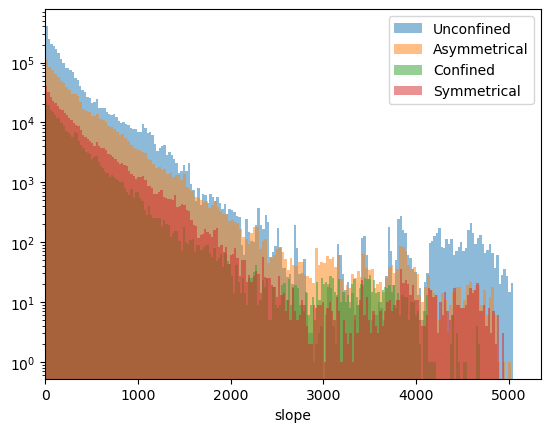

In [21]:

for n in names:
    D = dfP.loc[dfP['clusters'] == n, 'bendHeight']
    print(n, D.max())
    plt.hist(D, bins = 200, alpha = 0.5, label = n)
plt.yscale('log')
plt.xlim(left = 0)
plt.xlabel('slope')
plt.legend()
plt.show()

In [ ]:
var = 'bendWidths' 
unc[var].median(), asym[var].median(), conf[var].median(), sym[var].median()

var = 'bendHeight' 
unc[var].median(), asym[var].median(), conf[var].median(), sym[var].median()

plt.hist(unc)

(np.float64(140.97264862499998),
 np.float64(239.20788574),
 np.float64(247.52038574),
 np.float64(241.09236145))

In [12]:
files = glob('/Volumes/PhD/confinement/results/single_values/*.csv')
for i, f in tqdm(enumerate(files), total = len(files)):
    dfT = gpd.read_file(f)
    dfT['combined_reach_id'] = dfT['combined_reach_id'].astype(float)
    dfT['slope'] = dfT['slope'].astype(float)
    s = dfT.groupby('combined_reach_id', as_index = False)['slope'].mean()
    if i == 0:
        dft = s
    else:
        dft = pd.concat([dft, s])

dfCluster = dfCluster.merge(dft[['combined_reach_id', 'slope']], how = 'left', on = 'combined_reach_id')

100%|██████████| 43/43 [11:07<00:00, 15.51s/it]


In [15]:
dfCluster.to_csv('/Volumes/PhD/confinement/results/dfClusterSlope.csv')

In [92]:
dfCluster = dfCluster.drop(['slope', 'slope_x', 'slope_y'], axis = 1)

In [93]:
dfCluster = dfCluster.merge(dft[['combined_reach_id', 'slope']], how = 'left', on = 'combined_reach_id')

### Distribution

In [96]:
unique_labels

array([ 0.,  1.,  2.,  5., nan])

/var/folders/bs/xx1t3fn91jl3k26fn1pndd_c0000gn/T/ipykernel_53422/4294705174.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labels[labels == 4] = 1
/var/folders/bs/xx1t3fn91jl3k26fn1pndd_c0000gn/T/ipykernel_53422/4294705174.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labels[labels == 6] = 1
/var/folders/bs/xx1t3fn91jl3k26fn1pndd_c0000gn/T/ipykernel_53422/4294705174.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labels

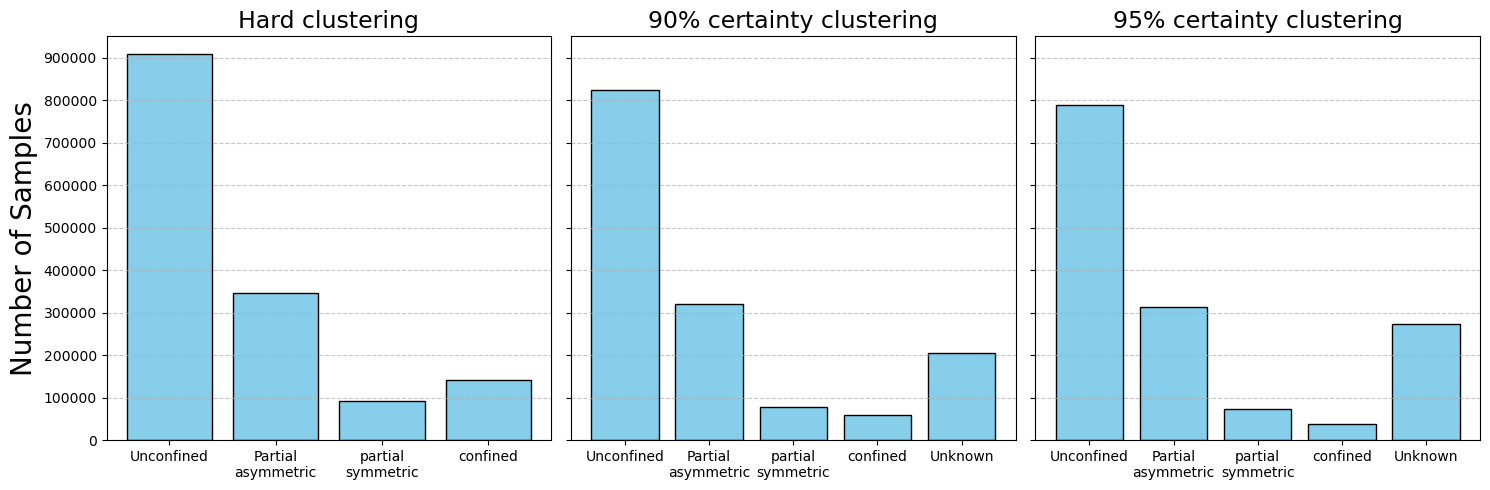

In [99]:
i = 0
levels = ['hard', '90', '95']
f,ax =plt.subplots(ncols = len(levels), nrows = 1, squeeze = False, figsize = [15,5], sharey =True)

titles = ['Hard clustering', '90% certainty clustering', '95% certainty clustering', '99% certainty clustering']
for i in range(len(levels)):
    labels = dfCluster[f'GMM_{clusters}_{levels[i]}']
    labels[labels == 4] = 1
    labels[labels == 6] = 1
    labels[labels == 3] = 1
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # Optional: sort clusters by label
    sorted_indices = np.argsort(unique_labels)
    unique_labels = unique_labels[sorted_indices]
    counts = counts[sorted_indices]

    if levels[i] == 'hard':
        unique_labels = ['Unconfined', 'Partial\nasymmetric', 'partial\nsymmetric', 'confined']
    else:
        unique_labels = ['Unconfined', 'Partial\nasymmetric', 'partial\nsymmetric', 'confined', 'Unknown']
    ax[0,i].bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
    ax[0,i].set_yticks(np.arange(0, 1.2e6, 1e5))
    # ax[0,i].set_xlabel("Cluster Label", fontsize = labelSize)
    
    ax[0,i].set_title(titles[i], fontsize = 17)
    ax[0,i].grid(axis='y', linestyle='--', alpha=0.7)
    ax[0,i].set_ylim(0,950000)
ax[0,0].set_ylabel("Number of Samples", fontsize = labelSize)
plt.tight_layout()
plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/GMM_7_hist.png')
plt.show()

### KDE per cluster

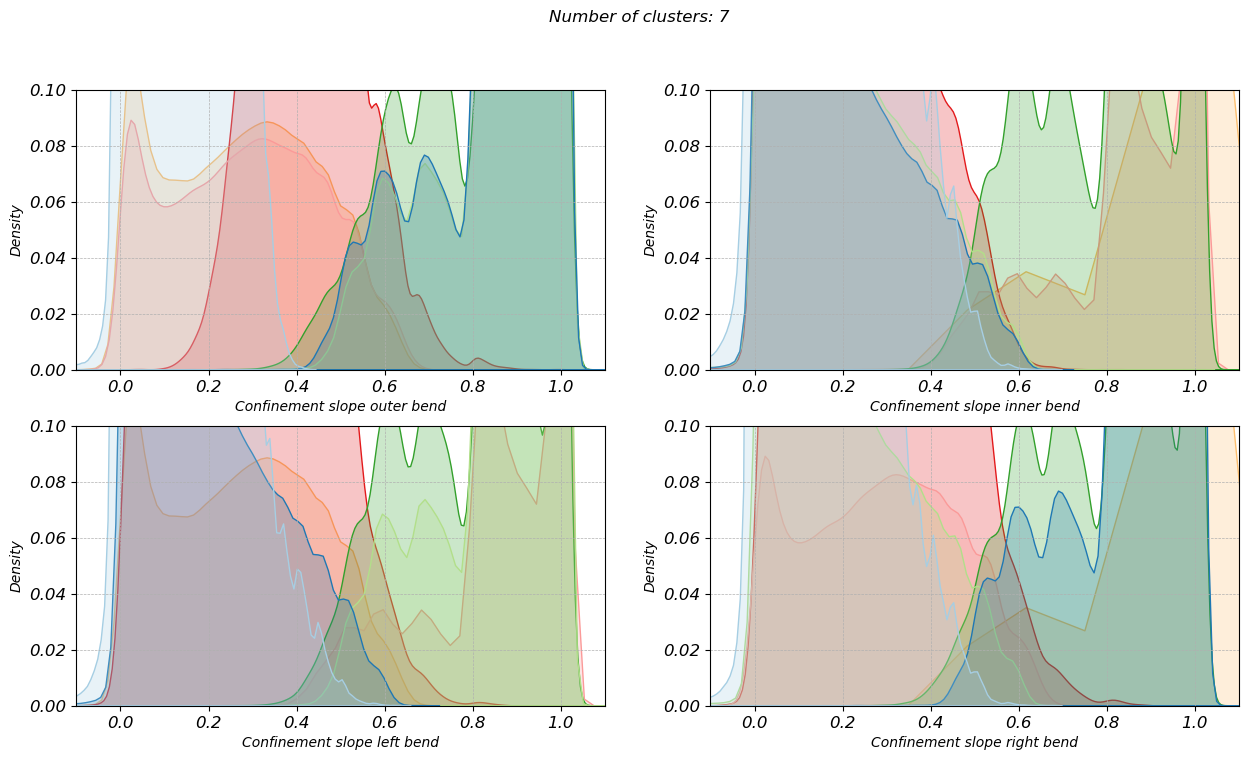

In [ ]:
x = ['slope_out_normalized', 'slope_inn_normalized', 'slope_left_normalized', 'slope_right_normalized']
xl = ['outer', 'inner', 'left', 'right']
count = 0
clusters = [9]
for cluster in clusters:
    count = 0
    f, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [15, 8])

    for i in range(2):
        for j in range(2):
            X = x[count]
            data = dfCluster.copy().dropna(subset =X)
            # Note: We plot KDE of log(data), then convert axes to log-log
            L = sns.kdeplot(data = data, x = X, ax=axs[i,j], fill=True, hue = f'GMM_pca_{cluster}_hard', palette = sns.color_palette('Paired',cluster), legend = False)
            axs[i,j].set_xlabel(f'Confinement slope {xl[count]} bend', fontsize = 10)
            axs[i,j].grid(True, which="both", ls="--", lw=0.5)
            axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
            axs[i,j].set_ylim([0,0.1])
            axs[i,j].set_xlim([-0.1,1.1])
        
            
            count +=1
    f.suptitle(f'Number of clusters: {cluster}')
    # plt.savefig(directory + f'results/figures/KDE_{cluster}_{X}_slope.png')
    plt.show()

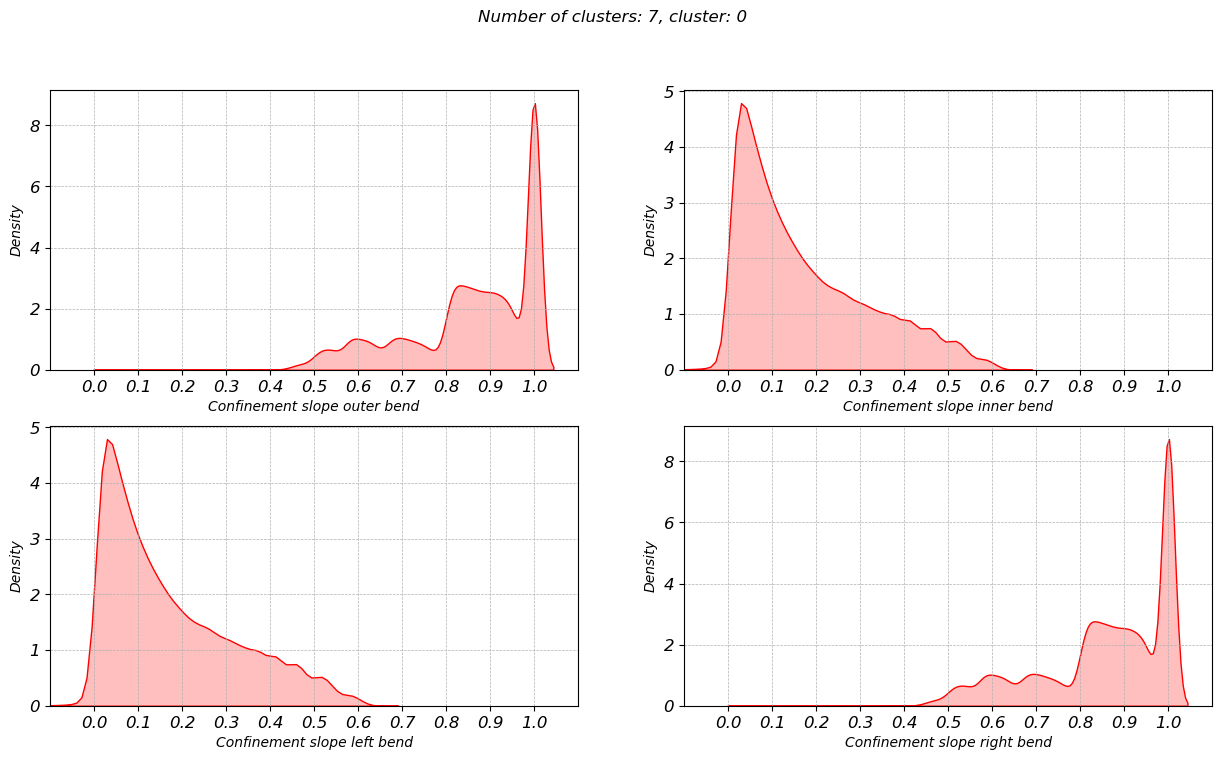

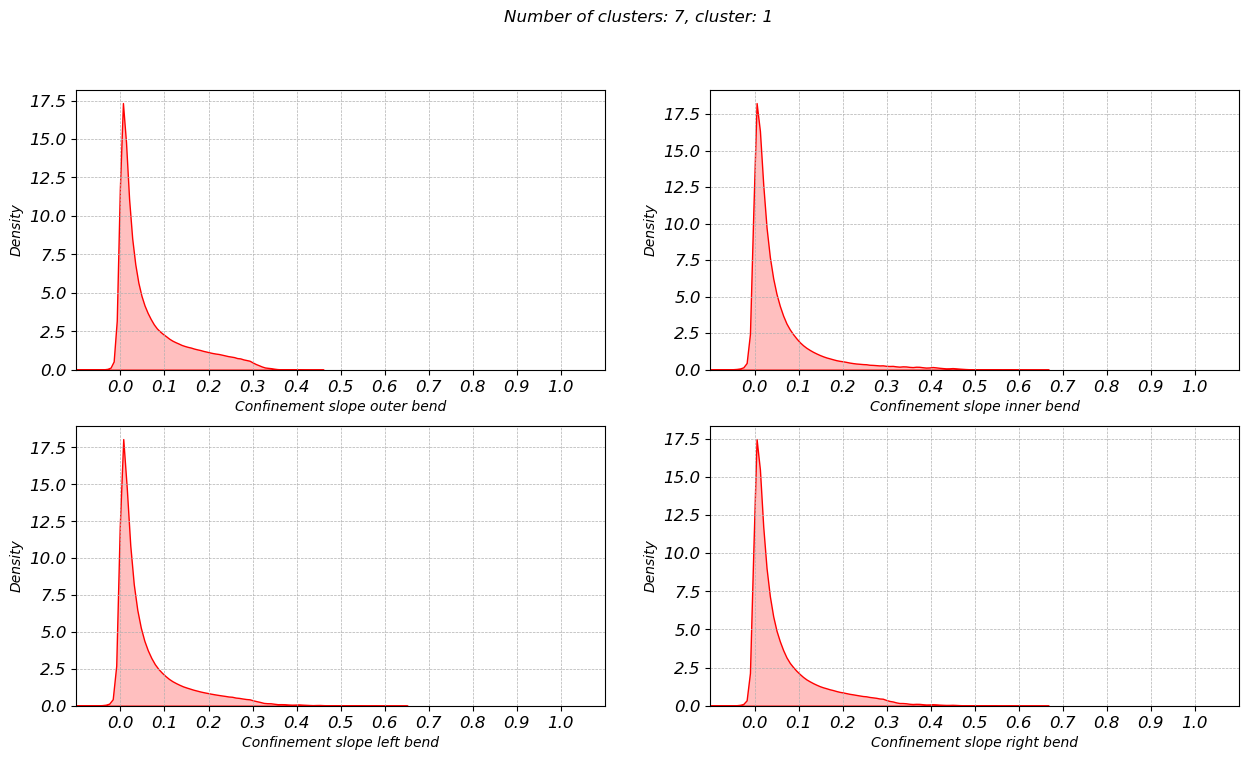

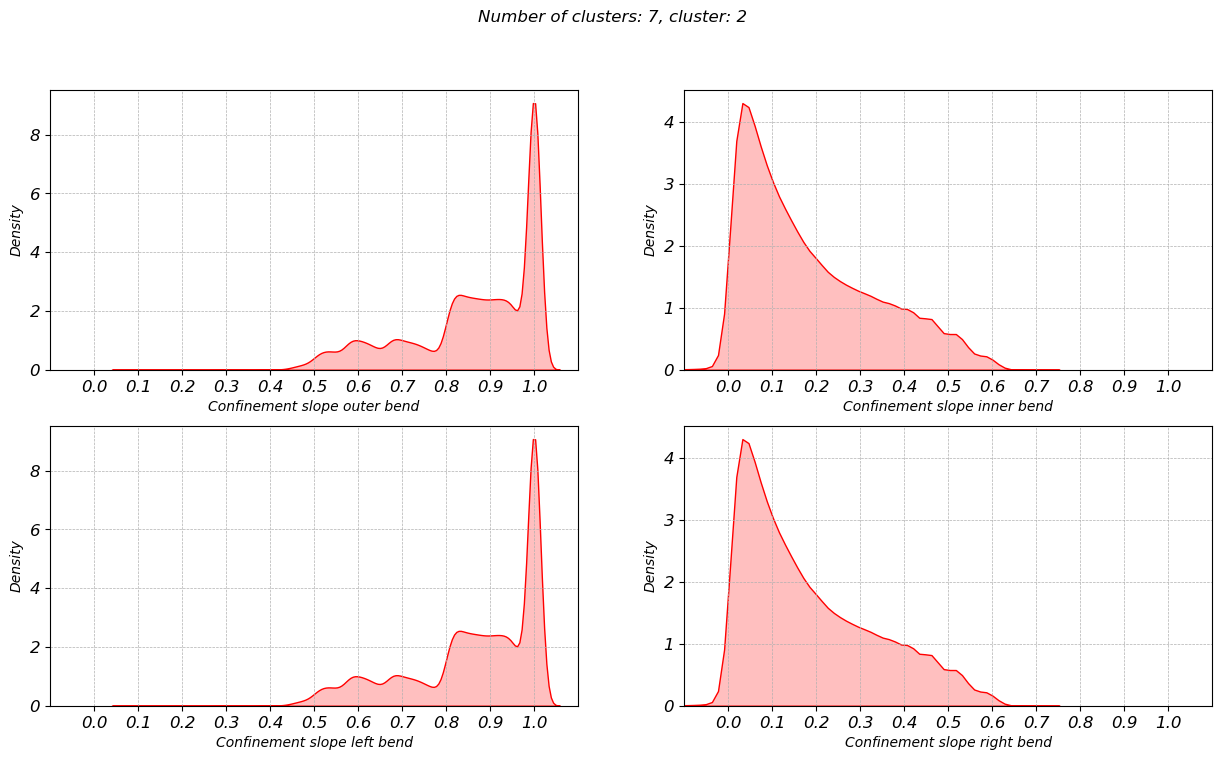

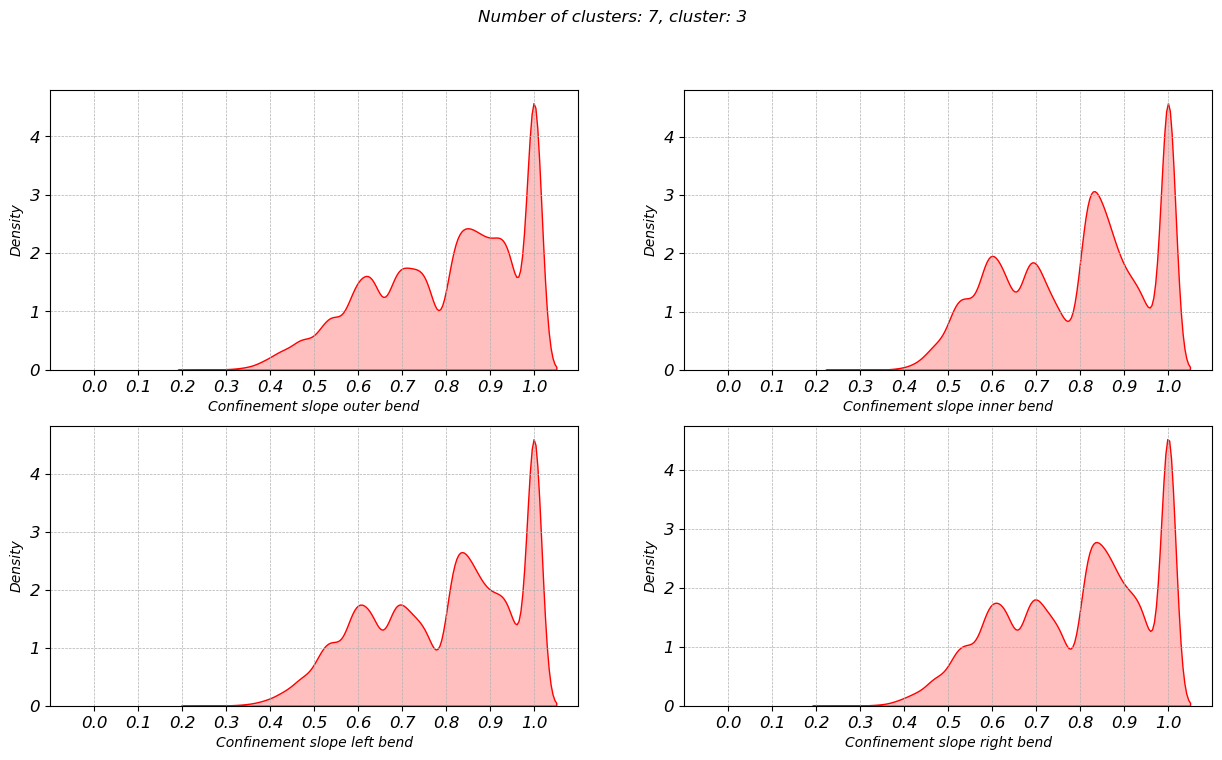

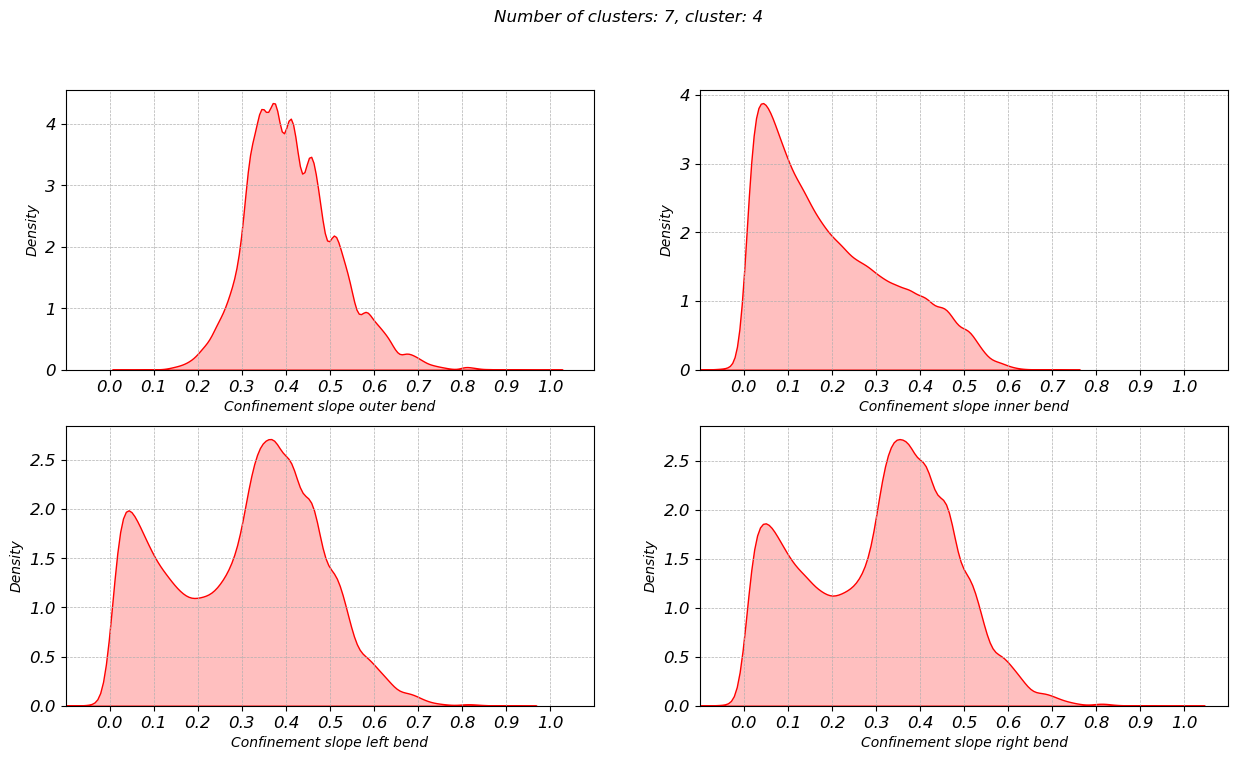

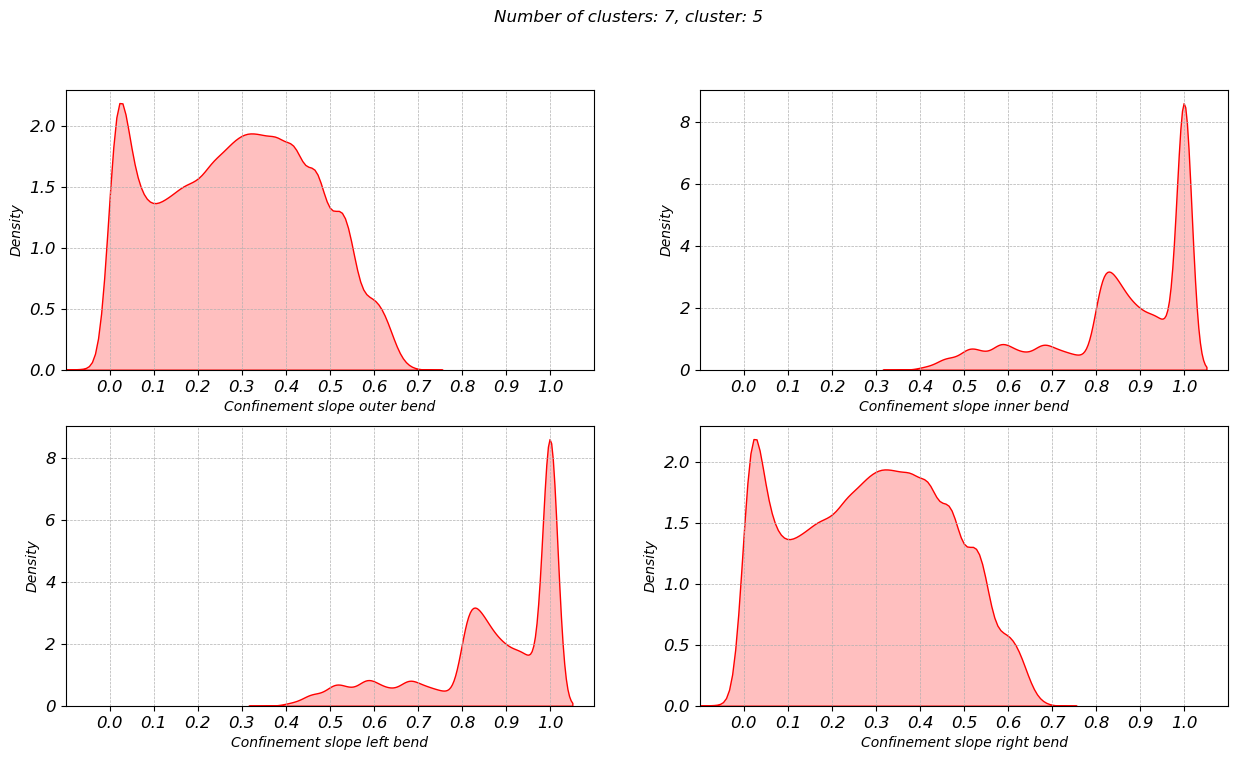

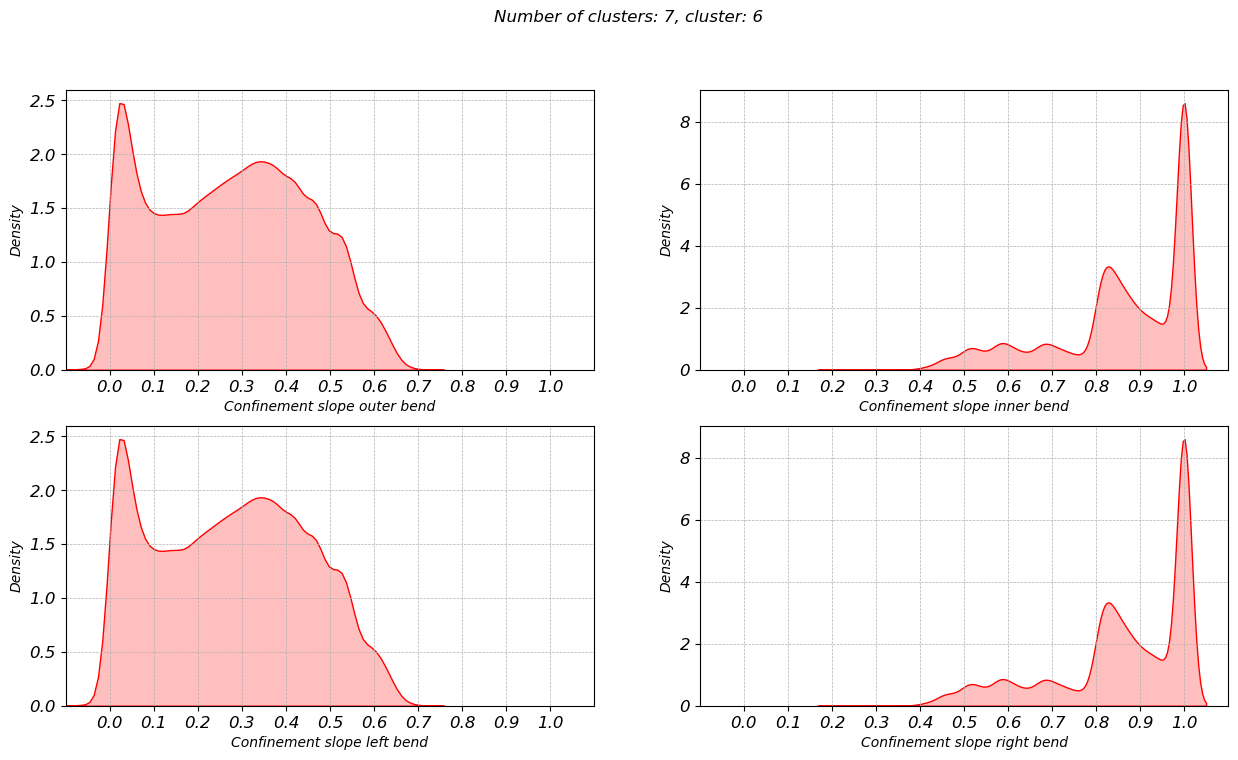

In [48]:
x = ['slope_out_normalized', 'slope_inn_normalized', 'slope_left_normalized', 'slope_right_normalized']
xl = ['outer', 'inner', 'left', 'right']
count = 0
for clusterVal in range(clusters):

    f, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [15, 8])
    count =0
    for i in range(2):
        for j in range(2):
            X     = x[count]
            dataH = dfCluster.copy().dropna(subset =X)
            dataH = dataH[dataH[f'GMM_pca_{clusters}_hard'] == clusterVal]
            # dataS9  = dataH[dataH[f'GMM_pca_{clusters}_90'] == clusterVal]
            # dataS99 = dataH[dataH[f'GMM_pca_{clusters}_99'] == clusterVal]

            L = sns.kdeplot(data = dataH, x = X, ax=axs[i,j], fill=True, color = 'red', legend = False)
            # L = sns.kdeplot(data = dataS9, x = X, ax=axs[i,j], fill=True, color = 'blue', legend = False)
            # L = sns.kdeplot(data = dataS99, x = X, ax=axs[i,j], fill=True, color = 'green', legend = False)
            axs[i,j].set_xlabel(f'Confinement slope {xl[count]} bend', fontsize = 10)
            axs[i,j].grid(True, which="both", ls="--", lw=0.5)
            axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
            # axs[i,j].set_ylim([0,0.06])
            axs[i,j].set_xlim([-0.1,1.1])
            axs[i,j].set_xticks(np.arange(0,1.1,0.1))
        
            
            count +=1
    f.suptitle(f'Number of clusters: {clusters}, cluster: {clusterVal}')
    plt.savefig(directory + f'results/figures/KDE_{clusters}_{clusterVal}_{CH}.png')
    plt.show()

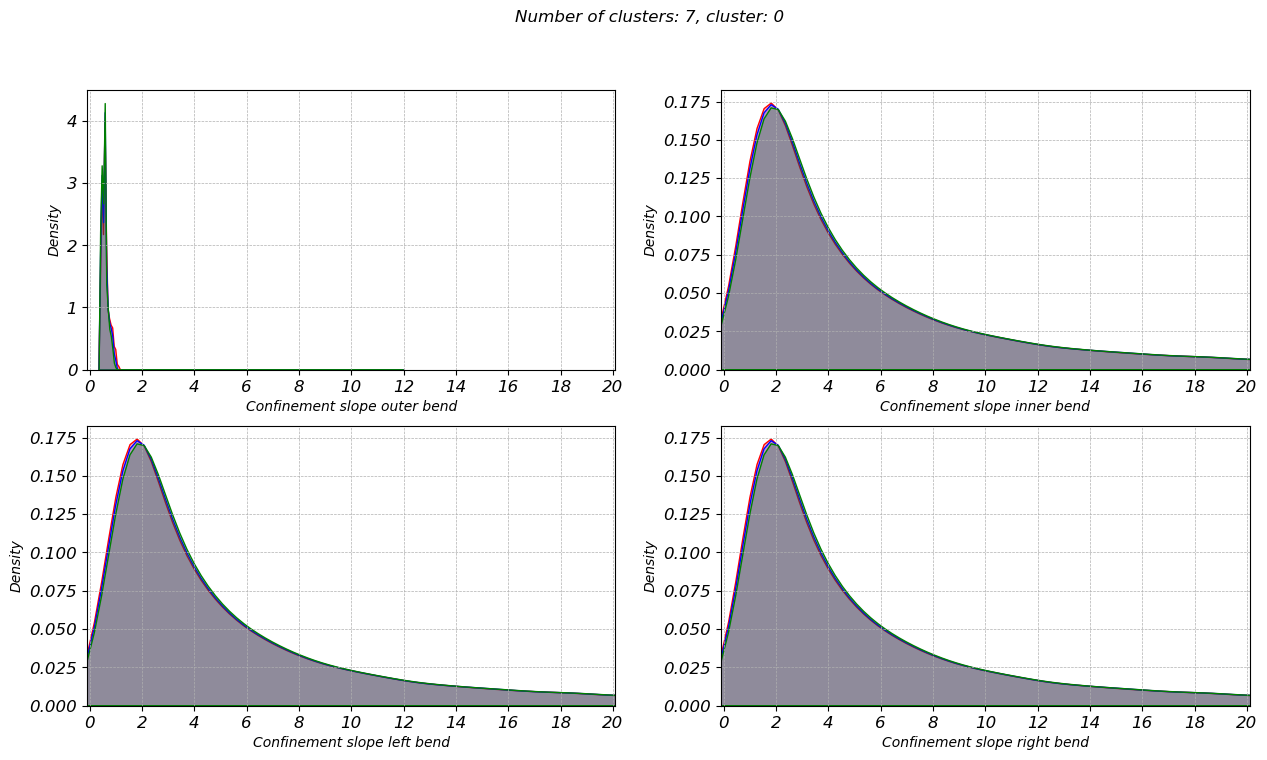

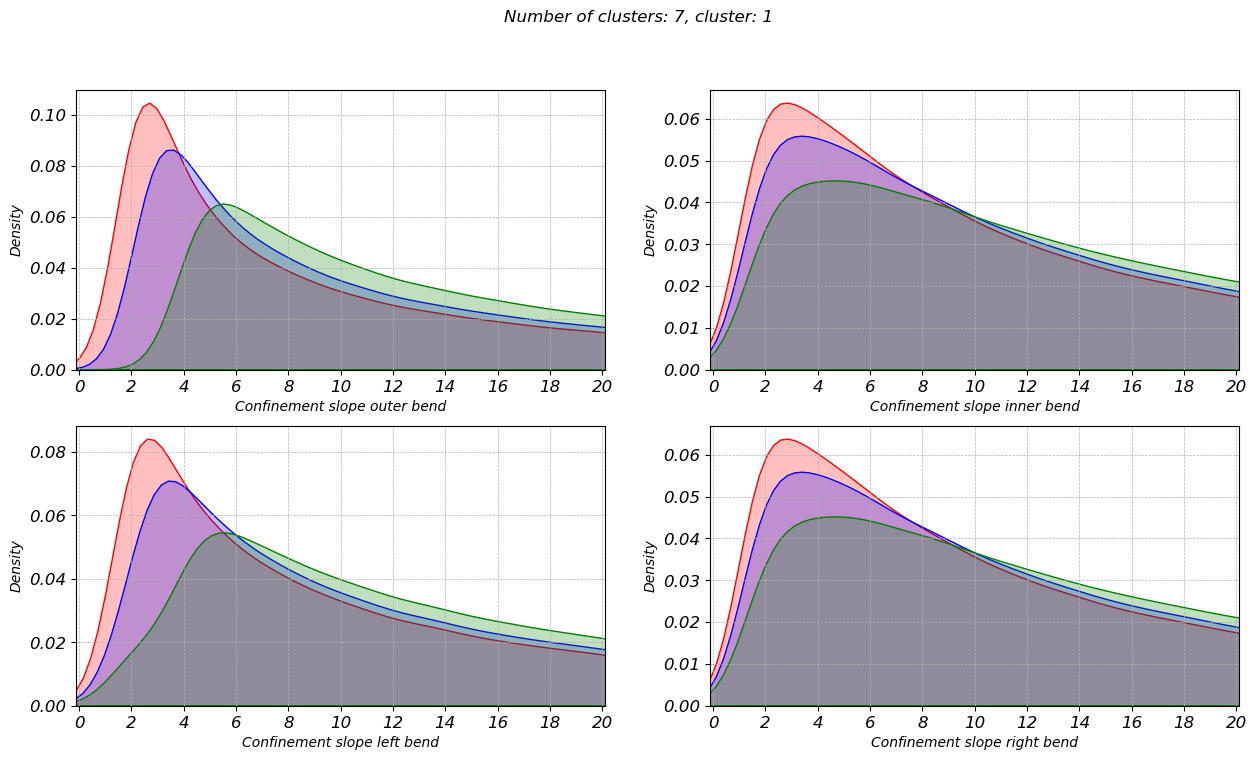

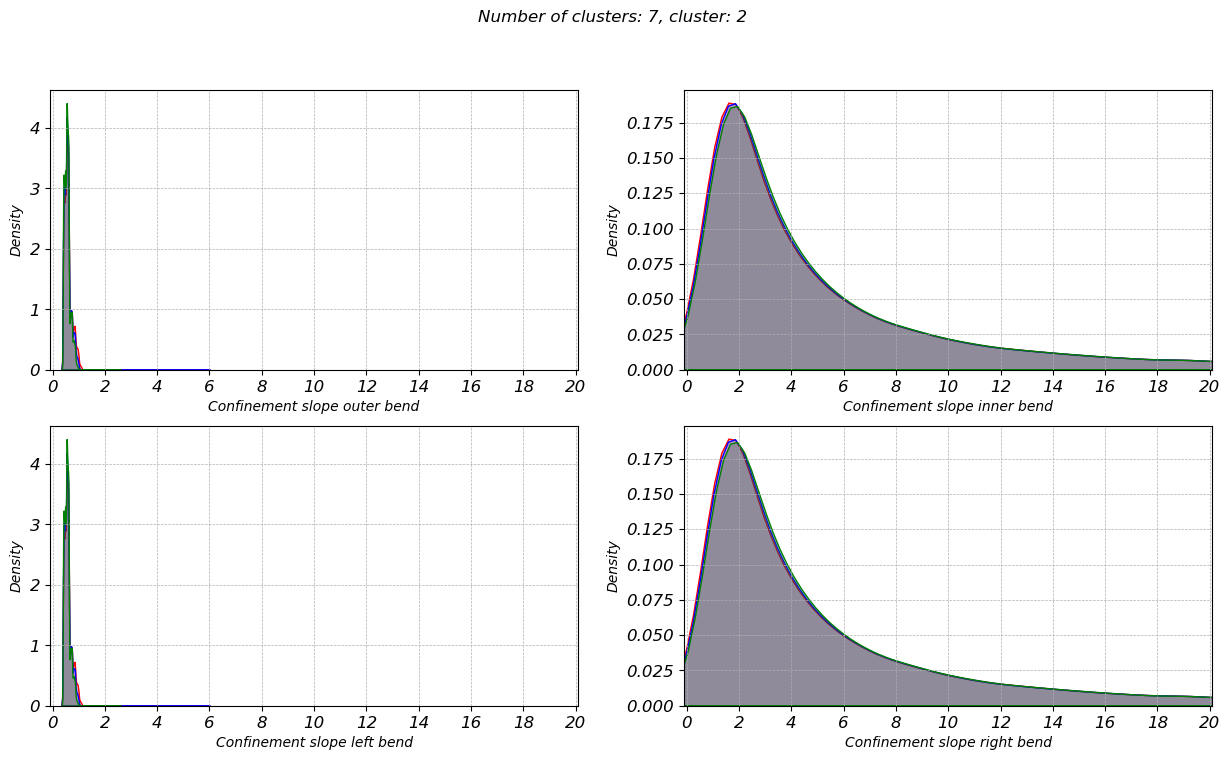

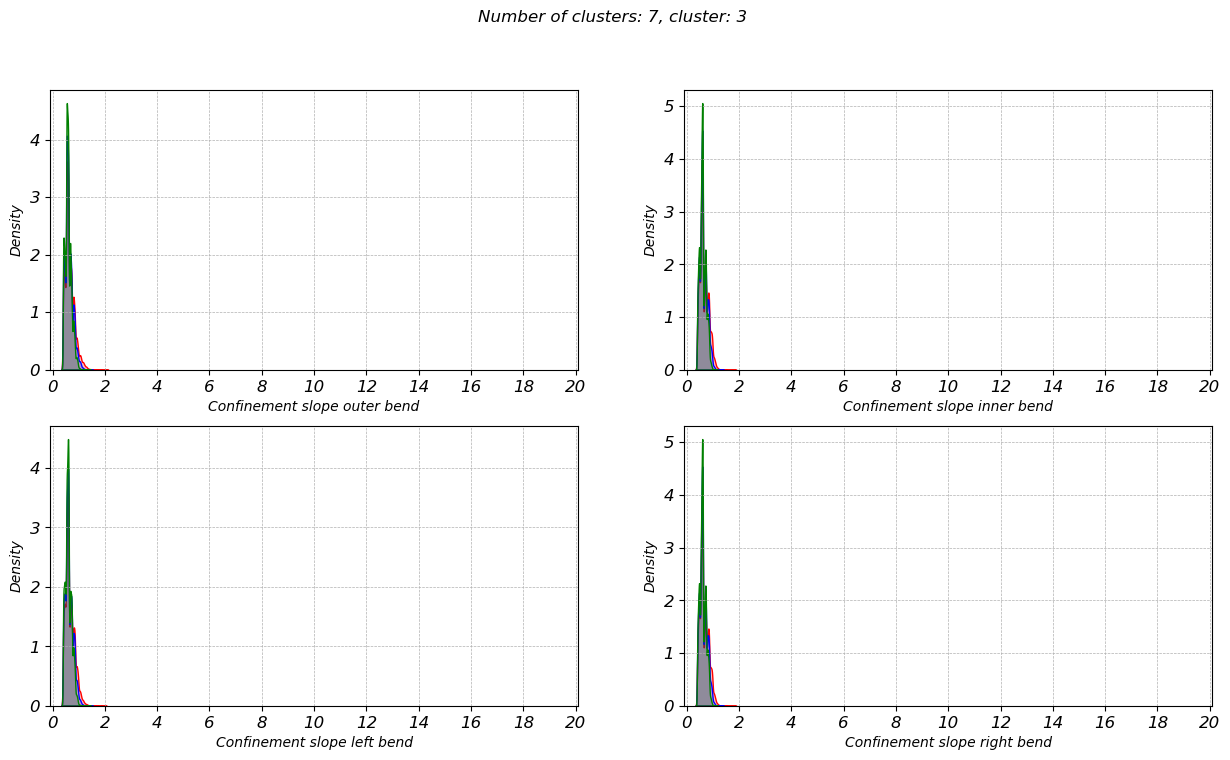

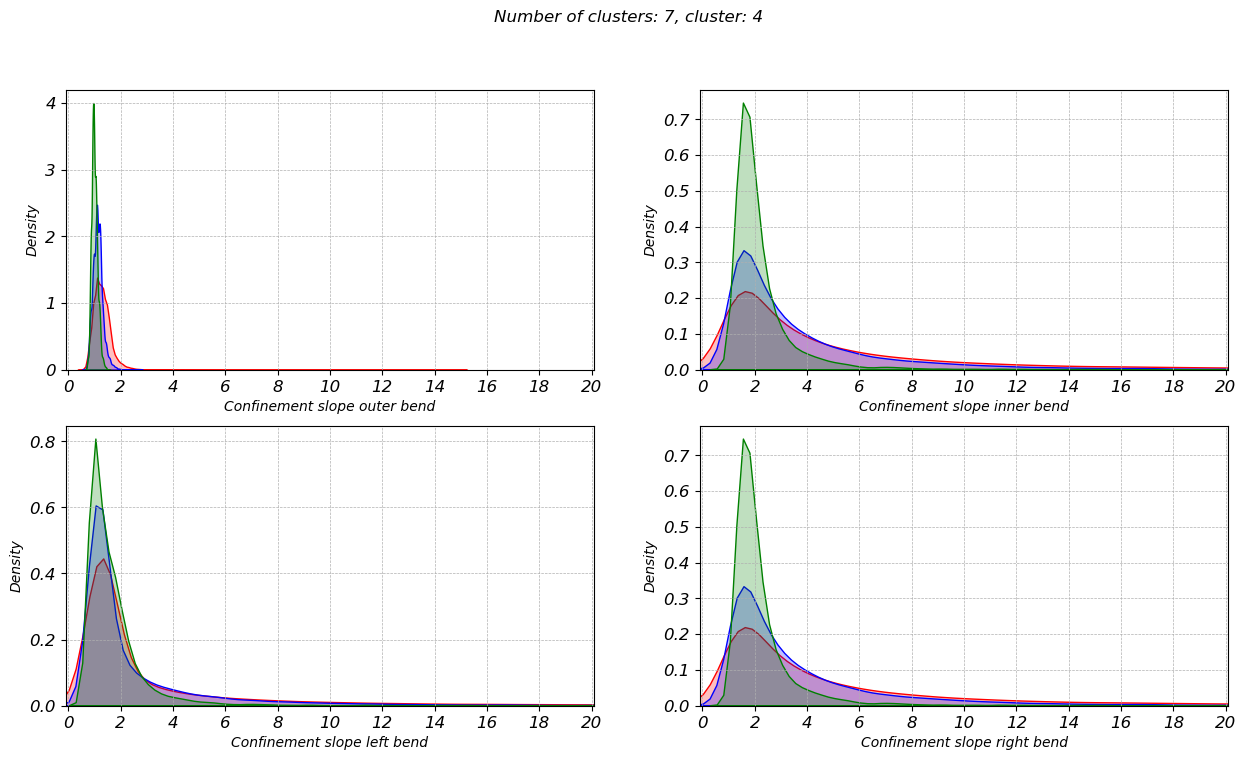

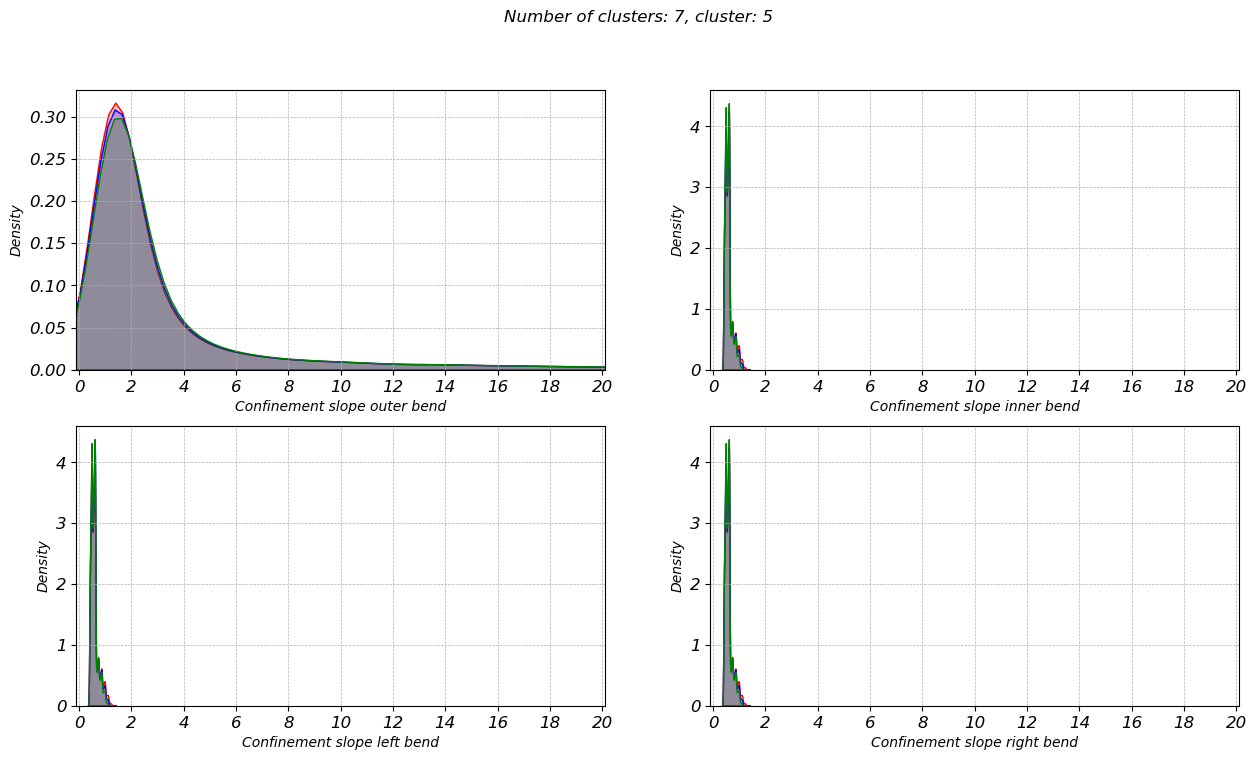

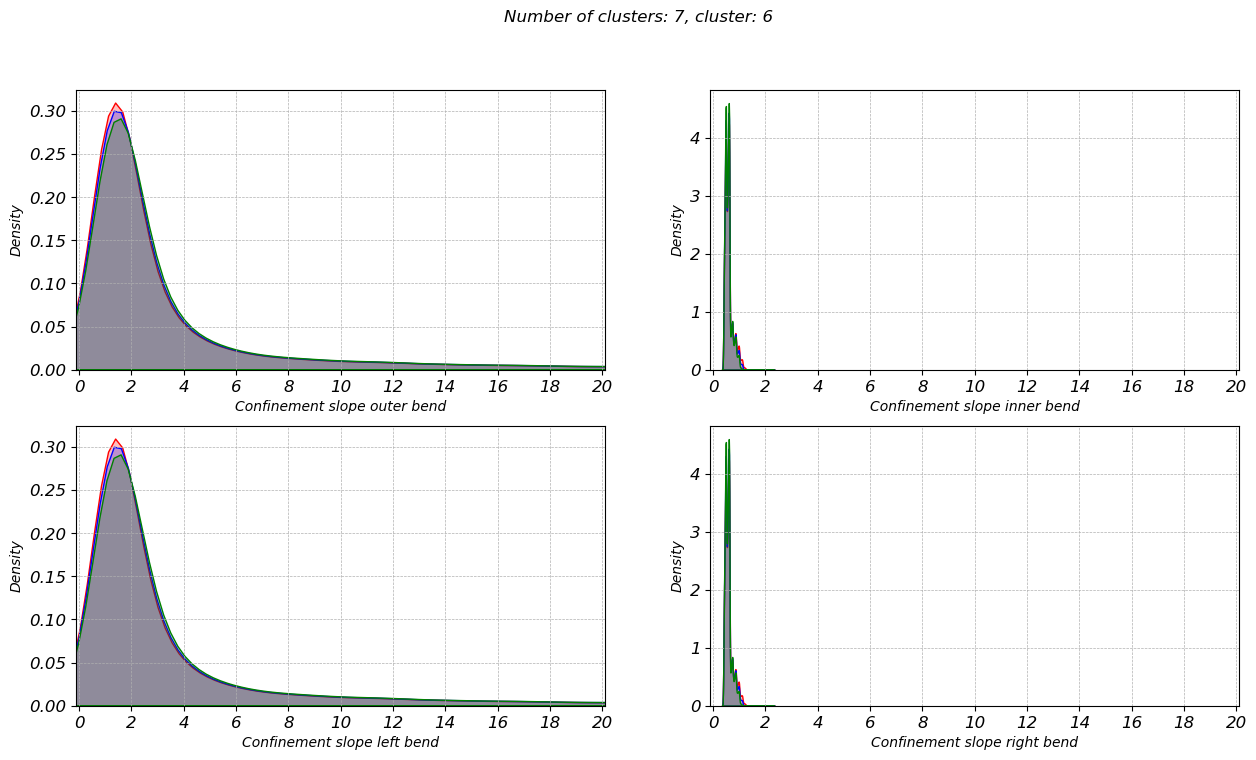

In [233]:
x = ['out', 'inn', 'left', 'inn']
xl = ['outer', 'inner', 'left', 'right']
count = 0
for clusterVal in range(clusters):

    f, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [15, 8])
    count =0
    for i in range(2):
        for j in range(2):
            X     = f'ER_{x[count]}'
            dataH = dfCluster.copy().dropna(subset =X)
            dataH = dataH[dataH[f'GMM_pca_{clusters}_hard'] == clusterVal]
            dataS9 = filtered_rows9.copy().dropna(subset =X)
            dataS9 = dataS9[dataS9[f'GMM_pca_{clusters}_hard'] == clusterVal]

            dataS99 = filtered_rows99.copy().dropna(subset =X)
            dataS99 = dataS99[dataS99[f'GMM_pca_{clusters}_hard'] == clusterVal]

            L = sns.kdeplot(data = dataH, x = X, ax=axs[i,j], fill=True, color = 'red', legend = False)
            L = sns.kdeplot(data = dataS9, x = X, ax=axs[i,j], fill=True, color = 'blue', legend = False)
            L = sns.kdeplot(data = dataS99, x = X, ax=axs[i,j], fill=True, color = 'green', legend = False)
            axs[i,j].set_xlabel(f'Confinement slope {xl[count]} bend', fontsize = 10)
            axs[i,j].grid(True, which="both", ls="--", lw=0.5)
            axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
            # axs[i,j].set_ylim([0,0.06])
            axs[i,j].set_xlim([-0.1,20.1])
            axs[i,j].set_xticks(np.arange(-0,22, 2))
        
            
            count +=1
    f.suptitle(f'Number of clusters: {clusters}, cluster: {clusterVal}')
    plt.savefig(directory + f'results/figures/KDE_{clusters}_{clusterVal}_{CH}_ER.png')
    plt.show()

### KDE X& Y matplotlib

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [12]:
def apply_kde(df, cluster, maxCluster, comb, res = 200):

    dfF = df.loc[df[f'GMM_{maxCluster}_hard'] == cluster]
    x = dfF[comb[0]].values
    y = dfF[comb[1]].values
    
    kdeT = dfF[comb].dropna().to_numpy()
    cov = np.cov(kdeT.T)

    if np.linalg.cond(cov) > 1e10:
        print(f'Linear relationship between axis ({comb}): {cluster}')
        print(np.linalg.cond(cov))
        print()
    else:
        # Compute 2D KDE
        values = np.vstack([x, y])
        kde    = gaussian_kde(values)

        # Evaluate on a grid
        xmin, xmax = x.min()-1, x.max()+1
        ymin, ymax = y.min()-1, y.max()+1
        X, Y = np.meshgrid(np.linspace(xmin, xmax, res),
                        np.linspace(ymin, ymax, res))
        positions = np.vstack([X.ravel(), Y.ravel()])
        Z         = np.reshape(kde(positions), X.shape)

        # Minimum density threshold
        # min_density = 0.0001  # skip contours below this


        # Mask low densities
        # Z_masked = np.where(Z < min_density, np.nan, Z)
        # print(Z_masked)
        return X, Y, Z


In [16]:
combs = [['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'],
         ['slope_out_normalized', 'slope_right_normalized'], ['slope_inn_normalized', 'slope_right_normalized']]
combNames = ['KDE_slopeOut_vs_slopeLeft', 'KDE_slopeInn_vs_slopeLeft']
clusters = 7
kde_list = []
for comb in combs:
    print(combs)
    k = []
    for c in tqdm(range(clusters)):
    # for c in [1]:
        k.append(apply_kde(dfCluster, c, clusters, comb, 400))
    kde_list.append(k)

    
    with open('/Volumes/PhD/confinement/KDE_slopeOut_vs_slopeLeft.pkl', 'wb') as f:
        pickle.dump(k, f)

[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'], ['slope_out_normalized', 'slope_right_normalized'], ['slope_inn_normalized', 'slope_right_normalized']]


 29%|██▊       | 2/7 [05:25<11:09, 133.87s/it]

Linear relationship between axis (['slope_out_normalized', 'slope_left_normalized']): 1
6.811572037950799e+16



 43%|████▎     | 3/7 [06:02<05:59, 89.92s/it] 

Linear relationship between axis (['slope_out_normalized', 'slope_left_normalized']): 3
6.54093672934357e+16



...

 29%|██▊       | 2/7 [05:16<10:51, 130.26s/it]

Linear relationship between axis (['slope_inn_normalized', 'slope_right_normalized']): 1
8227445373970798.0



 43%|████▎     | 3/7 [05:53<05:51, 87.88s/it] 

Linear relationship between axis (['slope_inn_normalized', 'slope_right_normalized']): 3
3.361736928811144e+16



100%|██████████| 7/7 [07:55<00:00, 67.87s/it]


In [149]:
f = glob(directory + 'results/single_values/*global_50_02*')[0]
ds = xr.open_dataset(f)

In [80]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

##### Two figures

['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']


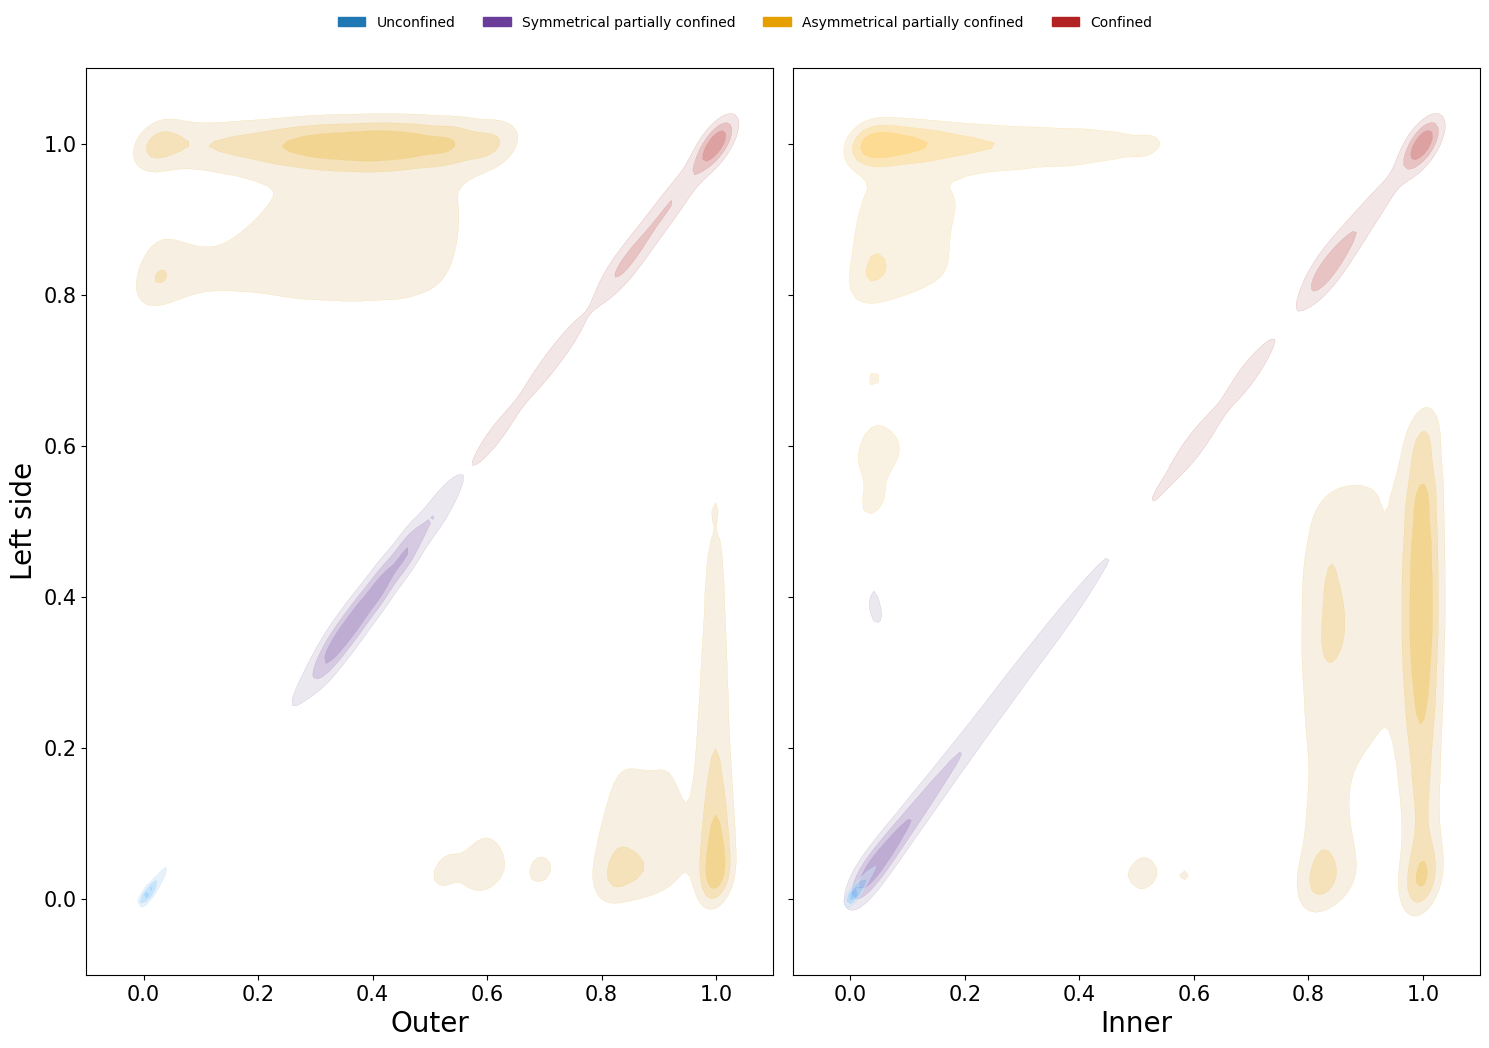

In [39]:
colors = ["#2fa8ff", "#e69f00", "#b22222", "#ffae00", '#e69f00','#6a3d9a', '#e69f00']
# xlab = ['Outer', 'Inner', 'Outer', 'Inner']
f,ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,10], squeeze = False, sharey = True)
ax = ax.flatten()
for i, comb in enumerate(combs[0:2]):
    print(comb)
    for c in range(clusters):
        if kde_list[i][c] is not None:
            X, Y, Z = kde_list[i][c]

            ZRel = Z/Z.max()
            Z    = np.where(ZRel < 0.001, np.nan, ZRel)

            # Define contour levels ABOVE min_density
            Z_min = np.nanmin(Z)
            Z_max = np.nanmax(Z)
            n_levels = 4
            levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
            levels = np.array([0.001, 0.25, 0.5, 0.75, 1.0])
            if all(levels == 0):
                continue
            # print(c, levels)
            # Filled contours (shades of one color)
            cmap = sns.light_palette(colors[c], as_cmap=True)
            if c == 0:
                zz = 1000
            else:
                zz = 1
            cf  = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.5, antialiased = True, zorder = zz)
            # This is the fix for the white lines between contour levels
            # cf.set_edgecolor("face")
            # Contour lines (single color, skip lowest)
            
            ax[i].set_xlim([-0.1,1.1])
            ax[i].set_ylim([-0.1,1.1])
            ax[i].set_xlabel(xlab[i], fontsize = labelSize)
            # ax[i].set_ylabel(axisLabels[comb[1]],fontsize = labelSize)
            ax[i].tick_params(axis='both', which='major', labelsize=tickSize)
            # Scatter original points
            # ax.scatter(x, y, s=10, facecolor="white", edgecolor="k", alpha=0.6)

            # Axes and grid
            # ax.set_facecolor("white")
            # ax.grid(True, linestyle="--", alpha=0.5)

            # Colorbar
            # fig.colorbar(cf, ax=ax, label="Density")
            cs = ax[i].contour(X, Y, Z, levels=levels[0:], colors=colors[c], linewidths=0.07)

# Create legend handles manually (to ensure one instance of each label)

legendColors = colors
legendLabels = list(np.arange(len(colors)))
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

legendColors = colors = ['#1f77b4','#6a3d9a', "#e69f00", "#b22222"]
legendLabels = ['Unconfined','Symmetrical partially confined', 'Asymmetrical partially confined' , 'Confined']
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=8,
    frameon=False,
    title_fontsize = labelSize
)
ax[0].set_ylabel('Left side', fontsize = labelSize)


plt.tight_layout()
plt.savefig(f'/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'+f'KDE_confinement_clustering_{clusters}_4.svg', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 2000)
plt.show()

### Four pannels

['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']
['slope_out_normalized', 'slope_right_normalized']
['slope_inn_normalized', 'slope_right_normalized']


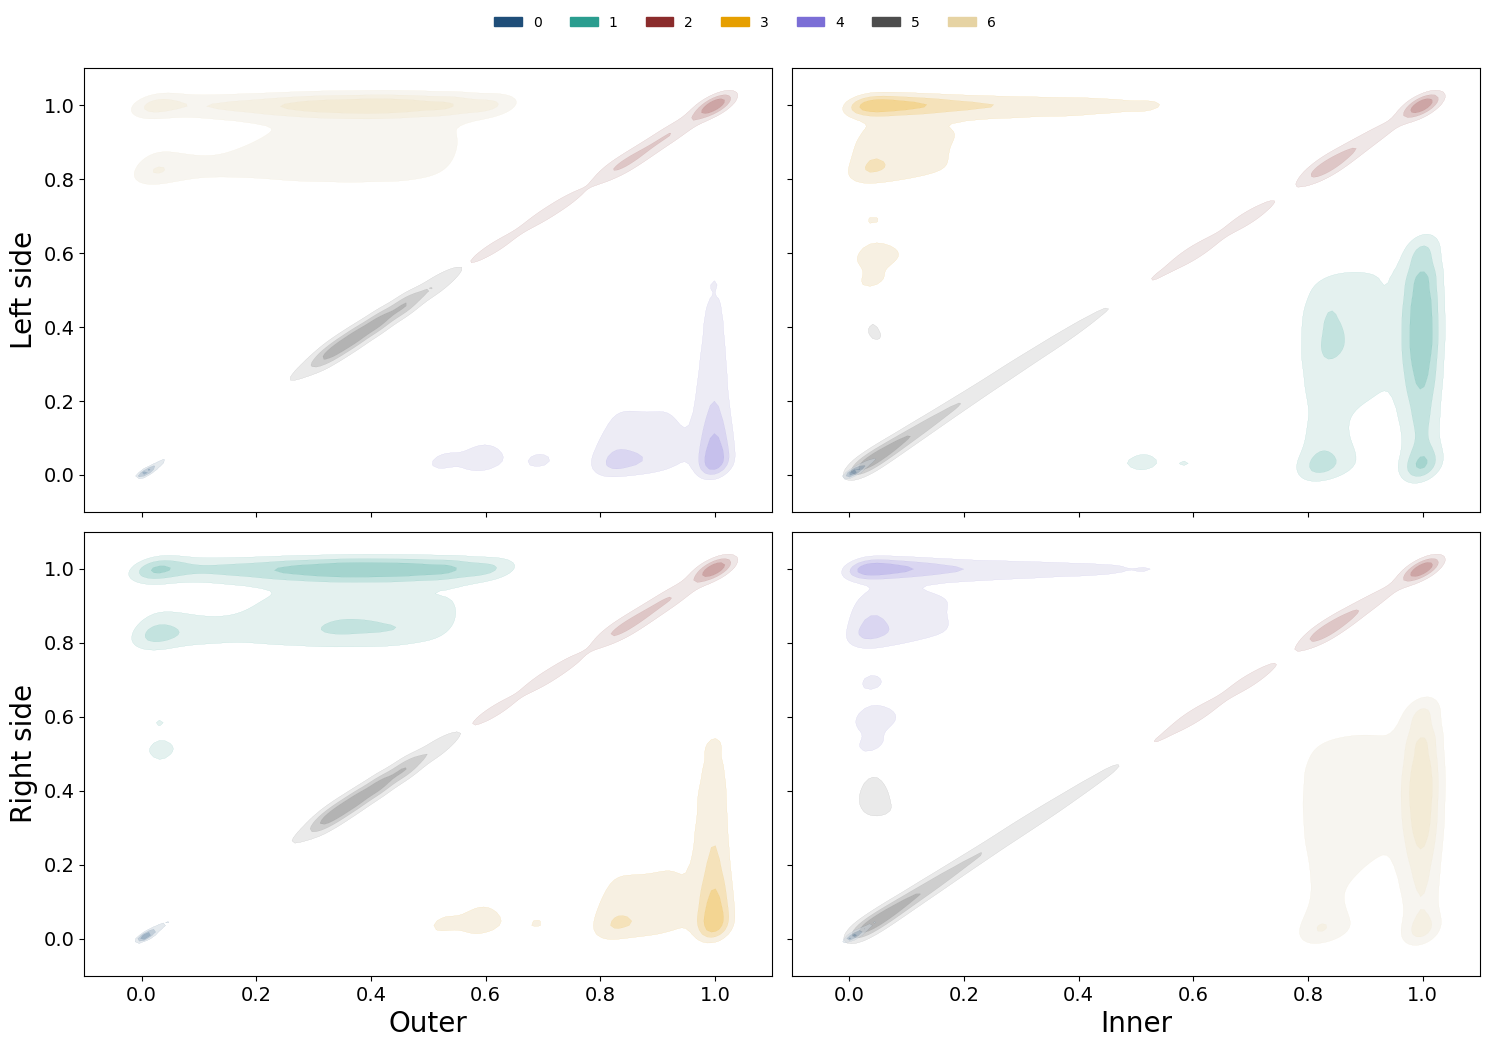

In [71]:
colors = ['#1f77b4', "#e69f00", "#b22222", "#ffae00", '#e69f00','#6a3d9a', '#e69f00']
colors = ['#1F4E79', '#2A9D8F',  '#8B2C2C','#E69F00', "#7B6ED6",'#4D4D4D', '#E6D3A3']
# xlab = ['Outer', 'Inner', 'Outer', 'Inner']
f,ax = plt.subplots(ncols = 2, nrows = 2, figsize = [15,10], squeeze = False, sharey = True, sharex = True)
ax = ax.flatten()
for i, comb in enumerate(combs):
    print(comb)
    for c in range(clusters):
        if kde_list[i][c] is not None:
            X, Y, Z = kde_list[i][c]

            ZRel = Z/Z.max()
            Z    = np.where(ZRel < 0.001, np.nan, ZRel)

            # Define contour levels ABOVE min_density
            Z_min = np.nanmin(Z)
            Z_max = np.nanmax(Z)
            n_levels = 4
            levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
            levels = np.array([0.001, 0.25, 0.5, 0.75, 1.0])
            if all(levels == 0):
                continue
            # print(c, levels)
            # Filled contours (shades of one color)
            cmap = sns.light_palette(colors[c], as_cmap=True)
            if c == 0:
                zz = 1000
            else:
                zz = 10
            cf  = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.5, antialiased = True, zorder = zz)
            # This is the fix for the white lines between contour levels
            # cf.set_edgecolor("face")
            # Contour lines (single color, skip lowest)
            
            ax[i].set_xlim([-0.1,1.1])
            ax[i].set_ylim([-0.1,1.1])
            # ax[i].set_xlabel(xlab[i], fontsize = labelSize)
            # ax[i].set_ylabel(axisLabels[comb[1]],fontsize = labelSize)
            ax[i].tick_params(axis='both', which='major', labelsize=tickSize)
            # Scatter original points
            # ax.scatter(x, y, s=10, facecolor="white", edgecolor="k", alpha=0.6)

            # Axes and grid
            # ax.set_facecolor("white")
            # ax.grid(True, linestyle="--", alpha=0.5)

            # Colorbar
            # fig.colorbar(cf, ax=ax, label="Density")
            cs = ax[i].contour(X, Y, Z, levels=levels[0:], colors=colors[c], linewidths=0.07)

# Create legend handles manually (to ensure one instance of each label)

legendColors = colors
legendLabels = list(np.arange(len(colors)))
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# legendColors = ['blue', 'green', 'cyan', 'red']
# legendLabels = ['Unconfined','Asymmetrical partially confined','Symmetrical partially confined','Confined']
# handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=8,
    frameon=False,
    title_fontsize = labelSize
)

ax[2].set_xlabel('Outer', fontsize = labelSize)
ax[3].set_xlabel('Inner', fontsize = labelSize)

ax[0].set_ylabel('Left side', fontsize = labelSize)
ax[2].set_ylabel('Right side', fontsize = labelSize)
plt.tight_layout()
plt.savefig(f'/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'+f'KDE_confinement_clustering_{clusters}_all.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 1000)
plt.show()

### KDE X & Y SNS

In [16]:
dfV = dfCluster.copy()

In [116]:
dfV.loc[(dfV['GMM_pca_7_hard'] == 0) | 
        (dfV['GMM_pca_7_hard'] == 2) | 
        (dfV['GMM_pca_7_hard'] == 5) | 
        (dfV['GMM_pca_7_hard'] == 6), 'KDE_cluster'] = 0
dfV.loc[(dfV['GMM_pca_7_hard'] == 1), 'KDE_cluster'] = 1
dfV.loc[(dfV['GMM_pca_7_hard'] == 3), 'KDE_cluster'] = 2
dfV.loc[(dfV['GMM_pca_7_hard'] == 4), 'KDE_cluster'] = 3

In [65]:
dfCluster.loc[dfCluster['GMM_pca_7_hard'] == 3, 'ER_out'].max()

2.0816532304742466

In [77]:
def plotKDE(ax, dff,col, xaxis, yaxis,xlab, ylab, palette, fill, A):
    
    unique_labels = sorted(dff[col].dropna().unique())
    labels = []
    X = f'slope_{xaxis}_normalized'
    Y = f'slope_{yaxis}_normalized'

    for i, label in enumerate(unique_labels):
        label = int(label)
        subset = dff[dff[col] == label]
        
        kdeT = subset[[X, Y]].dropna().to_numpy()
        cov = np.cov(kdeT.T)

        if np.linalg.cond(cov) > 1e10:
            print(f'Linear relationship between axis ({xaxis}, {yaxis}): {label}')
            print(np.linalg.cond(cov))
            print()
        else:
            sns.kdeplot(
                data=subset,
                x=X,
                y=Y,
                ax=ax,
                color=palette[i],
                fill=fill,
                warn_singular=False,
                alpha = A
            )
            labels.append(label)


    # Plot limits and layout
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel(f'Slope {xlab} bend', fontsize = labelSize)
    ax.set_ylabel(f'Slope {ylab} bend', fontsize = labelSize)
    ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)


In [75]:
dfV.loc[dfV['GMM_pca_7_hard'] == 0  ,'cluster_7'] = 2
dfV.loc[dfV['GMM_pca_7_hard'] == 1  ,'cluster_7'] = 1
dfV.loc[dfV['GMM_pca_7_hard'] == 2  ,'cluster_7'] = 5
dfV.loc[dfV['GMM_pca_7_hard'] == 3  ,'cluster_7'] = 4
dfV.loc[dfV['GMM_pca_7_hard'] == 4  ,'cluster_7'] = 3
dfV.loc[dfV['GMM_pca_7_hard'] == 5  ,'cluster_7'] = 6
dfV.loc[dfV['GMM_pca_7_hard'] == 6  ,'cluster_7'] = 7

# 1 Unconfined
# 2 Apartial
# 3 Spartial
# 4 Confined
# 5 Apartial
# 6 Apartial
# 7 Apartial

Linear relationship between axis (left, out): 5
7344581005892771.0

Linear relationship between axis (left, out): 7
6.569665887693874e+16

Linear relationship between axis (left, inn): 2
1.0448178788851507e+17

Linear relationship between axis (left, inn): 6
1.3952905675549366e+16



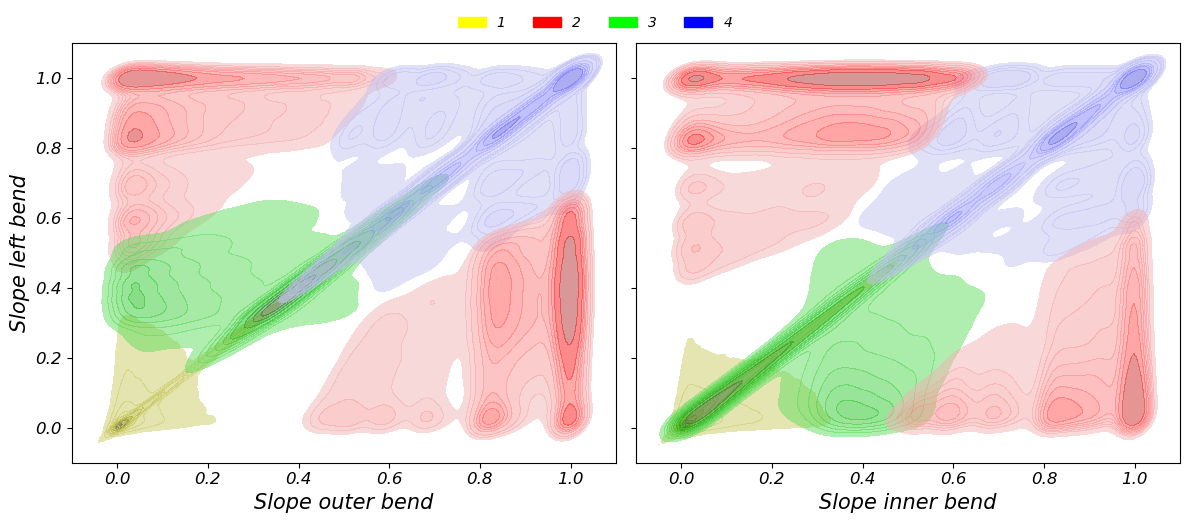

In [81]:

D = dfV.copy()
# D = D.iloc[0:1000]
fill = True
A    = 0.5
palette = [(1,0,0), (1,0.5,0), (1,1,0), (0,0.851,0.161), (0,1,1), (0,0,1), (1,0,1)]
palette = [(1,0,0), (1,1,0), (1,0,0), (0,1,0), (0,0,1), (1,0,0), (1,0,0)]
palette = [(1,1,0), (1,0,0), (0,1,0), (0,0,1), (1,0,0), (1,0,0), (1,0,0)]

f, ax = plt.subplots(nrows = 1, ncols = 2, squeeze = False, sharex=True, sharey=True, figsize = [12,5])
plotKDE(ax[0,0], D,'cluster_7', 'left', 'out', 'outer', 'left' , palette, fill, A)
plotKDE(ax[0,1], D,'cluster_7', 'left', 'inn', 'inner', 'left' , palette, fill, A)

paletteL = [palette[0] , palette[1], palette[2], palette[3]]
# Create legend handles manually (to ensure one instance of each label)
handles = [Patch(color=paletteL[i], label=group + 1) for i, group in enumerate(np.arange(len(paletteL)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=7,
    frameon=False
)

plt.tight_layout()
# plt.savefig(directory + f'results/figures/KDE_GMM_conf_7.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 1000)
plt.show()

In [71]:
A = dfCluster.loc[dfCluster['GMM_pca_7_hard'] == 4]
A['ER_out'].sort_values()
A[A['ER_inn'].isna()]

,index,combined_reach_id,reach_id,file,bendLen,up_reach_id,networkGraph,networkGroup,river_name,dn_connected_reach,...,GMM_pca_7_0_soft,GMM_pca_7_1_soft,GMM_pca_7_2_soft,GMM_pca_7_3_soft,GMM_pca_7_4_soft,GMM_pca_7_5_soft,GMM_pca_7_6_soft,GMM_pca_7_90,GMM_pca_7_95,GMM_pca_7_99
258,258,26.0,11443000061,af,2087.390854,1.144900e+10,0,0,Jubba River,1.144300e+10,...,4.944894e-05,0.428387,1.761208e-13,1.619870e-10,0.571563,1.542438e-21,3.914416e-13,NaN,NaN,NaN
576,576,77.0,11441100081,af,1917.142846,1.144900e+10,0,0,Jubba River,1.144110e+10,...,5.015841e-02,0.080570,5.979421e-13,2.441816e-10,0.869272,2.348304e-24,8.409542e-14,NaN,NaN,NaN
621,621,81.0,11441100041,af,1037.428850,1.144900e+10,0,0,Jubba River,1.144110e+10,...,7.392070e-02,0.040751,4.394153e-13,4.632845e-09,0.885328,3.995957e-23,2.737766e-12,NaN,NaN,NaN
763,763,93.0,11410000023,af,2538.923052,1.149900e+10,0,0,Jubba River,NaN,...,3.622020e-13,0.208998,2.477919e-04,2.813532e-09,0.790755,4.648791e-13,6.862282e-20,NaN,NaN,NaN
2007,2007,198.0,11493300031,af,1406.323278,1.149900e+10,0,0,NODATA,1.149330e+10,...,8.134010e-03,0.154850,1.151507e-13,7.673852e-10,0.837016,6.689169e-23,2.163882e-12,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1488814,13362,15513.0,29499900091,eu,988.374916,2.949990e+10,434,5,Murat River,2.949990e+10,...,2.220028e-05,0.236342,1.905085e-11,1.713225e-10,0.763636,2.448892e-21,4.750591e-15,NaN,NaN,NaN
1488912,13460,15521.0,29499700141,eu,1509.129737,2.949990e+10,434,5,Murat River,2.949970e+10,...,1.855130e-13,0.335029,1.670850e-04,3.626403e-10,0.664804,9.015245e-14,1.028337e-20,NaN,NaN,NaN
1488983,13531,15526.0,29499800031,eu,916.521173,2.949980e+10,434,5,NODATA,2.949980e+10,...,1.654859e-01,0.003058,1.030536e-09,5.363838e-09,0.831456,5.369408e-24,7.311437e-16,NaN,NaN,NaN
1489309,42856,15549.0,28101400041,eu,212.974595,2.810950e+10,418,4,NODATA,2.810140e+10,...,4.429616e-03,0.134830,6.881630e-13,4.117103e-10,0.860740,4.978236e-23,1.909703e-13,NaN,NaN,NaN


Linear relationship between axis (left, out): 2
3.2821247058152148e+16

Linear relationship between axis (left, out): 6
4.6621929423336344e+16

Linear relationship between axis (left, inn): 0
1.3819344423994168e+17

Linear relationship between axis (left, inn): 5
1.0004096019717885e+17



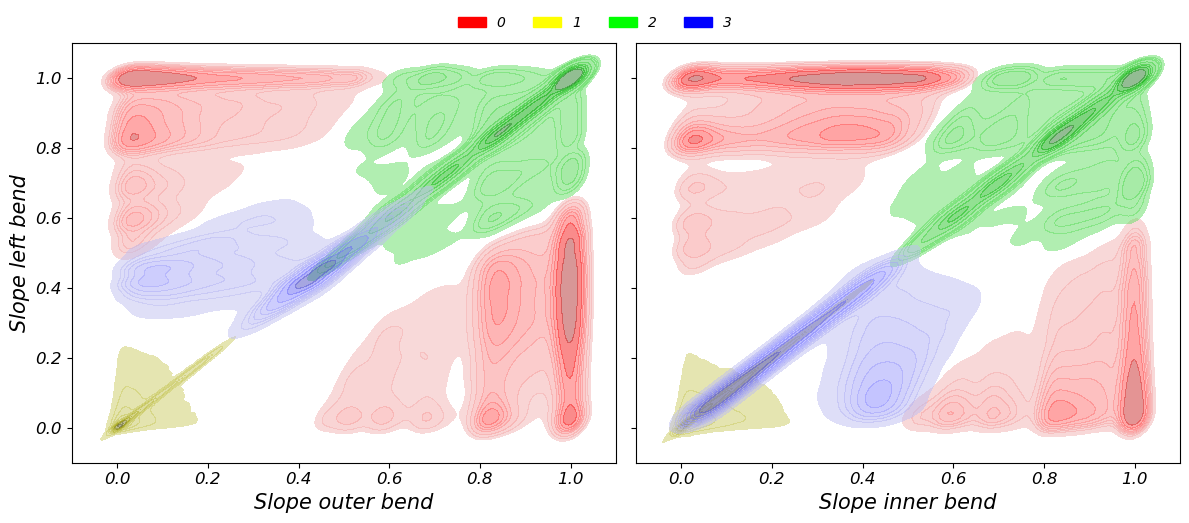

In [26]:

D = dfV.copy()
fill = True
A    = 0.5
palette = [(1,0,0),(1,0.5,0), (1,1,0), (0,0.851,0.161), (0,1,1), (0,0,1), (1,0,1)]
palette = [(1,0,0),(1,1,0), (1,0,0), (0,1,0), (0,0,1), (1,0,0), (1,0,0)]

f, ax = plt.subplots(nrows = 1, ncols = 2, squeeze = False, sharex=True, sharey=True, figsize = [12,5])
plotKDE(ax[0,0], D,'GMM_pca_7_90', 'left', 'out', 'outer', 'left' , palette, fill, A)
plotKDE(ax[0,1], D,'GMM_pca_7_90', 'left', 'inn', 'inner', 'left' , palette, fill, A)

paletteL = [palette[0] , palette[1], palette[3], palette[4]]
# Create legend handles manually (to ensure one instance of each label)
handles = [Patch(color=paletteL[i], label=group) for i, group in enumerate(np.arange(len(paletteL)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=7,
    frameon=False
)

plt.tight_layout()
plt.savefig(directory + f'results/figures/KDE_GMM_conf_7_90.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 1000)
plt.show()

Linear relationship between axis (left, out): 2
8.430174730035125e+16

Linear relationship between axis (left, out): 6
1.3572435909270236e+16

Linear relationship between axis (left, inn): 0
1.5680399296128144e+16

Linear relationship between axis (left, inn): 5
5.241150453131915e+16



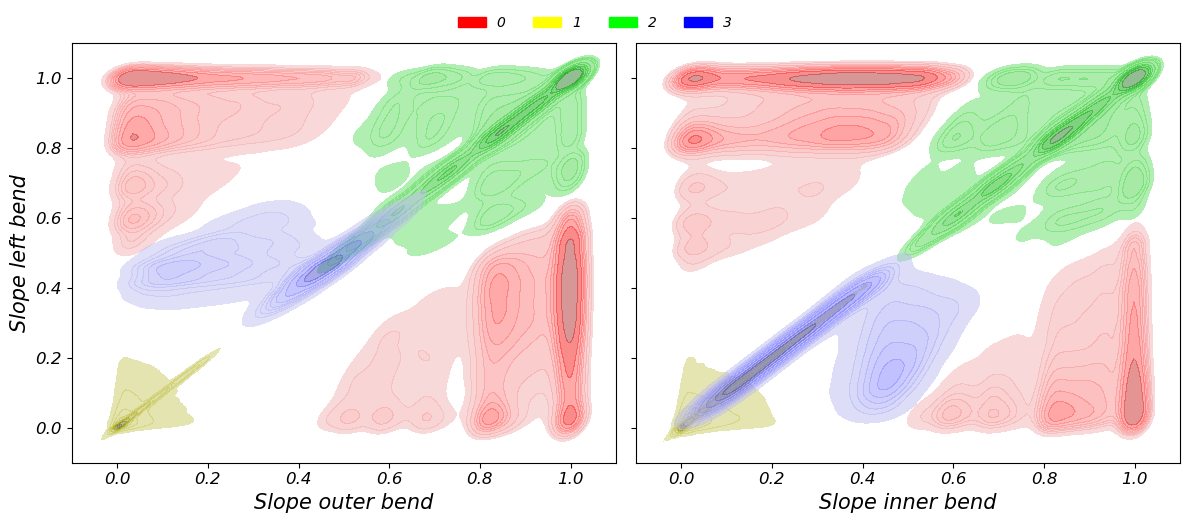

In [27]:

D = dfV.copy()
fill = True
A    = 0.5
palette = [(1,0,0),(1,0.5,0), (1,1,0), (0,0.851,0.161), (0,1,1), (0,0,1), (1,0,1)]
palette = [(1,0,0),(1,1,0), (1,0,0), (0,1,0), (0,0,1), (1,0,0), (1,0,0)]

f, ax = plt.subplots(nrows = 1, ncols = 2, squeeze = False, sharex=True, sharey=True, figsize = [12,5])
plotKDE(ax[0,0], D,'GMM_pca_7_95', 'left', 'out', 'outer', 'left' , palette, fill, A)
plotKDE(ax[0,1], D,'GMM_pca_7_95', 'left', 'inn', 'inner', 'left' , palette, fill, A)

paletteL = [palette[0] , palette[1], palette[3], palette[4]]
# Create legend handles manually (to ensure one instance of each label)
handles = [Patch(color=paletteL[i], label=group) for i, group in enumerate(np.arange(len(paletteL)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=7,
    frameon=False
)

plt.tight_layout()
plt.savefig(directory + f'results/figures/KDE_GMM_conf_7_95.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 1000)
plt.show()

In [134]:
dfCluster[dfCluster['GMM_7_hard'] == 0].shape[0] / dfCluster.shape[0],\
    dfCluster[dfCluster['GMM_7_hard'] == 2].shape[0] / dfCluster.shape[0],\
    dfCluster[(dfCluster['GMM_7_hard'] == 1) | (dfCluster['GMM_7_hard'] == 3)|
              (dfCluster['GMM_7_hard'] == 4) | (dfCluster['GMM_7_hard'] == 6)].shape[0] / dfCluster.shape[0],\
    dfCluster[dfCluster['GMM_7_hard'] == 5].shape[0] / dfCluster.shape[0]
              

(0.6105378096567453,
 0.06225475562297114,
 0.23199412085858057,
 0.09521331386170301)

In [279]:
A =df[(df['bendHeight'] > 705) & (df['bendHeight'] < 715) & (df['file'] == 'eu')]
A.reach_id.values

array([21103600181, 21103600181, 21103600181, 21303000221, 21303000221,
       21303000221, 21303000221, 21303000221, 21307600181, 21307600221,
       21307600221, 21602200461, 21602200461, 21602400441, 21604200411,
       22140600191, 22140600191, 22140600191, 22140600191, 22140600191,
       22140600191, 22140600191, 22140600191, 22140600191, 22140600191,
       22140600191, 22140600191, 22140600191, 22160300291, 22160300291,
       22160200461, 22160200461, 22160200461, 22160200461, 22160200461,
       22160200271, 22160200271, 22160200271, 22160200271, 22180000451,
       22180000231, 22180000231, 22180000231, 22180000231, 22190200421,
       22190200421, 22190200421, 22190200271, 22190400171, 22190400241,
       22190600121, 22190600121, 22190600121, 22202900991, 22202600231,
       22202600231, 22202600231, 22202600231, 22202600181, 22202800111,
       22202800111, 22202800111, 22202800111, 22202800111, 22202900871,
       22202900621, 22740200391, 22740200391, 22780400761, 22780

Linear relationship between axis (left, out): 2
5.000518001327871e+16

Linear relationship between axis (left, out): 6
7739425934063633.0

Linear relationship between axis (left, inn): 0
5.1856406073515496e+16

Linear relationship between axis (left, inn): 5
2.5800617784781805e+17

Linear relationship between axis (right, out): 0
6.497992803068748e+16

Linear relationship between axis (right, out): 5
1.4889638612480694e+16

Linear relationship between axis (right, inn): 2
1.3362315282467765e+17

Linear relationship between axis (right, inn): 6
7.493090055852405e+16



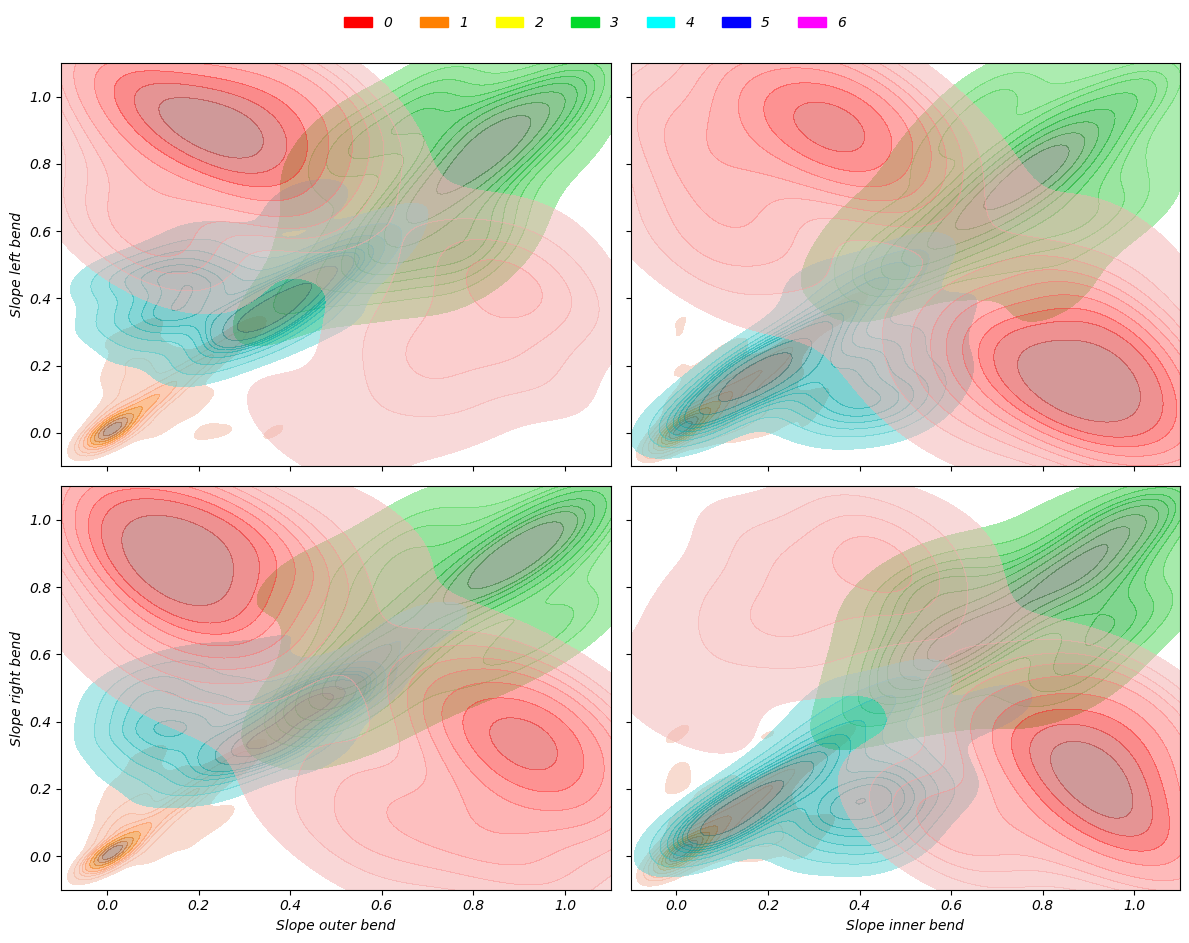

Linear relationship between axis (left, out): 2
5.000518001327871e+16

Linear relationship between axis (left, out): 6
7739425934063633.0

Linear relationship between axis (left, inn): 0
5.1856406073515496e+16

Linear relationship between axis (left, inn): 5
2.5800617784781805e+17

Linear relationship between axis (right, out): 0
6.497992803068748e+16

Linear relationship between axis (right, out): 5
1.4889638612480694e+16

Linear relationship between axis (right, inn): 2
1.3362315282467765e+17

Linear relationship between axis (right, inn): 6
7.493090055852405e+16



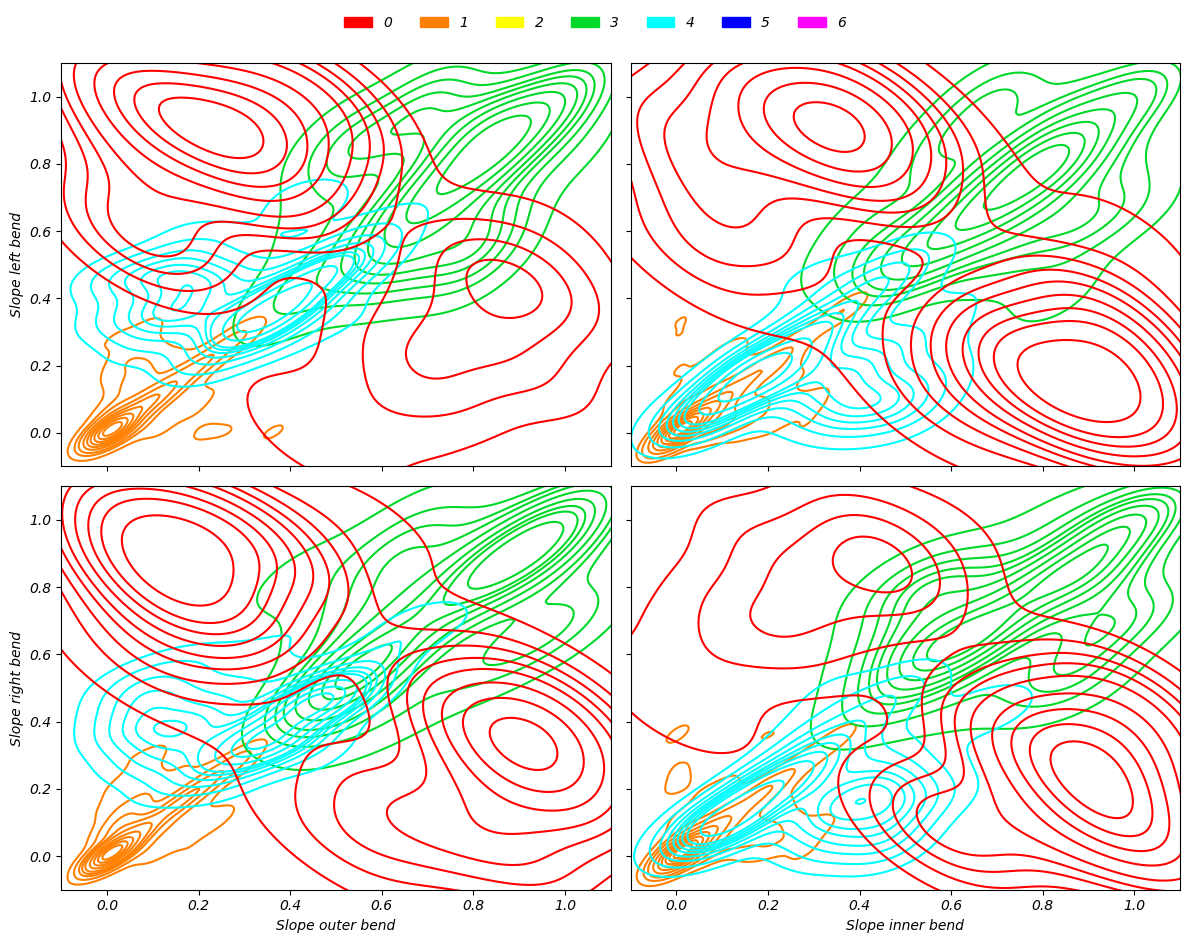

In [254]:
def plotKDE(ax, dff,col, xaxis, yaxis,xlab, ylab, palette, fill, A):
    
    unique_labels = sorted(dff[col].dropna().unique())
    labels = []
    X = f'slope_{xaxis}_normalized'
    Y = f'slope_{yaxis}_normalized'
    p1 = [1,3,4]


    for label in p1:
        subset = dff[dff[col] == label]
        sns.kdeplot(
            data=subset,
            x=X,
            y=Y,
            ax=ax,
            color=palette[label],
            fill=fill,
            warn_singular=False,
            alpha = A
        )
        labels.append(label)
    p2, p2Labels = [0,2,5,6], []
    for label in p2:
        subset = dff[dff[col] == label]
        kdeT = subset[[X, Y]].dropna().to_numpy()
        cov = np.cov(kdeT.T)
        if np.linalg.cond(cov) > 1e10:
            print(f'Linear relationship between axis ({xaxis}, {yaxis}): {label}')
            print(np.linalg.cond(cov))
            print()
        else:
            p2Labels.append(label)
    subset = dff[dff[col].isin(p2Labels)]
    sns.kdeplot(
    data=subset,
        x=X,
        y=Y,
        ax=ax,
        color=palette[0],
        fill=fill,
        warn_singular=False,
        alpha = A
        )

    # Plot limits and layout
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel(f'Slope {xlab} bend')
    ax.set_ylabel(f'Slope {ylab} bend')

D = dfV.copy()
D = D.iloc[0:1000]
for i in range(2):
    if i == 0:
        fill = True
        A    = 0.5
    else:
        fill, A = False, 1
    palette = [(1,0,0),(1,0.5,0), (1,1,0), (0,0.851,0.161), (0,1,1), (0,0,1), (1,0,1)]
    palette = [(1,0,0),(1,0.5,0), (1,1,0), (0,0.851,0.161), (0,1,1), (0,0,1), (1,0,1)]
    f, ax = plt.subplots(nrows = 2, ncols = 2, squeeze = False, sharex=True, sharey=True, figsize = [12,9])
    plotKDE(ax[0,0], D,'GMM_pca_7_hard', 'left', 'out', 'outer', 'left' , palette, fill, A)
    plotKDE(ax[0,1], D,'GMM_pca_7_hard', 'left', 'inn', 'inner', 'left' , palette, fill, A)

    plotKDE(ax[1,0], D,'GMM_pca_7_hard', 'right', 'out', 'outer', 'right', palette, fill, A)
    plotKDE(ax[1,1], D,'GMM_pca_7_hard', 'right', 'inn', 'inner', 'right', palette, fill, A)


    # Create legend handles manually (to ensure one instance of each label)
    handles = [Patch(color=palette[i], label=group) for i, group in enumerate(np.arange(7))]

    # Add shared legend at the top center
    f.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.05),
        ncol=7,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(directory + f'results/figures/KDE_GMM_conf_7_{i}.png')
    plt.show()

# HDBSCAN

In [ ]:
def stratified_sample(X, labels, n):
    if len(np.unique(labels)) < 2 or all(labels == -1):
        return None, None
    X_sample, _, y_sample, _ = train_test_split(X, labels, train_size=n, stratify=labels, random_state=42)
    return X_sample, y_sample

In [ ]:
Xs, Ls = stratified_sample(X_pca[:, 0:6], labels, 50000)

In [ ]:

def HDBSCAN_tune_PCA(X):
    size = len(X)
    param_grid = {
        "min_cluster_size": [int(size * 0.005), int(size * 0.01)],
        "min_samples":      [int(size * 0.0025), int(size * 0.005), int(size * 0.01)],
        "cluster_selection_method": ["eom"]
    }

    grid = ParameterGrid(param_grid)
    best_score = -1
    best_model = None

    for params in grid:
        if params['min_cluster_size'] < params['min_samples']:
            continue
        dt1 = dt.now()
        print(f'{params}')
        model = HDBSCAN(**params, metric = 'manhattan')
        dt2 = dt.now()
        print(f'\tModel created: {dt2- dt1}')
        labels = model.fit_predict(X, )
        dt3 = dt.now()
        print(f'\tModel fitted: {dt3 - dt2}')
        if len(set(labels)) > 1 and np.sum(labels != -1) > 10:
            Xs, Ls = stratified_sample(X, labels, 10000)
            score = validity_index(Xs, Ls)
            dt4 = dt.now()
            print(f"\tDBCV: {score:.3f}, time: {dt4-dt3}")
            if score > best_score:
                best_score = score
                best_model = model
    return best_model

In [ ]:

# 5. Calculate Silhouette score (range -1 to 1, higher is better)
sil_score = silhouette_score(Xs, Ls)
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: -0.008


In [ ]:

# 6. Calculate DBCV score (Density-Based Clustering Validation)
# Note: DBCV requires distance matrix or metric='euclidean' by default
dbcv_score = validity_index(Xs, Ls, metric='euclidean')
print(f"DBCV score: {dbcv_score:.3f}")


NameError: name 'Xs' is not defined

In [ ]:
pca = PCA(n_components=12)  # e.g., reduce to 10 components
X_pca = pca.fit_transform(X_scaledSOT)


In [ ]:

print('HBDSCAN')
HDBSCAN_tune_PCA(X_pca[:,:6])


HBDSCAN
{'cluster_selection_method': 'eom', 'min_cluster_size': 7438, 'min_samples': 3719}
	Model created: 0:00:00.000082


KeyboardInterrupt: 

In [ ]:

print('GMM')
def GMM_tune(X, n_components, n_init):
    print(n_components, n_init)
    gmm = GaussianMixture(n_components=n_components, 
                          covariance_type='full',
                          init_params='kmeans',
                          random_state=42, n_init = n_init)
    gmm.fit(X)

    labels = gmm.predict(X)
    # 4. Calculate BIC score (lower is better)
    bic = gmm.bic(X)
    print(f"BIC score: {bic:.2f}")
    Xs, Ls = stratified_sample(X_pca[:, 0:6], labels, 10000)
    # 5. Calculate Silhouette score (range -1 to 1, higher is better)
    sil_score = silhouette_score(Xs, Ls)
    print(f"Silhouette Score: {sil_score:.3f}")

    dbcv_score = validity_index(Xs, Ls, metric='euclidean')
    print(f"DBCV score: {dbcv_score:.3f}")

for n in [4,5,6,7,8,9,10]:
    for init in [1,5, 10, 20]:
        GMM_tune(X_pca[:,:6], n, init)
        print()

GMM
4
BIC score: 12016963.91
Silhouette Score: 0.097
DBCV score: -0.832

4
BIC score: 11812140.26
Silhouette Score: 0.081
DBCV score: -0.813

4
BIC score: 11808012.68
Silhouette Score: 0.091
DBCV score: -0.819

4


# Region values

In [57]:
reaches = [17211100894, 17211100904, 17211100914, 17211100041, 17211100051,
       17211100061, 17211100081, 17211100091, 17211100101, 17211100111,
       17211100121, 17211100131, 17211100141, 17211100151, 17211100161,
       17211100171, 17211300011, 17211300021, 17211300031, 17211300041,
       17211100635, 17211100645, 17211100655, 17211100664, 17211100675,
       17211100685, 17211100695, 17211100705, 17211100715, 17211100725,
       17211100735, 17211100745, 17211100755, 17211100764, 17211100775,
       17211100785, 17211100795, 17211100805, 17211100815, 17211100825,
       17211100835, 17211100845, 17211100855, 17211100865, 17211100875,
       17211100885, 17211100925, 17211300051, 17211300061, 17211300071,
       17211300081, 17211300091, 17211300101, 17211300111, 17211300121,
       17211300134, 17211300141, 17211300151, 17211300161, 17211300171,
       17211300181, 17211300191, 17211300201, 17211500011, 17211500021,
       17211500031, 17211500041, 17211500054, 17211500061, 17211500074,
       17211500081, 17211500091, 17211500101, 17211500111, 17211500121,
       17211700011, 17211700021, 17211700031, 17211700041, 17211700051,
       17211700061, 17211700071, 17211700081, 17211700091, 17211700101,
       17211700114, 17211700121, 17211700131, 17211700141, 17211700151,
       17211700161, 17211700171, 17211700191, 17211700201, 17211900093,
       17211900104, 17211900114, 17211700211, 17211900011, 17211900021,
       17211900031, 17211900041, 17211900051, 17211900064, 17211900073,
       17211900081, 17211700181, 17213300111, 17213300121, 17213300131,
       17213300144, 17213300151, 17213300161, 17213300171, 17213300181,
       17213500011, 17213500021, 17213500031, 17213500041, 17213500051,
       17213500061, 17213700011, 17213700021, 17213700031, 17213700041,
       17213700051, 17213700061, 17213700071, 17213900011, 17213900021,
       17213900031, 17213900041, 17213900051, 17213900061, 17213900071,
       17213900081, 17213900091, 17213900101, 17213900111, 17213900121,
       17213900131, 17213900141, 17213900151, 17213900161, 17215000011,
       17215000021, 17215000031, 17217000011, 17217000021, 17217000031,
       17217000041, 17217000051, 17219100011, 17219300011, 17219300021,
       17219300031, 17219300041, 17219300051, 17219300061, 17219300074,
       17213700081, 17219300131, 17219300143, 17219300153, 17219300163,
       17219300171, 17219300183, 17219300191, 17219300203, 17219300211,
       17219300223, 17219300231, 17219300243, 17219300251, 17219300263,
       17219300271, 17219300283, 17219300291, 17219300301, 17219300311,
       17219300321, 17219300331, 17219300341, 17219500081, 17219500111,
       17219500101, 17219500091, 17219500041, 17219500051, 17219500061,
       17219500071, 17219700011, 17219700021, 17219700031, 17219700041,
       17219700081, 17219700061, 17219700071, 17219900011, 17219900021,
       17219900031, 17219900041, 17219900051, 17219900061, 17230100011,
       17230100021, 17230300011, 17230300021, 17230500011, 17230500021,
       17230500031, 17230700011, 17230900121, 17230900131, 17230900141,
       17230900151, 17230700021, 17230700031, 17230900011, 17230900021,
       17230900031, 17230900041, 17230900051, 17230900061, 17230900071,
       17230900081, 17230900091, 17230900101, 17230900111, 17241000011,
       17241000021, 17241000031, 17241000041, 17241000051, 17241000061,
       17241000071, 17241000081, 17241000091, 17241000101, 17241000111,
       17241000121, 17241000131, 17243000011, 17243000021, 17243000031,
       17243000041, 17245100011, 17245100021, 17245100031, 17245100041,
       17245100051, 17245100061, 17245100071, 17245100084, 17245100091,
       17245100101, 17245100111, 17245100123, 17245100131, 17245100141,
       17245100151, 17245100161, 17245100171, 17245100181, 17245100191,
       17245100201, 17245100211, 17245100221, 17245100231, 17245300011,
       17245300021, 17245300031, 17245300041, 17245300051, 17245300061,
       17245300071, 17245300081, 17245300091, 17245300101, 17245300111,
       17245300121, 17245300131, 17245300141, 17245300151, 17245300164,
       17245300173, 17245300183, 17211100071, 17241000141]

In [58]:
dfAF = df[(df['file'] == 'af') & (df['reach_id'].isin(reaches))]
# df.loc[df['reach_id'] == 17211300121, ['reach_id', 'networkGraph']]
D = dfAF[(dfAF['bendDistOut'] < 1228081.597123065) & (dfAF['bendDistOut'] > 236966.47193809)].copy()


In [59]:
D['ER_left_F'] = D['ER_left']
D.loc[D['ER_left_F'].isna(), 'ER_left_F'] = 50

D['ER_right_F'] = D['ER_right']
D.loc[D['ER_right_F'].isna(), 'ER_right_F'] = 50

In [62]:
D['ER_F'] = D['ER_right_F'] - D['ER_left_F']
D[D['ER_F'] < -10].shape[0], D[D['ER_F'] > 10].shape[0], D.shape[0]

(52, 10, 99)

In [51]:
D = dfAF[dfAF['reach_id'].isin()]

In [65]:
dfCluster.groupby('GMM_pca_7_hard').count()['index']

GMM_pca_7_hard
0    105774
1    908138
2    105461
3     92673
4    141418
5     63925
6     70000
Name: index, dtype: int64

In [ ]:
# dfEU = df[(df['file'] == 'eu') & df['networkGraph'] == ]
df.loc[df['reach_id'] == 23261000241, ['reach_id', 'netWorkGraph']]

# Merge with GPKG

In [88]:
dfCluster.columns

Index(['index', 'combined_reach_id', 'reach_id', 'file', 'bendLen',
       'up_reach_id', 'networkGraph', 'networkGroup', 'river_name',
       'dn_connected_reach', 'up_connected_reach', 'rch_id_dn',
       'rch_id_dn_orig', 'rch_id_up', 'rch_id_up_orig', 'combined_reach_up',
       'combined_reach_dn', 'ER_inn', 'ER_out', 'slope_inn', 'slope_out',
       'ER_left', 'ER_right', 'slope_left', 'slope_right', 'apex',
       'catchment_position', 'bendWidths', 'bendMaxWidths', 'cp_height',
       'cm_height', 'bendDistOut', 'max_dist_out', 'bendHeight', 'bendSin',
       'sin', 'ang', 'conFactor', 'combined_reach_len', 'ER_max_inout',
       'slope_max_inout', 'slope_diff_bendSide', 'slope_diff_bendSide_abs',
       'slope_diff_side', 'ER_diff_bendSide', 'ER_diff_bendSide_abs',
       'ER_diff_side', 'nonDimAmp', 'catch_height', 'slope_max',
       'slope_out_normalized', 'slope_inn_normalized', 'slope_left_normalized',
       'slope_right_normalized', 'bend_catch_pos', 'glob_reach_id', 'b

In [89]:
saveCols = ['combined_reach_id', 'reach_id', 'file','bendID',
'ER_inn','ER_out', 'ER_left', 'ER_right', 
'slope_left','slope_inn', 'slope_out', 'slope_right', 
'apex','cp_height', 'cm_height',
'slope_left_normalized_smooth','slope_right_normalized_smooth', 'slope_out_normalized_smooth','slope_inn_normalized_smooth',
'slope_left_normalized','slope_right_normalized', 'slope_out_normalized','slope_inn_normalized',
'GMM_7_hard', 
'GMM_7_0_soft','GMM_7_1_soft', 'GMM_7_2_soft', 'GMM_7_3_soft','GMM_7_4_soft', 'GMM_7_5_soft', 'GMM_7_6_soft']
dfSave = dfCluster[saveCols]

In [139]:
pd.concat([dfNew, dfNew]).shape[0], dfNew.shape[0]
dfNew

,combined_reach_id_x,bendDistOut,geometry,bendRank,bendID,combined_reach_id_y,reach_id,file,ER_inn,ER_out,...,slope_out_normalized,slope_inn_normalized,GMM_7_hard,GMM_7_0_soft,GMM_7_1_soft,GMM_7_2_soft,GMM_7_3_soft,GMM_7_4_soft,GMM_7_5_soft,GMM_7_6_soft
0,15975.0,494492.058688,"LINESTRING (-114.24775 65.15547, -114.24762 65...",1,15975_1,15975.0,8.312060e+10,na,6.727612,11.885259,...,0.042069,0.074321,0.0,9.984095e-01,2.688612e-14,2.503905e-13,5.197293e-16,1.236798e-17,1.590475e-03,6.427285e-14
1,15975.0,493414.785692,"LINESTRING (-114.23313 65.16097, -114.23301 65...",2,15975_2,15975.0,8.312060e+10,na,1.525983,1.805353,...,0.276954,0.327658,0.0,8.042767e-01,6.729637e-10,1.148673e-06,1.192639e-11,6.425124e-14,1.957221e-01,5.750694e-09
2,15975.0,493255.014328,"LINESTRING (-114.21811 65.16619, -114.21802 65...",3,15975_3,15975.0,8.312060e+10,na,3.088015,2.384199,...,0.209714,0.161916,0.0,9.235144e-01,4.024412e-13,1.496951e-09,5.334633e-12,5.463665e-14,7.648563e-02,2.115851e-12
3,15975.0,492045.351297,"LINESTRING (-114.21487 65.16749, -114.21467 65...",4,15975_4,15975.0,8.312060e+10,na,0.975555,4.373938,...,0.114313,0.512529,6.0,3.136217e-01,4.705143e-09,1.446660e-06,6.923423e-13,1.822226e-23,2.338122e-03,6.840388e-01
4,15975.0,490811.807294,"LINESTRING (-114.21779 65.17462, -114.21799 65...",5,15975_5,15975.0,8.312060e+10,na,1.941671,6.074493,...,0.082311,0.257510,0.0,9.966608e-01,2.075623e-07,1.185005e-09,1.141459e-18,5.629872e-16,3.339037e-03,6.754778e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18816,19493.0,246631.692224,"LINESTRING (-72.60011 42.90235, -72.60014 42.9...",5,19493_5,19493.0,7.312000e+10,na,2.012938,0.518573,...,0.964184,0.248393,4.0,1.694519e-18,2.920101e-21,2.045603e-13,1.005506e-20,1.000000e+00,1.938559e-11,9.454451e-40
18817,19493.0,245794.254900,"LINESTRING (-72.59594 42.89602, -72.59584 42.8...",6,19493_6,19493.0,7.312000e+10,na,0.785433,1.596855,...,0.313116,0.636592,1.0,6.888586e-05,9.986362e-01,1.090032e-03,8.132179e-21,7.545297e-12,2.048312e-04,8.621325e-10
18818,19493.0,243882.986255,"LINESTRING (-72.58954 42.89051, -72.58949 42.8...",7,19493_7,19493.0,7.312000e+10,na,1.488972,0.500000,...,1.000000,0.335802,4.0,1.715886e-14,8.137140e-17,9.242732e-09,2.359018e-16,9.999999e-01,6.300352e-08,1.708204e-31
18819,19493.0,243049.016417,"LINESTRING (-72.57728 42.87999, -72.57716 42.8...",8,19493_8,19493.0,7.312000e+10,na,1.831568,1.049053,...,0.476620,0.272990,5.0,1.236510e-02,7.704051e-15,5.574851e-05,6.814297e-05,3.040996e-11,9.875110e-01,3.097655e-10


In [151]:
A = pd.concat(dfNew)

In [153]:
A.columns
A = A[['combined_reach_id_x', 'geometry', 'GMM_7_hard', 'ER_inn', 'ER_out']]

In [161]:
A1 = A.copy()

In [163]:
A1.to_file('/home/6256481/River_Morphology/results/cluster/global_bend_cluster2.gpkg', driver='GPKG', mode = 'w')

TransactionError: Failed to start transaction

In [148]:
dfNew = []
for cont in ['af', 'eu', 'oc', 'as', 'sa', 'na']:
# for cont in ['na']:
    print(cont)
    keepCols = ['combined_reach_id',  'bendDistOut', 'geometry']
    files = np.sort(glob(directory + f'results/single_values/{cont}_??_50_02_conf.gpkg'))
    # files = files[[12, 13, 14, 15]]
    for f in tqdm(files):
        gdf = gpd.read_file(f)
        gdf = gdf[keepCols]
        gdf['file_cont'] = f[-21:-19]
        gdf['file_id'] = f[-18:-16]
        # add bendRank
        gdf['bendRank'] = gdf.groupby('combined_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
        gdf['bendID']   = gdf['combined_reach_id'].astype(int).astype(str) + '_' + gdf['bendRank'].astype(str)

        # Merge with labelled df
        dfClusterC = dfSave[dfSave['file'] == cont]
        dfNew.append(gdf.merge(dfClusterC, on = 'bendID', how = 'left'))

        # dfNew.to_file(directory + f'results/cluster/{cont}_{f[-18:-16]}_bend_cluster.gpkg', driver = 'GPKG')

af


100%|██████████| 5/5 [00:42<00:00,  8.43s/it]


eu


100%|██████████| 6/6 [00:44<00:00,  7.45s/it]


oc


...

100%|██████████| 17/17 [02:50<00:00, 10.02s/it]


sa


100%|██████████| 5/5 [01:38<00:00, 19.61s/it]


na


100%|██████████| 7/7 [00:54<00:00,  7.74s/it]
